# Lección 15.2 · Predicción de estructura: de la homología a AlphaFold y ESMFold

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-15-estructural/15.2_prediccion_alphafold.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 15 — Bioinformática estructural** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~4 horas | Intermedio–avanzado | Lecciones 4.1 (alineamiento múltiple), 9.3 (anotación de variantes de *TP53*) y 15.1 (PDB, Kabsch, RMSD, TM-score) |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Explicar** por qué la secuencia determina la estructura (Anfinsen) y por qué, aun así, el plegamiento no es una
   búsqueda al azar (paradoja de Levinthal y paisaje en embudo).
2. **Describir** el modelado por homología y el *threading*, y **estimar** cuándo una plantilla es suficiente según la
   identidad de secuencia.
3. **Calcular** el GDT_TS de CASP, la información mutua entre columnas de un alineamiento y un acoplamiento directo de
   campo medio (DCA) sobre una familia real de Pfam, y **medir** cuántos de los pares predichos son contactos reales.
4. **Describir** la arquitectura de AlphaFold2 (MSA, Evoformer, módulo de estructura, reciclado) y **calcular a mano** un
   paso de atención con sesgo de pares.
5. **Definir** el lDDT, **calcularlo** entre un modelo y un cristal, e **interpretar** el pLDDT por residuo y la matriz
   de error alineado predicho (PAE) de un modelo real de AlphaFold DB.
6. **Comparar** un modelo de AlphaFold y otro de ESMFold con estructuras experimentales (Kabsch, RMSD, TM-score, GDT_TS,
   lDDT) dominio por dominio.
7. **Reconocer** las tres grandes limitaciones de un modelo predicho (desorden, complejos y cambios conformacionales) y
   **usar** las medidas de confianza para decidir qué preguntas puede responder un modelo, con mutaciones de cáncer en
   p53 como caso real.

## 🗺️ Mapa de la clase

1. Reconstruir un edificio a partir de sus reformas: la idea de la clase
2. Anfinsen, Levinthal y el embudo de energía (🎬 animación)
3. 🧪 Los datos de la clase: p53 humana, sus estructuras y su familia
4. Modelado por homología y *threading*
5. CASP y el GDT_TS: medir el progreso a ciegas
6. La señal de la coevolución: información mutua y DCA (🎬 animación, 📊 interactivo)
7. AlphaFold2 por dentro: MSA, Evoformer, atención y módulo de estructura
8. Confianza: lDDT, pLDDT y PAE (📊 interactivos, 🎬 animación)
9. Ejemplo resuelto: leer el modelo de p53 y compararlo con el cristal
10. 🧬 Caso real: mutaciones de cáncer en p53 a la luz de la confianza
11. Limitaciones: desorden, complejos y cambios conformacionales
12. AlphaFold DB, RoseTTAFold, ESMFold (🧪 API en vivo), AlphaFold3 y ColabFold
13. Ejercicios, resumen y lecturas

> 📖 Esta lección acompaña la sección **«Predicción de estructura: de la homología a AlphaFold y ESMFold»** del
> capítulo 15 del libro. Usamos su notación ($f_i(a)$, $f_{ij}(a,b)$, $\mathrm{MI}_{ij}$, $J_{ij}$, $h_i$, $\alpha_{ij}$,
> $b_{ij}$, $d^{\mathrm{ref}}_{ij}$, $R_0$, $\tau$, $P_c$), sus ecuaciones (Levinthal, GDT_TS, información mutua, modelo de
> Potts, atención y lDDT) y reproducimos con las mismas cifras su ejemplo **«Leer un modelo de AlphaFold DB: p53»**:
> 52,7 % / 7,1 % / 10,4 % / 29,8 % de residuos por banda de pLDDT, PAE medio de 3,6 Å (DBD), 2,9 Å (tetramerización) y
> 20,1 Å entre ambos, y 194 pares de C$_\alpha$ con RMSD de 0,51 Å y TM-score de 0,99 frente al cristal `2OCJ`.

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import gzip, io, json, math, time, shutil
from collections import Counter
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from matplotlib.patches import Rectangle, FancyBboxPatch, FancyArrowPatch
import warnings
warnings.filterwarnings("ignore", message="There are no gridspecs")   # aviso cosmético de las animaciones
RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"
AFDB = "https://alphafold.ebi.ac.uk/files"
RCSB = "https://files.rcsb.org/download"

def course_bytes(name, live_url=None, timeout=60):
    """Lee un archivo del curso: 1) copia local ../data; 2) servicio original; 3) copia en GitHub.
    Si el contenido viene comprimido con gzip (las copias del curso), lo descomprime."""
    data = None
    local = os.path.join("..", "data", name)
    if os.path.exists(local):
        data = open(local, "rb").read()
    else:
        for url in [live_url, f"{RAW}/data/{name}"]:
            if url is None:
                continue
            try:
                with urllib.request.urlopen(url, timeout=timeout) as r:
                    data = r.read()
                break
            except Exception as err:
                print(f"⚠️ No se pudo descargar {url[:70]}… ({err}); pruebo la siguiente fuente")
    if data is None:
        raise RuntimeError(f"No se encontró {name}")
    return gzip.decompress(data) if data[:2] == b"\x1f\x8b" else data

def course_text(name, live_url=None):
    return course_bytes(name, live_url).decode()

def read_pdb(text):
    """Tabla de átomos de un archivo PDB (columnas fijas del formato). Se queda con la ubicación alternativa A."""
    rows = []
    for l in text.splitlines():
        if l.startswith(("ATOM", "HETATM")) and l[16] in " A":
            rows.append((l[:6].strip(), l[21], int(l[22:26]), l[17:20].strip(), l[12:16].strip(),
                         float(l[30:38]), float(l[38:46]), float(l[46:54]), float(l[60:66]), l[76:78].strip()))
        elif l.startswith("ENDMDL"):
            break                                          # sólo el primer modelo
    return pd.DataFrame(rows, columns=["record", "chain", "resnum", "resname", "atom", "x", "y", "z", "b", "element"])

AA3TO1 = dict(ALA="A", ARG="R", ASN="N", ASP="D", CYS="C", GLN="Q", GLU="E", GLY="G", HIS="H", ILE="I", LEU="L",
              LYS="K", MET="M", PHE="F", PRO="P", SER="S", THR="T", TRP="W", TYR="Y", VAL="V")

def residues(df, chain=None, atom="CA"):
    """Diccionario resnum -> (coordenadas, factor B, aminoácido) para un átomo (CA o CB; CB usa CA en glicina)."""
    d = df[(df.record == "ATOM") & (df.resname.isin(AA3TO1))]
    if chain is not None:
        d = d[d.chain == chain]
    out = {}
    for (r, rn), g in d.groupby(["resnum", "resname"], sort=True):
        name = atom if (atom != "CB" or rn != "GLY") else "CA"
        a = g[g.atom == name]
        if len(a):
            a = a.iloc[0]
            out[int(r)] = (np.array([a.x, a.y, a.z]), float(a.b), AA3TO1[rn])
    return out

# --- Superposición y medidas de parecido (las mismas funciones que usa el libro, figuras/cap15/generar.py) ---
def kabsch(P, Q):
    """Rotación R y traslación t que minimizan ||(P R^T + t) - Q||."""
    pc, qc = P.mean(0), Q.mean(0)
    H = (P - pc).T @ (Q - qc)
    U, s, Vt = np.linalg.svd(H)
    d = np.sign(np.linalg.det(Vt.T @ U.T))
    D = np.diag([1.0] * (P.shape[1] - 1) + [d])
    R = Vt.T @ D @ U.T
    return R, qc - pc @ R.T

def rmsd(P, Q):
    return float(np.sqrt(((P - Q) ** 2).sum(1).mean()))

def sup_rmsd(P, Q):
    R, t = kabsch(P, Q)
    return rmsd(P @ R.T + t, Q)

def tmscore(P, Q, Lref):
    """TM-score con correspondencia fija (búsqueda heurística de semillas, como en el libro)."""
    d0 = max(1.24 * (Lref - 15) ** (1 / 3) - 1.8, 0.5)
    n = len(P)
    best = 0.0
    for Lf in sorted({n, n // 2, n // 4, max(n // 8, 4)}, reverse=True):
        for s0 in range(0, n - Lf + 1, max(1, Lf // 2)):
            idx = np.arange(s0, s0 + Lf)
            for _ in range(20):
                R, t = kabsch(P[idx], Q[idx])
                d = np.sqrt(((P @ R.T + t - Q) ** 2).sum(1))
                sc = (1 / (1 + (d / d0) ** 2)).sum() / Lref
                best = max(best, sc)
                new = np.where(d < d0 + 1.0)[0]
                if len(new) < 3 or np.array_equal(new, idx):
                    break
                idx = new
    return best

# Dominios de p53 humana usados en el libro (residuos, extremos incluidos)
DOMAINS = [(1, 93, "N-terminal (TAD + PRR)", "TAD+PRR"), (94, 292, "Unión a ADN", "DBD"),
           (293, 324, "Enlace", "enlace"), (325, 356, "Tetramerización", "TET"), (357, 393, "C-terminal", "C-term")]
def domain_of(r):
    for a, b, name, short in DOMAINS:
        if a <= r <= b:
            return short
    return "—"

# Bandas de confianza del pLDDT (convención de AlphaFold DB) y sus colores fijos en toda la clase
BANDS = [(90, 101, "muy alta"), (70, 90, "segura"), (50, 70, "baja"), (0, 50, "muy baja")]
BAND_COLOR = {"muy alta": "#184f95", "segura": "#6da7ec", "baja": ec.YELLOW, "muy baja": ec.ORANGE}
def band_of(v):
    for lo, hi, name in BANDS:
        if lo <= v < hi:
            return name
print("Funciones listas: course_bytes, read_pdb, residues, kabsch, rmsd, tmscore · dominios de p53:", [d[3] for d in DOMAINS])

Entorno listo ✔  |  Colab: False
Funciones listas: course_bytes, read_pdb, residues, kabsch, rmsd, tmscore · dominios de p53: ['TAD+PRR', 'DBD', 'enlace', 'TET', 'C-term']


---

## 1. Reconstruir un edificio a partir de sus reformas

Imagine que quiere conocer la forma de un edificio antiguo que nunca ha visto. No puede entrar, pero tiene los
**registros de reformas** de cientos de edificios hermanos construidos con el mismo plano. Al leerlos nota algo curioso:
cada vez que alguien cambió una viga de la tercera planta, casi siempre cambió también un pilar de la séptima, en otra
ala. La explicación más sencilla es que la viga y el pilar **se tocan**: modificar uno obliga a ajustar el otro. Con
suficientes registros podría reconstruir qué partes están en contacto y, de ahí, la forma del edificio, sin haberlo
medido nunca.

Así funciona la predicción de estructura moderna:

| En el edificio | En la proteína |
|---|---|
| Edificios hermanos construidos con el mismo plano | Proteínas homólogas de una familia |
| Registro de reformas | Alineamiento múltiple (MSA) de sus secuencias |
| Viga y pilar que se cambian juntos | Columnas $i$ y $j$ del MSA que mutan de forma correlacionada |
| «Se tocan» | Los residuos $i$ y $j$ están en contacto en el plegamiento |
| Plano completo del edificio | Coordenadas 3D de todos los átomos |

En esta clase recorreremos medio siglo de ideas, desde el experimento de Anfinsen hasta AlphaFold y ESMFold, y
aprenderemos algo tan importante como predecir: **leer la confianza de una predicción**. El hilo conductor será una
proteína que ya conocimos en las lecciones 2.2 y 9.3: **p53**, el «guardián del genoma», el gen más mutado en el cáncer
humano. Un oncólogo que recibe el informe de secuenciación de un tumor con una mutación en *TP53* se pregunta si esa
mutación rompe la proteína. Veremos qué partes del modelo de AlphaFold permiten responder esa pregunta y qué partes no.

---

## 2. Anfinsen, Levinthal y el embudo de energía

### 2.1 La secuencia contiene la información

La premisa de toda predicción es que **la secuencia contiene la información necesaria para el plegamiento**. Christian
Anfinsen lo demostró con la ribonucleasa A: al tratarla con urea (que despliega la cadena) y $\beta$-mercaptoetanol (que
rompe sus cuatro puentes disulfuro), la enzima perdía su forma y su actividad. Al retirar lentamente esos agentes, la
proteína **recuperaba sola** su estructura y su actividad. Ocho cisteínas pueden emparejarse en cuatro puentes de 105
maneras distintas, y la cadena elegía por sí misma la correcta.

¿De dónde sale el 105? Tome la primera cisteína: puede emparejarse con cualquiera de las otras 7. Quedan 6; la primera
de ellas tiene 5 opciones. Quedan 4: 3 opciones. Quedan 2: 1 opción. Total: $7\times5\times3\times1=105$.

Anfinsen formuló la **hipótesis termodinámica**: la estructura nativa es la de mínima energía libre en las condiciones
fisiológicas, y está determinada por la secuencia (premio Nobel de Química de 1972).

### 2.2 La paradoja de Levinthal

Si la estructura nativa es un mínimo de energía, ¿cómo lo encuentra la proteína? Cyrus Levinthal hizo en 1969 una
cuenta sencilla. Suponga, de forma muy conservadora, que cada residuo sólo puede adoptar **3 conformaciones**. Con 2
residuos hay $3\times3=9$ combinaciones; con 3 residuos, 27; con 10 residuos, $3^{10}=59\,049$. Con 100 residuos:

$$
\begin{aligned}
3^{100}&\approx 5{,}2\times10^{47}\ \text{conformaciones},\\
t_{\text{búsqueda}} &\approx 5{,}2\times10^{47}\times 10^{-13}\ \text{s}\approx 5\times10^{34}\ \text{s}\approx 1{,}6\times10^{27}\ \text{años},
\end{aligned}
$$

si visitara una conformación cada 0,1 ps, el tiempo de una vibración molecular.

| Símbolo | Significado |
|---|---|
| $3^{100}$ | Número de conformaciones si cada uno de 100 residuos tiene 3 estados posibles |
| $10^{-13}$ s | Tiempo optimista para visitar una conformación (una vibración de enlace) |
| $t_{\text{búsqueda}}$ | Tiempo de una búsqueda exhaustiva y aleatoria |

🤔 **Antes de ejecutar, prediga:** la edad del universo es de unos $1{,}4\times10^{10}$ años. ¿Cuántas veces cabe en
$t_{\text{búsqueda}}$? ¿Y cuánto tarda realmente en plegarse una proteína pequeña?

In [2]:
# Paradoja de Levinthal: la cuenta del libro con números exactos (Python maneja enteros enormes sin perder precisión)
n_res, k_states, tau = 100, 3, 1e-13          # residuos, estados por residuo, segundos por conformación
n_conf = k_states ** n_res
t_s = n_conf * tau
t_years = t_s / 3.156e7                        # segundos por año
print(f"3^100 = {n_conf:.3e} conformaciones  ({len(str(n_conf))} cifras)")
print(f"tiempo de búsqueda = {t_s:.2e} s = {t_years:.2e} años")
print(f"≈ {t_years / 1.38e10:.1e} veces la edad del universo")
print("Tiempo real de plegamiento de proteínas pequeñas: milisegundos (o menos)")

3^100 = 5.154e+47 conformaciones  (48 cifras)
tiempo de búsqueda = 5.15e+34 s = 1.63e+27 años
≈ 1.2e+17 veces la edad del universo
Tiempo real de plegamiento de proteínas pequeñas: milisegundos (o menos)


> 🔎 **Qué observamos.** Un número de 48 cifras de conformaciones y un tiempo unas $10^{17}$ veces mayor que la edad del
> universo. Sin embargo, las proteínas pequeñas se pliegan en milisegundos. Ésta es la **paradoja de Levinthal**: si el
> plegamiento fuera una búsqueda al azar, nunca terminaría.

### 2.3 La resolución: un embudo, no un campo de golf

Zwanzig, Szabo y Bagchi (1992) mostraron con un modelo sencillo que basta un pequeño sesgo energético a favor de las
conformaciones locales correctas para reducir el tiempo de búsqueda de escalas cósmicas a segundos. Dill y Chan (1997)
lo resumieron con una imagen que se volvió canónica: el paisaje de energía de una proteína no es un **campo de golf**
plano con un único hoyo, sino un **embudo** rugoso, en el que casi cualquier movimiento que reduce la energía acerca la
cadena al estado nativo.

Piense en buscar el desagüe de una bañera a oscuras. Si el fondo fuera plano, tendría que palpar centímetro a
centímetro. Pero el fondo está inclinado hacia el desagüe: basta dejar rodar una canica. La figura siguiente reproduce
los dos paisajes idealizados del libro, en una sola coordenada conformacional $x$:

$$
E_{\text{golf}}(x)=0{,}25\,\sin(40x)-9\,e^{-\left(\frac{x-0{,}45}{0{,}025}\right)^2},
\qquad
E_{\text{embudo}}(x)=-9+11\,|x|^{1{,}3}+0{,}5\,\sin(30x)\,|x| .
$$

| Símbolo | Significado |
|---|---|
| $x$ | Coordenada conformacional idealizada, entre $-1$ y $1$ |
| $E(x)$ | Energía libre (unidades arbitrarias) |
| $0{,}45$ y $0{,}025$ | Posición y anchura del «hoyo» nativo en el campo de golf |

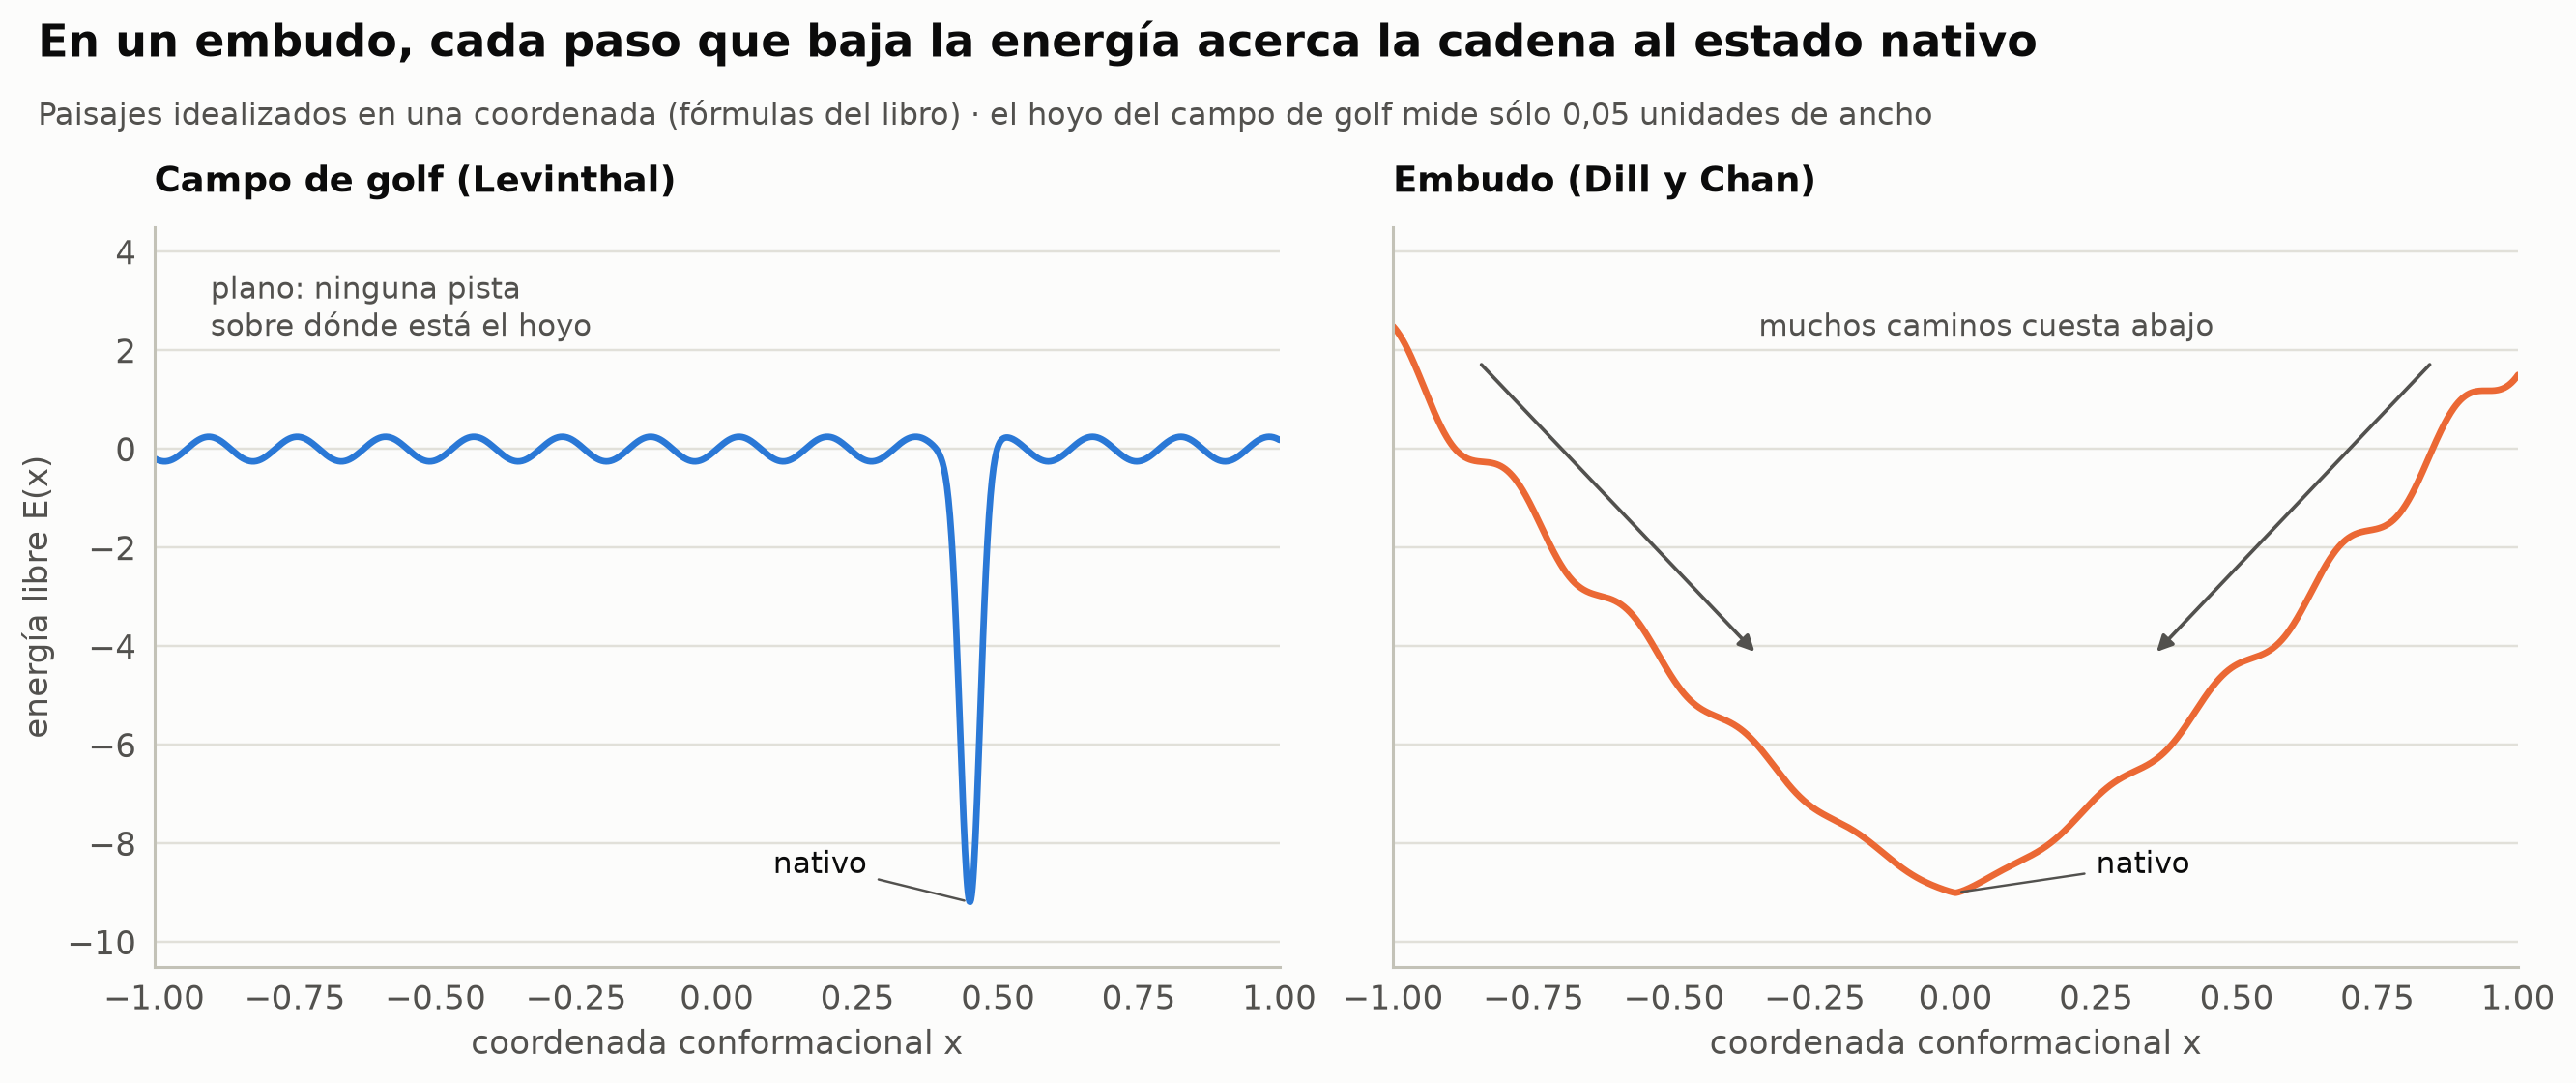

In [3]:
# Los dos paisajes de energía del libro (figura «Paisajes de energía del plegamiento»)
def E_golf(x):
    return 0.25 * np.sin(40 * x) - 9 * np.exp(-((x - 0.45) / 0.025) ** 2)

def E_funnel(x):
    return -9 + 11 * np.abs(x) ** 1.3 + 0.5 * np.sin(30 * x) * np.abs(x)

xg = np.linspace(-1, 1, 1500)
fig, axs = plt.subplots(1, 2, figsize=(12, 4.3), sharey=True)
for ax, E, col, name, native in [(axs[0], E_golf, ec.BLUE, "Campo de golf (Levinthal)", 0.45),
                                 (axs[1], E_funnel, ec.ORANGE, "Embudo (Dill y Chan)", 0.0)]:
    ax.plot(xg, E(xg), color=col, lw=2.2)
    ax.set_ylim(-10.5, 4.5); ax.set_xlim(-1, 1)
    ax.set_xlabel("coordenada conformacional x"); ax.set_title(name, fontsize=12, loc="left")
    ax.annotate("nativo", (native, E(native)), xytext=(native + (0.25 if native < 0.4 else -0.35), -8.6),
                fontsize=10, color=ec.INK, arrowprops=dict(arrowstyle="-", color=ec.INK_2, lw=0.8))
axs[0].set_ylabel("energía libre E(x)")
axs[0].text(-0.9, 2.3, "plano: ninguna pista\nsobre dónde está el hoyo", fontsize=10, color=ec.INK_2)
axs[1].text(-0.35, 2.3, "muchos caminos cuesta abajo", fontsize=10, color=ec.INK_2)
for s in (-1, 1):
    axs[1].annotate("", xy=(0.35 * s, -4.2), xytext=(0.85 * s, 1.8),
                    arrowprops=dict(arrowstyle="-|>", color=ec.INK_2, lw=1.2))
ec.fig_title(fig, "En un embudo, cada paso que baja la energía acerca la cadena al estado nativo",
             "Paisajes idealizados en una coordenada (fórmulas del libro) · el hoyo del campo de golf mide sólo 0,05 unidades de ancho")
plt.show()

> 🔎 **Qué observamos.** En el campo de golf, la pendiente es casi nula en todas partes: la posición de la cadena no le
> dice nada sobre dónde está el nativo. En el embudo, la pendiente apunta siempre hacia el centro; las pequeñas
> ondulaciones (rugosidad) crean mínimos locales transitorios, pero no impiden llegar al fondo.

Para verlo en movimiento, soltamos 40 «proteínas» en posiciones al azar de cada paisaje y dejamos que se muevan con el
**algoritmo de Metropolis**: en cada paso proponen un pequeño desplazamiento $\Delta x$; si baja la energía lo aceptan, y si
la sube lo aceptan con probabilidad $e^{-\Delta E/k_BT}$ (la agitación térmica permite saltar pequeñas barreras).

| Símbolo | Significado |
|---|---|
| $\Delta x$ | Desplazamiento propuesto (normal, desviación 0,02) |
| $\Delta E$ | Cambio de energía que produciría el movimiento |
| $k_BT$ | Energía térmica (aquí 0,4 unidades) |

🤔 **Antes de ejecutar, prediga:** tras 1200 pasos, ¿qué fracción de las 40 cadenas habrá llegado al nativo en cada
paisaje?

![40 cadenas se mueven por Metropolis en cada paisaje: en el embudo casi todas llegan al nativo en pocos cientos de pasos; en el campo de golf sólo lo encuentran las que tropiezan con el hoyo por azar](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-15-estructural/15.2_embudo.gif)

*40 cadenas se mueven por Metropolis en cada paisaje: en el embudo casi todas llegan al nativo en pocos cientos de pasos; en el campo de golf sólo lo encuentran las que tropiezan con el hoyo por azar*

In [4]:
# Animación: caminantes de Metropolis sobre los dos paisajes
rng_mc = np.random.default_rng(152)
N_WALK, STEPS_PER_FRAME, N_FRAMES, KT, SIGMA = 40, 30, 40, 0.4, 0.02
start = rng_mc.uniform(-1, 1, N_WALK)
walkers = {"golf": start.copy(), "funnel": start.copy()}
E_of = {"golf": E_golf, "funnel": E_funnel}
is_native = {"golf": lambda x: np.abs(x - 0.45) < 0.05, "funnel": lambda x: np.abs(x) < 0.1}
history = {"golf": [], "funnel": []}
frames_x = []
for f in range(N_FRAMES):
    for key in walkers:
        x = walkers[key]
        for _ in range(STEPS_PER_FRAME):
            prop = np.clip(x + rng_mc.normal(0, SIGMA, N_WALK), -1, 1)
            dE = E_of[key](prop) - E_of[key](x)
            accept = (dE < 0) | (rng_mc.random(N_WALK) < np.exp(-np.clip(dE, 0, 50) / KT))
            x = np.where(accept, prop, x)
        walkers[key] = x
        history[key].append(is_native[key](x).mean())
    frames_x.append({k: v.copy() for k, v in walkers.items()})
print(f"Tras {N_FRAMES * STEPS_PER_FRAME} pasos: en el nativo {history['golf'][-1]:.0%} (golf) "
      f"frente a {history['funnel'][-1]:.0%} (embudo)")

fig = plt.figure(figsize=(12, 5.2))
axG = fig.add_axes([0.06, 0.40, 0.42, 0.42]); axF = fig.add_axes([0.55, 0.40, 0.42, 0.42])
axH = fig.add_axes([0.06, 0.08, 0.85, 0.20])
def update(f):
    for ax in (axG, axF, axH):
        ax.clear()
    for ax, key, col, name in [(axG, "golf", ec.BLUE, "campo de golf"), (axF, "funnel", ec.ORANGE, "embudo")]:
        ax.plot(xg, E_of[key](xg), color=col, lw=2)
        xs = frames_x[f][key]
        ok = is_native[key](xs)
        ax.scatter(xs[~ok], E_of[key](xs[~ok]) + 0.6, s=28, color=ec.MUTED, zorder=3)
        ax.scatter(xs[ok], E_of[key](xs[ok]) + 0.6, s=34, color=ec.GREEN, zorder=4)
        ax.set_xlim(-1, 1); ax.set_ylim(-10.5, 4.5); ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f"{name}: {ok.sum()} de {N_WALK} en el nativo", fontsize=12, loc="left")
    steps = np.arange(1, f + 2) * STEPS_PER_FRAME
    axH.plot(steps, np.array(history["golf"][:f + 1]) * 100, color=ec.BLUE, lw=2)
    axH.plot(steps, np.array(history["funnel"][:f + 1]) * 100, color=ec.ORANGE, lw=2)
    axH.set_xlim(0, N_FRAMES * STEPS_PER_FRAME); axH.set_ylim(0, 105)
    axH.set_xlabel("pasos de Metropolis"); axH.set_ylabel("% en el nativo")
    axH.text(steps[-1] + 10, history["funnel"][f] * 100, "embudo", color=ec.INK_2, va="center", fontsize=10)
    axH.text(steps[-1] + 10, history["golf"][f] * 100, "golf", color=ec.INK_2, va="center", fontsize=10)
    fig.suptitle(f"Paso {(f + 1) * STEPS_PER_FRAME}: la pendiente del embudo guía a las cadenas; el golf sólo ofrece azar",
                 x=0.06, ha="left", fontsize=13, fontweight="bold")
    return []
ec.animate(fig, update, frames=N_FRAMES, interval=200, name="15.2_embudo")

Tras 1200 pasos: en el nativo 35% (golf) frente a 82% (embudo)


▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** En el embudo, las cadenas convergen al nativo en unos pocos cientos de pasos, cualquiera que sea
> su punto de partida. En el campo de golf, sólo lo encuentran las que empezaron cerca o tropezaron con él por azar.
> Y este modelo tiene **una** dimensión: en las cientos de dimensiones de una proteína real, la búsqueda al azar es
> astronómicamente peor, mientras que la pendiente del embudo sigue funcionando.

> ✅ **Compruebe su comprensión.** Resolver la paradoja de Levinthal, ¿resolvió el problema de *predecir* la estructura?
> *No: explica por qué la proteína se pliega rápido, pero simular físicamente ese plegamiento exige campos de fuerza
> exactos y tiempos de cómputo inalcanzables para casi todas las proteínas. Durante cinco décadas la predicción avanzó
> por otro camino: aprovechar la información evolutiva.*

---

## 3. 🧪 Los datos de la clase: p53 humana, sus estructuras y su familia

Trabajaremos con datos **reales** de cinco servicios públicos. Todos tienen una copia en el repositorio del curso
(carpeta `data/`), de modo que la clase funciona aunque un servidor no responda:

| Archivo | Qué es | Fuente |
|---|---|---|
| `AF-P04637-F1-model_v6.pdb` | Modelo de AlphaFold de p53 humana (393 residuos); la columna del factor $B$ guarda el pLDDT | AlphaFold DB |
| `AF-P04637-F1-predicted_aligned_error_v6.json` | Matriz PAE $393\times393$ del mismo modelo | AlphaFold DB |
| `AF-P04637-F1-aa-substitutions.csv` | Puntuación AlphaMissense de las 7467 sustituciones posibles de p53 | AlphaFold DB |
| `2OCJ` | Cristal del dominio de unión a ADN de p53 (sin ADN), 2007 | RCSB PDB |
| `1TSR` | Cristal del dominio de unión a ADN **unido a ADN** (Cho et al., 1994) | RCSB PDB |
| `1C26` | Cristal del dominio de tetramerización (Jeffrey et al., 1995) | RCSB PDB |
| `PF00870` | Alineamiento completo de la familia «P53 DNA-binding domain» (4272 secuencias) | Pfam / InterPro |
| ESMFold de p53 | Predicción de ESMFold para la secuencia completa (cacheada; más adelante llamamos a la API en vivo) | ESM Atlas |
| Calmodulina (`AF-P0DP23`, `1CLL`, `1CFD`) | Modelo de AlphaFold y dos cristales/RMN en estados distintos | AlphaFold DB, RCSB |

Una nota sobre el formato: AlphaFold DB publica cada modelo en PDB y en **mmCIF** (el formato moderno que vimos en la
15.1); usamos la versión PDB porque sus columnas fijas se leen con tres líneas de Python. La **versión 6** de los modelos
es la que usa el libro; fijamos las URL a esa versión para que las cifras no cambien si la base de datos se actualiza.

In [5]:
# 1) Metadatos del modelo en la API de AlphaFold DB (JSON)
meta = json.loads(course_text("api_cache/alphafold_prediction_P04637.json",
                              "https://alphafold.ebi.ac.uk/api/prediction/P04637"))[0]
for k in ["entryId", "uniprotDescription", "organismScientificName", "latestVersion", "globalMetricValue",
          "fractionPlddtVeryHigh", "fractionPlddtConfident", "fractionPlddtLow", "fractionPlddtVeryLow"]:
    print(f"{k:24s} {meta[k]}")
P53_SEQ = meta["uniprotSequence"]
print("longitud:", len(P53_SEQ), "·", P53_SEQ[:60], "…")
print("otros archivos:", meta["cifUrl"].split("/")[-1], "·", meta["paeDocUrl"].split("/")[-1])

entryId                  AF-P04637-F1
uniprotDescription       Cellular tumor antigen p53
organismScientificName   Homo sapiens
latestVersion            6
globalMetricValue        75.06
fractionPlddtVeryHigh    0.527
fractionPlddtConfident   0.071
fractionPlddtLow         0.104
fractionPlddtVeryLow     0.298
longitud: 393 · MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLSPDDIEQWFTEDPGP …
otros archivos: AF-P04637-F1-model_v6.cif · AF-P04637-F1-predicted_aligned_error_v6.json


In [6]:
# 2) Modelo de AlphaFold (v6 fijada), PAE, estructuras experimentales y predicción de ESMFold
af_df = read_pdb(course_text("152_AF-P04637-F1-model_v6.pdb.gz", f"{AFDB}/AF-P04637-F1-model_v6.pdb"))
pae_json = json.loads(course_text("152_AF-P04637-F1-predicted_aligned_error_v6.json.gz",
                                  f"{AFDB}/AF-P04637-F1-predicted_aligned_error_v6.json"))
pae_json = pae_json[0] if isinstance(pae_json, list) else pae_json
PAE = np.array(pae_json["predicted_aligned_error"], dtype=int)     # enteros en Å: más liviano
x2ocj_df = read_pdb(course_text("152_2OCJ.pdb.gz", f"{RCSB}/2OCJ.pdb"))
x1tsr_df = read_pdb(course_text("152_1TSR.pdb.gz", f"{RCSB}/1TSR.pdb"))
x1c26_txt = course_text("152_1C26.pdb.gz", f"{RCSB}/1C26.pdb")
x1c26_df = read_pdb(x1c26_txt)
esm_df = read_pdb(course_text("152_esmfold_P04637.pdb.gz"))          # predicción de ESMFold cacheada (ver sección 12)
am = pd.read_csv(io.BytesIO(course_bytes("152_AF-P04637-F1-aa-substitutions.csv.gz",
                                         f"{AFDB}/AF-P04637-F1-aa-substitutions.csv")))

af = residues(af_df)                      # resnum -> (CA, pLDDT, aa)
res = np.array(sorted(af))
plddt = np.array([af[r][1] for r in res])
esm = residues(esm_df)
plddt_esm = np.array([esm[r][1] * 100 for r in res])   # ESMFold guarda el pLDDT en escala 0-1
xtal = residues(x2ocj_df, chain="A")      # 2OCJ cadena A: residuos 96-289 resueltos
print(f"AlphaFold: {len(res)} residuos · pLDDT medio {plddt.mean():.2f} (API: {meta['globalMetricValue']})")
print(f"PAE: {PAE.shape}, máximo {PAE.max()} Å · ESMFold: {len(esm)} residuos")
print(f"2OCJ cadena A: residuos {min(xtal)}-{max(xtal)} ({len(xtal)} C-alfa)")
print(f"AlphaMissense: {len(am)} sustituciones ({len(am) // 19} posiciones × 19)")

AlphaFold: 393 residuos · pLDDT medio 75.05 (API: 75.06)


PAE: (393, 393), máximo 32 Å · ESMFold: 393 residuos
2OCJ cadena A: residuos 96-289 (194 C-alfa)
AlphaMissense: 7467 sustituciones (393 posiciones × 19)


Antes de seguir, comprobamos que los datos cargados reproducen exactamente las cifras del libro. Si AlphaFold DB
publicara algún día una versión nueva y usted la descargara, esta celda se lo advertiría.

In [7]:
# Control de calidad: las cifras del ejemplo «Leer un modelo de AlphaFold DB: p53» del libro
frac = {name: np.mean((plddt >= lo) & (plddt < hi)) * 100 for lo, hi, name in BANDS}
print("fracción por banda:", {k: round(v, 1) for k, v in frac.items()})
dbd, tet = slice(93, 292), slice(324, 356)          # índices 0-based de 94-292 y 325-356
checks = {"muy alta 52,7 %": round(frac["muy alta"], 1) == 52.7, "segura 7,1 %": round(frac["segura"], 1) == 7.1,
          "baja 10,4 %": round(frac["baja"], 1) == 10.4, "muy baja 29,8 %": round(frac["muy baja"], 1) == 29.8,
          "PAE DBD 3,6 Å": round(PAE[dbd, dbd].mean(), 1) == 3.6, "PAE TET 2,9 Å": round(PAE[tet, tet].mean(), 1) == 2.9,
          "PAE DBD→TET 20,1 Å": round(PAE[dbd, tet].mean(), 1) == 20.1}
for k, v in checks.items():
    print(("✔" if v else "✘"), k)
assert all(checks.values()), "Los datos no coinciden con los del libro (¿otra versión del modelo?)"

fracción por banda: {'muy alta': np.float64(52.7), 'segura': np.float64(7.1), 'baja': np.float64(10.4), 'muy baja': np.float64(29.8)}
✔ muy alta 52,7 %
✔ segura 7,1 %
✔ baja 10,4 %
✔ muy baja 29,8 %
✔ PAE DBD 3,6 Å
✔ PAE TET 2,9 Å
✔ PAE DBD→TET 20,1 Å


---

## 4. Modelado por homología y *threading*

### 4.1 Copiar el esqueleto de un pariente

En la lección 15.1 vimos que proteínas con apenas un 28 % de identidad, como la mioglobina y la hemoglobina, comparten el
mismo plegamiento: **la estructura se conserva mucho más que la secuencia**. Si nuestra proteína tiene un homólogo de
estructura conocida (una **plantilla**), podemos construir un modelo copiando su esqueleto. Es el **modelado comparativo**
o **por homología**, cuyo representante más influyente es MODELLER (Šali y Blundell, 1993).

La idea de MODELLER no es copiar coordenadas, sino **satisfacer restricciones espaciales**:

1. Se alinea la secuencia problema con una o varias plantillas.
2. Del alineamiento se derivan densidades de probabilidad para distancias y ángulos diedros del modelo («si en la
   plantilla estos dos C$_\alpha$ están a 6 Å, en el modelo probablemente también»).
3. Se combinan con términos estereoquímicos (longitudes y ángulos de enlace, choques prohibidos) en una función objetivo.
4. Se optimiza con gradientes conjugados y dinámica molecular con recocido simulado.

La calidad del modelo depende casi por completo del **alineamiento** y de la **identidad con la plantilla**:

| Identidad con la plantilla | Calidad típica del modelo |
|---|---|
| > 50 % | Muy buena, cercana a una estructura experimental de resolución media |
| 30–50 % | Núcleo fiable; lazos e inserciones no |
| < 30 % | Los errores de alineamiento se vuelven la principal fuente de error |
| sin plantilla | El método no puede empezar |

Veamos qué significa esto con datos reales. Supongamos que la única plantilla disponible fuera el cristal de la p53
humana. ¿Para cuántos miembros de la familia de p53 (Pfam PF00870) serviría bien? Primero leemos el alineamiento de la
familia; nos quedamos con las columnas del modelo oculto de Markov de Pfam (letras mayúsculas y guiones), descartando las
inserciones (minúsculas y puntos), como en la lección 4.3.

In [8]:
# Alineamiento completo de la familia PF00870 (formato Stockholm, descargado de InterPro)
sto = course_text("152_PF00870_full.sto.gz",
                  "https://www.ebi.ac.uk/interpro/api/entry/pfam/PF00870/?annotation=alignment:full")
aln = {}
for line in sto.splitlines():
    if line.startswith("#") or line.startswith("//") or not line.strip():
        continue
    name, s = line.split()
    aln[name] = aln.get(name, "") + s
names = list(aln)
match = {n: "".join(c for c in s if c.isupper() or c == "-") for n, s in aln.items()}   # sólo columnas del modelo
L_msa = len(match[names[0]])
human = next(n for n in names if n.startswith("P53_HUMAN"))

# Numeración: qué residuo de p53 humana ocupa cada columna del modelo (None si la humana tiene un hueco)
r = int(human.split("/")[1].split("-")[0])
col_res = []
for c in aln[human]:
    if c.isupper():
        col_res.append(r); r += 1
    elif c == "-":
        col_res.append(None)
    elif c.islower():
        r += 1                                   # inserción: consume residuo pero no crea columna
col_res = np.array(col_res, dtype=object)
print(f"{len(names)} secuencias · {L_msa} columnas del modelo · fila humana: {human}")
print("columnas 1-5 ↔ residuos humanos:", list(col_res[:5]), "… últimas:", list(col_res[-4:]))
print(match[human][:60], "…")

4272 secuencias · 193 columnas del modelo · fila humana: P53_HUMAN/99-289
columnas 1-5 ↔ residuos humanos: [None, 100, 101, 102, 103] … últimas: [286, 287, 288, None]
-QKTYQGSYGFRLGFLHSGTAKSVTCTYSPALNKMFCQLAKTCPVQLWVDSTPPPGTRVR …


secuencias con ≥50 % del dominio alineado: 4116 de 4272
  identidad > 50 %  :  84.3%
  identidad 30–50 % :   8.9%
  identidad < 30 %  :   6.8%


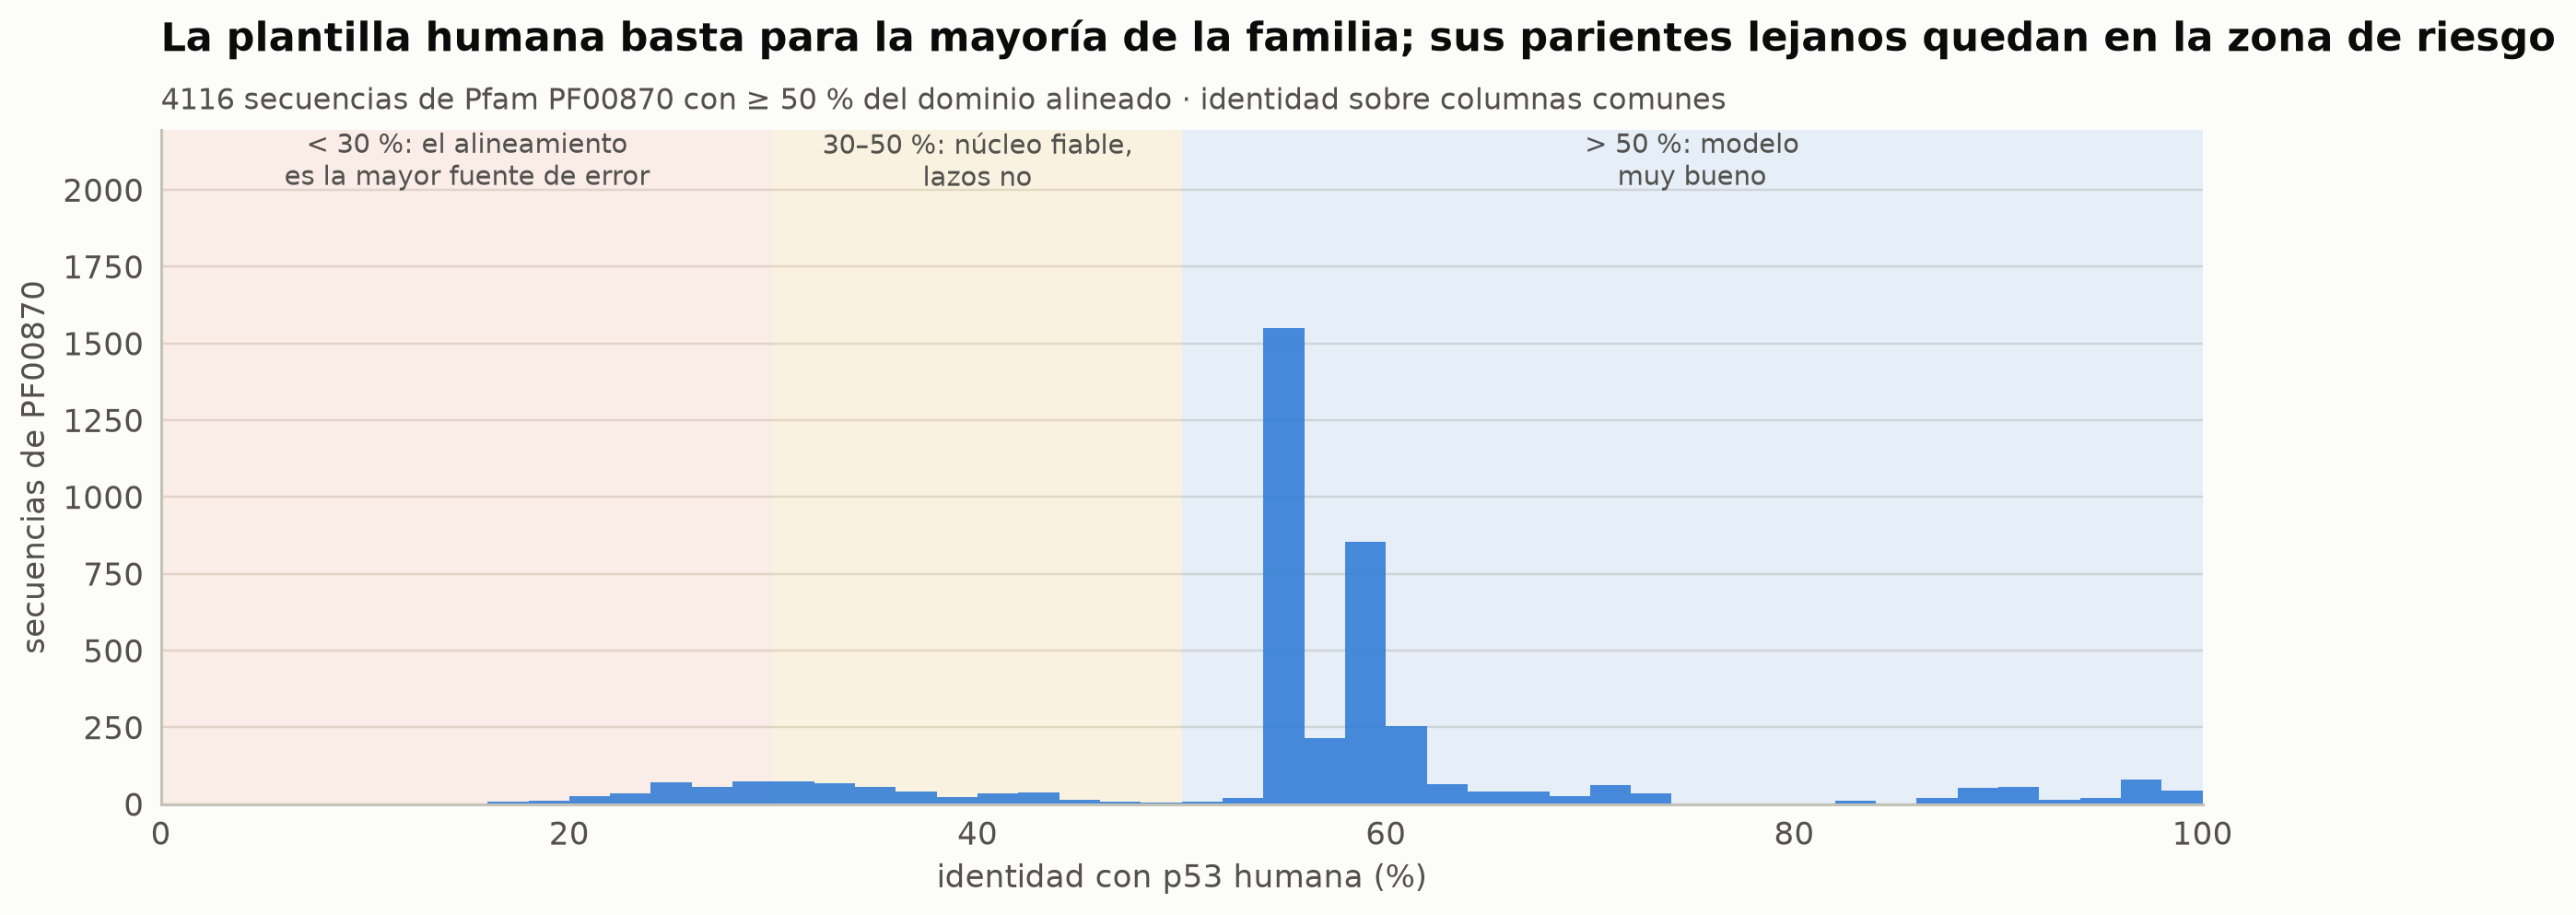

In [9]:
# Identidad de cada miembro de la familia con p53 humana (sobre columnas donde ambos tienen residuo)
AA = "-ACDEFGHIKLMNPQRSTVWY"
aidx = {a: i for i, a in enumerate(AA)}
X_all = np.array([[aidx.get(c, 0) for c in match[n]] for n in names], dtype=np.int8)
h = X_all[names.index(human)]
both = (X_all > 0) & (h > 0)
ident = ((X_all == h) & both).sum(1) / np.maximum(both.sum(1), 1) * 100
cover = both.sum(1) / (h > 0).sum() * 100
ok_cov = cover >= 50                                   # al menos la mitad del dominio alineado
id_ok = ident[ok_cov]
bins = {"> 50 %": (id_ok > 50).mean(), "30–50 %": ((id_ok >= 30) & (id_ok <= 50)).mean(), "< 30 %": (id_ok < 30).mean()}
print(f"secuencias con ≥50 % del dominio alineado: {ok_cov.sum()} de {len(names)}")
for k, v in bins.items():
    print(f"  identidad {k:8s}: {v:6.1%}")

fig, ax = plt.subplots(figsize=(11, 4.4))
for lo, hi, col, lab in [(0, 30, ec.ORANGE, "< 30 %: el alineamiento\nes la mayor fuente de error"),
                         (30, 50, ec.YELLOW, "30–50 %: núcleo fiable,\nlazos no"),
                         (50, 100, ec.BLUE, "> 50 %: modelo\nmuy bueno")]:
    ax.axvspan(lo, hi, color=col, alpha=0.10, lw=0)
    ax.text((lo + hi) / 2, 1.0, lab, transform=ax.get_xaxis_transform(), ha="center", va="top", fontsize=9.5, color=ec.INK_2)
ax.hist(id_ok, bins=np.arange(0, 101, 2), color=ec.BLUE, alpha=0.85)
ax.set_xlim(0, 100); ax.set_xlabel("identidad con p53 humana (%)"); ax.set_ylabel("secuencias de PF00870")
ax.set_ylim(0, ax.get_ylim()[1] * 1.35)
ec.title(ax, "La plantilla humana basta para la mayoría de la familia; sus parientes lejanos quedan en la zona de riesgo",
         f"{ok_cov.sum()} secuencias de Pfam PF00870 con ≥ 50 % del dominio alineado · identidad sobre columnas comunes")
plt.show()

> 🔎 **Qué observamos.** La familia de Pfam está dominada por vertebrados: un pequeño grupo cerca del 100 % (las p53
> de mamíferos) y un gran pico entre el 54 y el 62 % (p53 de otros vertebrados y sus parálogas p63 y p73). Para ese
> 84 % de la familia, un modelo por homología a partir del cristal humano sería muy bueno. Pero un 7 % (sobre todo
> invertebrados y organismos unicelulares) queda por debajo del 30 %: ahí el modelo sería frágil, no porque el
> plegamiento cambie, sino porque **alinear bien** secuencias tan divergentes es difícil.

### 4.2 *Threading*: ¿qué plegamiento conocido le sienta a mi secuencia?

Cuando la identidad es tan baja que ni siquiera se detecta la plantilla por secuencia, una idea de los años noventa
fue invertir la pregunta: en lugar de alinear secuencia contra secuencia, **enhebrar** (*to thread*) la secuencia sobre
cada plegamiento conocido y preguntar si «le sienta bien» (Jones, Taylor y Thornton, 1992). Cada posición de la
estructura tiene un **entorno** (enterrada o expuesta, en hélice o en lámina), y cada aminoácido tiene preferencias por
ciertos entornos: los hidrofóbicos prefieren el interior; los cargados, la superficie.

Construyamos una versión mínima con el cristal `2OCJ`. Para cada posición calculamos su **enterramiento** $n_k$ (número de
C$_\beta$ vecinos a menos de 10 Å) y, para una secuencia enhebrada, la **hidrofobicidad** $H_k$ de su residuo en esa
posición (escala de Kyte y Doolittle). Nuestra puntuación de ajuste es la correlación entre ambos perfiles, y la comparamos
con la que obtendríamos al barajar la misma secuencia:

$$
s=\operatorname{corr}(n_k,\,H_k),\qquad z=\frac{s-\bar s_{\text{barajada}}}{\operatorname{sd}(s_{\text{barajada}})} .
$$

| Símbolo | Significado (notación propia de esta clase; el libro no desarrolla el *threading*) |
|---|---|
| $n_k$ | Enterramiento de la posición $k$ de la plantilla: C$_\beta$ vecinos a < 10 Å |
| $H_k$ | Hidrofobicidad (Kyte–Doolittle) del residuo enhebrado en la posición $k$ |
| $s$ | Puntuación de ajuste secuencia–estructura |
| $z$ | Cuántas desviaciones estándar supera $s$ a la de secuencias barajadas (misma composición) |

Ejemplo pequeño: si en cinco posiciones el enterramiento es $(20, 5, 18, 4, 22)$ y enhebramos `L K V E I` (hidrofobicidades
$3{,}8,\,-3{,}9,\,4{,}2,\,-3{,}5,\,4{,}5$), los hidrofóbicos caen en las posiciones enterradas y la correlación es casi 1.
Si enhebramos `K L E V I`, la correlación se desploma.

🤔 **Antes de ejecutar, prediga:** para una secuencia de la familia con sólo un 20 % de identidad con la humana, ¿seguirá
siendo alta la puntuación $z$ de ajuste al plegamiento de p53?

In [10]:
KD = dict(A=1.8, R=-4.5, N=-3.5, D=-3.5, C=2.5, Q=-3.5, E=-3.5, G=-0.4, H=-3.2, I=4.5, L=3.8, K=-3.9, M=1.9,
          F=2.8, P=-1.6, S=-0.8, T=-0.7, W=-0.9, Y=-1.3, V=4.2)
# Ejemplo a mano
bur_toy = np.array([20, 5, 18, 4, 22])
for s in ("LKVEI", "KLEVI"):
    print(s, "→ s =", round(np.corrcoef(bur_toy, [KD[a] for a in s])[0, 1], 2))

# Enterramiento en el cristal 2OCJ (C-beta; C-alfa para glicina)
cb = residues(x2ocj_df, chain="A", atom="CB")
cb_res = np.array(sorted(cb)); CB = np.array([cb[r][0] for r in cb_res])
Dcb = np.linalg.norm(CB[:, None] - CB[None], axis=2)
burial = dict(zip(cb_res, (Dcb < 10).sum(1) - 1))

# Columnas del alineamiento que corresponden a un residuo resuelto en 2OCJ
cols_x = [c for c in range(L_msa) if col_res[c] is not None and col_res[c] in burial]
bur_cols = np.array([burial[col_res[c]] for c in cols_x], float)
KD_arr = np.array([0.0] + [KD[a] for a in AA[1:]])           # índice 0 = hueco

rng_th = np.random.default_rng(1522)
sub = np.where(ok_cov)[0]
sub = rng_th.choice(sub, size=min(1200, len(sub)), replace=False)
z_fit, s_fit = [], []
for n_i in sub:
    row = X_all[n_i, cols_x]
    keep = row > 0
    hk, bk = KD_arr[row[keep]], bur_cols[keep]
    s = np.corrcoef(bk, hk)[0, 1]
    shuf = np.array([np.corrcoef(bk, rng_th.permutation(hk))[0, 1] for _ in range(60)])
    s_fit.append(s); z_fit.append((s - shuf.mean()) / shuf.std())
z_fit, s_fit = np.array(z_fit), np.array(s_fit)

# Registro correcto frente a registros desplazados (secuencia humana)
hum_kd = np.array([KD[P53_SEQ[r - 1]] for r in cb_res])
shifts = np.arange(-40, 41)
reg = []
for sh in shifts:
    a, b = (slice(sh, None), slice(None, len(cb_res) - sh)) if sh >= 0 else (slice(None, sh), slice(-sh, None))
    reg.append(np.corrcoef(np.array([burial[r] for r in cb_res])[a], hum_kd[b])[0, 1])
reg = np.array(reg)
print(f"humana en su registro: s = {reg[shifts == 0][0]:.2f}; mejor desplazamiento: {shifts[reg.argmax()]}")
for lo, hi in [(0, 30), (30, 50), (50, 101)]:
    m = (ident[sub] >= lo) & (ident[sub] < hi)
    print(f"identidad {lo:>2}-{min(hi,100)} %: n={m.sum():4d}  z mediana = {np.median(z_fit[m]):.1f}  (z > 3: {np.mean(z_fit[m] > 3):.0%})")

LKVEI → s = 0.99
KLEVI → s = -0.51


humana en su registro: s = 0.28; mejor desplazamiento: 0
identidad  0-30 %: n=  85  z mediana = 5.0  (z > 3: 100%)
identidad 30-50 %: n= 100  z mediana = 4.5  (z > 3: 98%)
identidad 50-100 %: n=1015  z mediana = 4.0  (z > 3: 98%)


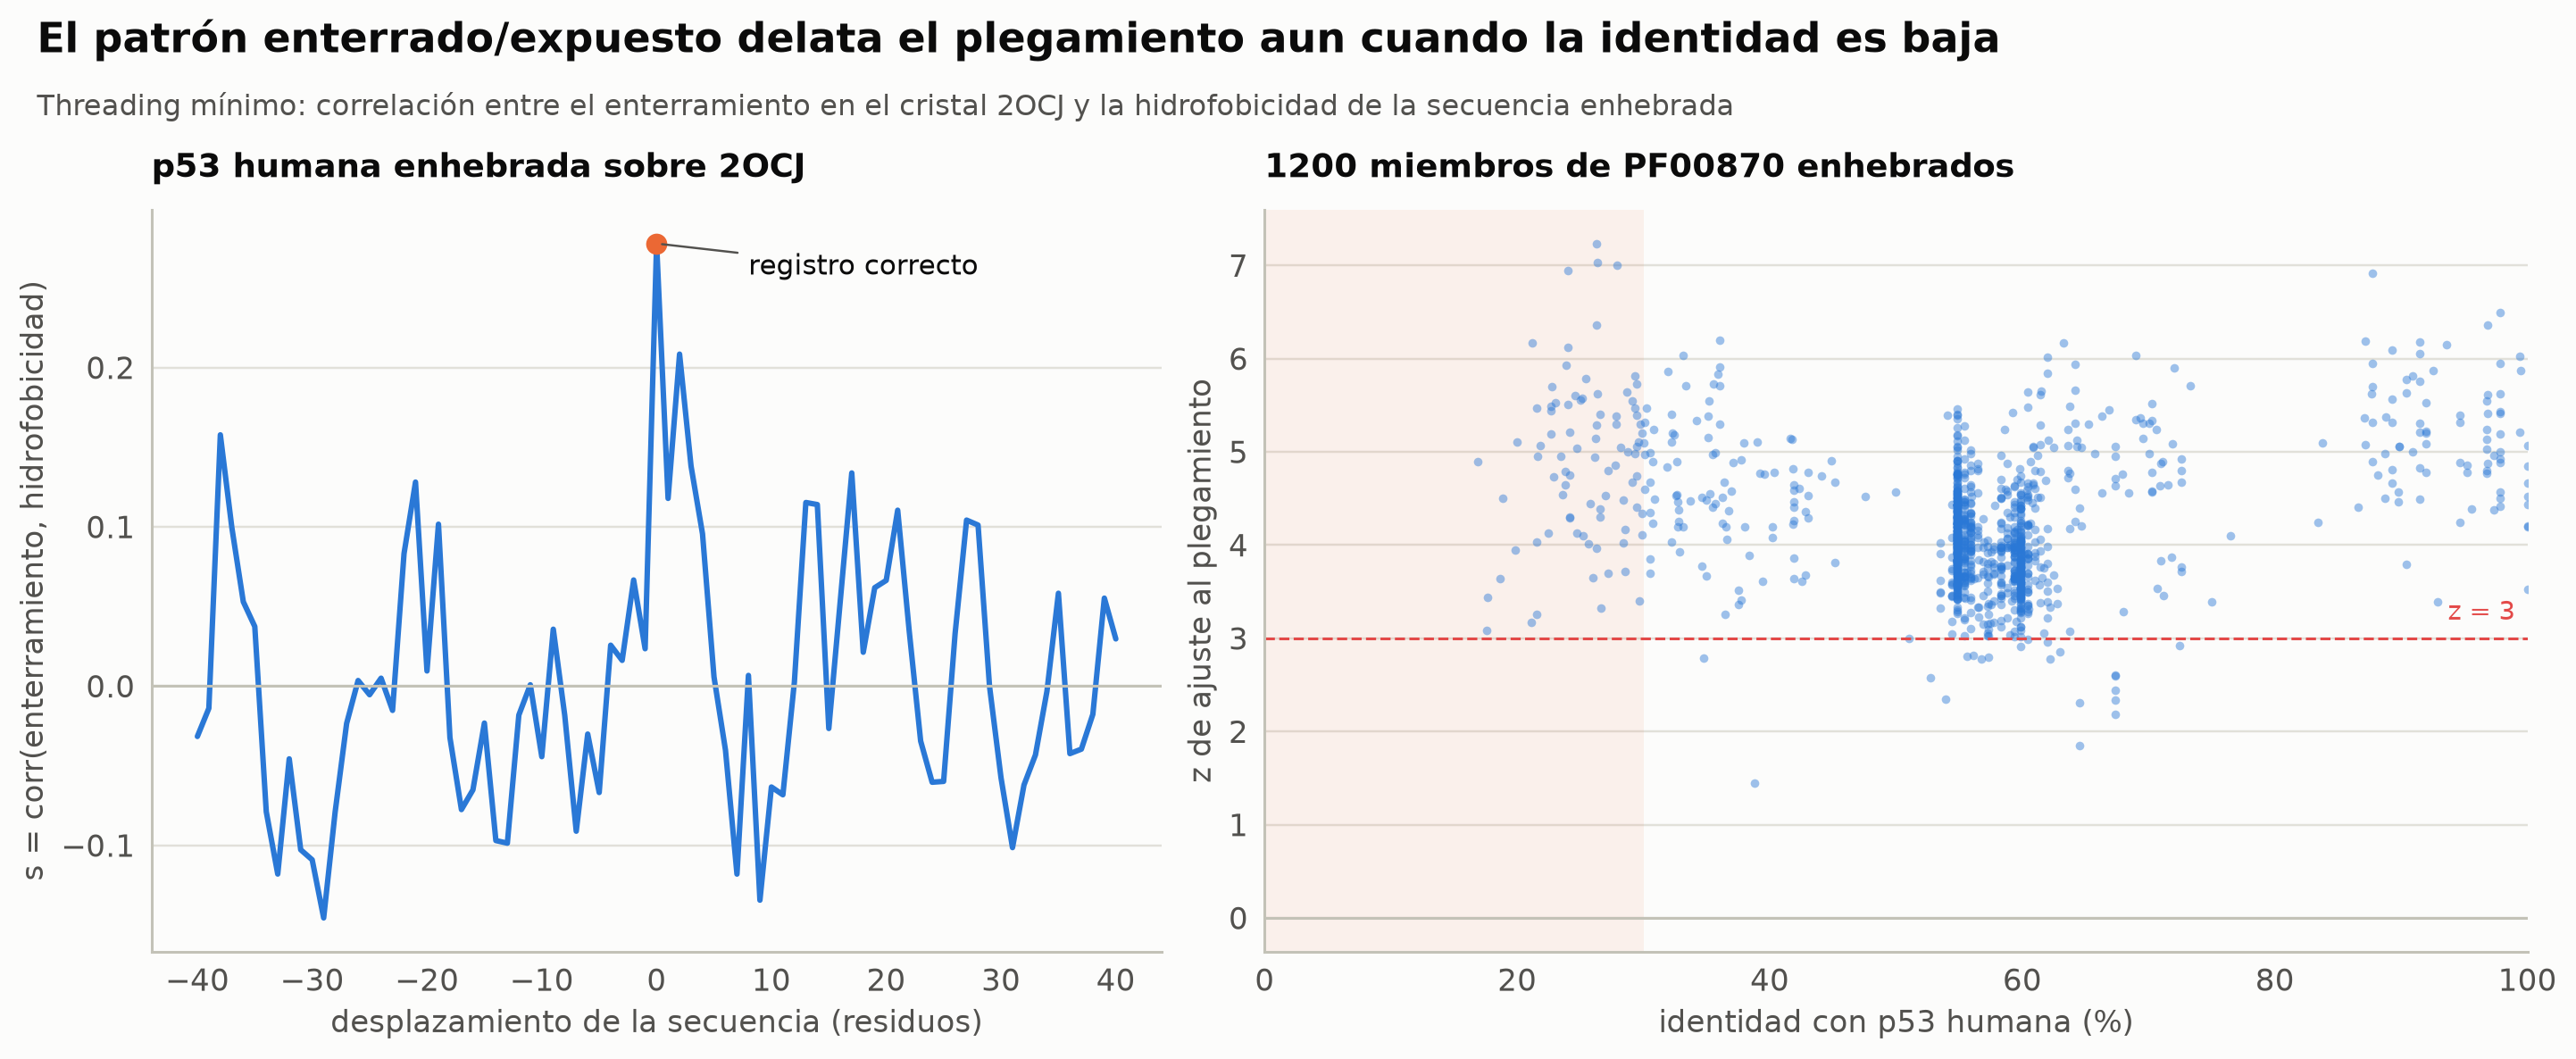

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw=dict(width_ratios=[1, 1.25]))
ax = axs[0]
ax.plot(shifts, reg, color=ec.BLUE, lw=2)
ax.scatter([0], [reg[shifts == 0][0]], color=ec.ORANGE, s=60, zorder=3)
ax.annotate("registro correcto", (0, reg[shifts == 0][0]), xytext=(8, reg.max() * 0.93), fontsize=10,
            arrowprops=dict(arrowstyle="-", color=ec.INK_2, lw=0.8))
ax.axhline(0, color=ec.BASELINE, lw=1)
ax.set_xlabel("desplazamiento de la secuencia (residuos)"); ax.set_ylabel("s = corr(enterramiento, hidrofobicidad)")
ax.set_title("p53 humana enhebrada sobre 2OCJ", loc="left", fontsize=12)
ax = axs[1]
ax.axvspan(0, 30, color=ec.ORANGE, alpha=0.08, lw=0)
ax.scatter(ident[sub], z_fit, s=10, color=ec.BLUE, alpha=0.45, lw=0)
ax.axhline(3, color=ec.RED, lw=1, ls="--"); ax.text(99, 3.2, "z = 3", ha="right", color=ec.RED, fontsize=9.5)
ax.axhline(0, color=ec.BASELINE, lw=1)
ax.set_xlim(0, 100); ax.set_xlabel("identidad con p53 humana (%)"); ax.set_ylabel("z de ajuste al plegamiento")
ax.set_title(f"{len(sub)} miembros de PF00870 enhebrados", loc="left", fontsize=12)
ec.fig_title(fig, "El patrón enterrado/expuesto delata el plegamiento aun cuando la identidad es baja",
             "Threading mínimo: correlación entre el enterramiento en el cristal 2OCJ y la hidrofobicidad de la secuencia enhebrada")
plt.show()

> 🔎 **Qué observamos.** A la izquierda, la secuencia humana «encaja» en su propio cristal sólo en el registro correcto;
> desplazarla unas pocas posiciones destruye el ajuste. A la derecha, incluso los miembros de la familia con menos del
> 30 % de identidad conservan un patrón de hidrofobicidad compatible con el plegamiento de p53 (casi todos con $z>3$).
> La **forma** se conserva más que la **secuencia**; el *threading* explota exactamente eso. Los métodos reales usan
> potenciales estadísticos por par de residuos y alineamiento por programación dinámica, pero la lógica es ésta.

> ✅ **Compruebe su comprensión.** ¿Por qué un modelo por homología con un 25 % de identidad puede tener el plegamiento
> correcto y, aun así, errores grandes? *Porque el plegamiento global se hereda, pero un alineamiento desplazado unos
> pocos residuos coloca cada cadena lateral en el entorno equivocado; los lazos e inserciones no tienen equivalente en la
> plantilla.*

---

## 5. CASP y el GDT_TS: medir el progreso a ciegas

Para saber qué métodos funcionan de verdad hay que evaluarlos **sin que los autores conozcan la respuesta**. Moult y
colaboradores organizaron en 1994 el primer **CASP** (*Critical Assessment of Structure Prediction*): los organizadores
recogen secuencias de proteínas cuya estructura está a punto de resolverse experimentalmente, los grupos envían sus
predicciones antes de que se publique, y evaluadores independientes las comparan con la estructura real. Se repite cada dos
años: es el equivalente estructural de un ensayo clínico doble ciego.

La medida principal de CASP es el **GDT_TS** (*Global Distance Test, total score*):

$$
\mathrm{GDT\_TS}=\frac{100}{4}\left(P_1+P_2+P_4+P_8\right),
$$

| Símbolo | Significado |
|---|---|
| $P_c$ | Fracción máxima de C$_\alpha$ a menos de $c$ Å de la referencia, optimizando la superposición para cada umbral |
| $c$ | Umbral de distancia: 1, 2, 4 y 8 Å |

Como el TM-score (lección 15.1), premia la fracción bien predicha e ignora los residuos muy desviados. Un GDT_TS por encima
de 90 se considera competitivo con una estructura experimental.

**Ejemplo a mano.** Un modelo de 10 residuos, ya superpuesto, tiene estas distancias a la referencia (Å):
$0{,}4;\ 0{,}8;\ 1{,}2;\ 1{,}5;\ 2{,}5;\ 3{,}1;\ 3{,}9;\ 5{,}0;\ 7{,}2;\ 12{,}0$. Contamos:
$P_1=2/10$, $P_2=4/10$, $P_4=7/10$, $P_8=9/10$, y
$\mathrm{GDT\_TS}=25\,(0{,}2+0{,}4+0{,}7+0{,}9)=55$. (El GDT real busca además, para cada umbral, la superposición que
maximiza $P_c$, así que el valor sólo puede subir.)

In [12]:
d_toy = np.array([0.4, 0.8, 1.2, 1.5, 2.5, 3.1, 3.9, 5.0, 7.2, 12.0])
Pc = {c: np.mean(d_toy < c) for c in (1, 2, 4, 8)}
print("P_c:", Pc, "→ GDT_TS =", 25 * sum(Pc.values()))

def gdt_ts(P, Q, cutoffs=(1, 2, 4, 8)):
    """GDT_TS con búsqueda de superposición por umbral (semillas de fragmentos + refinamiento iterativo)."""
    n = len(P)
    frac = {}
    for c in cutoffs:
        best = 0
        for w in (n, 20, 9):                                   # semillas: toda la cadena y fragmentos
            for s0 in range(0, n - min(w, n) + 1, max(1, min(w, n) // 2)):
                idx = np.arange(s0, s0 + min(w, n))
                for _ in range(10):
                    R, t = kabsch(P[idx], Q[idx])
                    d = np.sqrt(((P @ R.T + t - Q) ** 2).sum(1))
                    best = max(best, int((d < c).sum()))
                    new = np.where(d < c)[0]
                    if len(new) < 3 or np.array_equal(new, idx):
                        break
                    idx = new
        frac[c] = best / n
    return 25 * sum(frac.values()), frac
print("función gdt_ts lista (la aplicaremos al modelo de p53 en la sección 9)")

P_c: {1: np.float64(0.2), 2: np.float64(0.4), 4: np.float64(0.7), 8: np.float64(0.9)} → GDT_TS = 55.00000000000001
función gdt_ts lista (la aplicaremos al modelo de p53 en la sección 9)


---

## 6. La señal de la coevolución

### 6.1 La idea con seis secuencias

Volvamos a los edificios hermanos. En el alineamiento de la figura de coevolución del libro, seis homólogos cortos, dos
columnas cambian de forma coordinada: cuando la columna $i$ tiene glutamato (E), la $j$ tiene lisina (K), y viceversa.
El puente salino entre ambas cadenas laterales se conserva aunque los dos residuos cambien: **las cargas se
intercambiaron**. La explicación estructural más sencilla es que $i$ y $j$ **se tocan**.

La primera medida que viene a la mente es la **información mutua** entre columnas:

$$
\mathrm{MI}_{ij}=\sum_{a,b} f_{ij}(a,b)\,\log\frac{f_{ij}(a,b)}{f_i(a)\,f_j(b)} ,
$$

| Símbolo | Significado |
|---|---|
| $f_i(a)$ | Frecuencia (con pesos y pseudocuentas) del aminoácido $a$ en la columna $i$ del MSA |
| $f_{ij}(a,b)$ | Frecuencia conjunta del par $(a,b)$ en las columnas $(i,j)$ |
| $\mathrm{MI}_{ij}$ | Información mutua entre las columnas $i$ y $j$, en nats (logaritmo natural) |

**Cálculo a mano.** En la columna $i$: E aparece 3 veces de 6 y K 3 veces, así que $f_i(\mathrm E)=f_i(\mathrm K)=1/2$;
lo mismo en $j$. Los pares observados son sólo (E,K) y (K,E), cada uno con frecuencia $1/2$. Entonces
$\mathrm{MI}_{ij}=2\times\tfrac12\log\frac{1/2}{(1/2)(1/2)}=\log 2\approx0{,}693$ nats, el máximo posible para dos
columnas con dos letras cada una. Si las columnas fueran independientes, $f_{ij}(a,b)=f_i(a)f_j(b)$ y cada logaritmo
valdría 0.

columna i (5): EKEKEK  columna j (9): KEKEKE  → MI = 0.693 nats (log 2 = 0.693 )
columna 7     : RKRKRK  → MI(5,7) = 0.693  MI(7,9) = 0.693


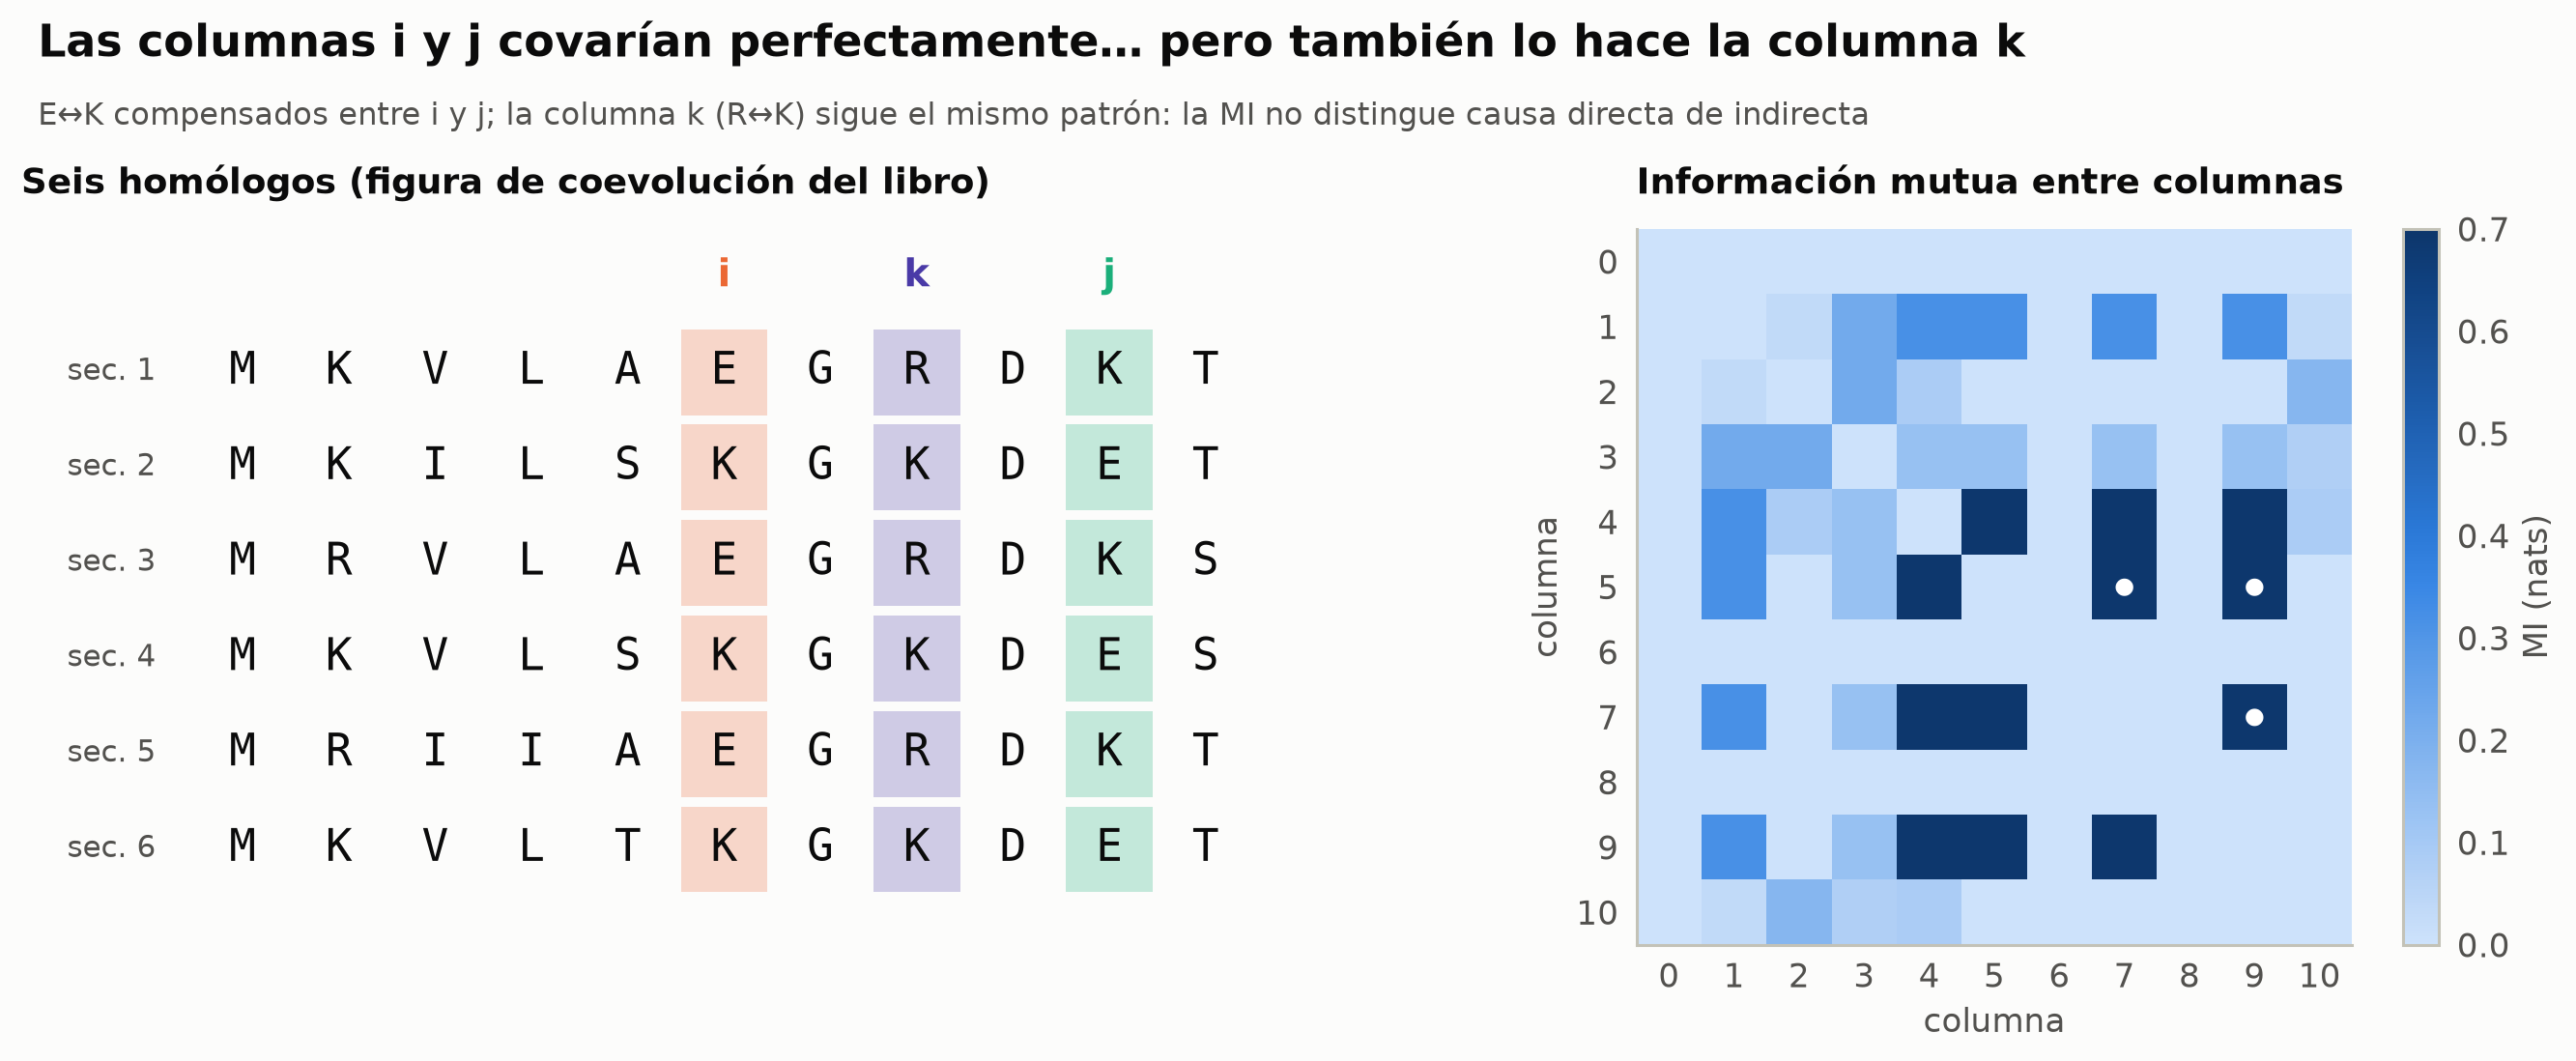

In [13]:
# El alineamiento de juguete de la figura de coevolución del libro
toy = ["MKVLAEGRDKT", "MKILSKGKDET", "MRVLAEGRDKS", "MKVLSKGKDES", "MRIIAEGRDKT", "MKVLTKGKDET"]

def mi_columns(c1, c2):
    """Información mutua (nats) entre dos columnas, sin pesos ni pseudocuentas."""
    n = len(c1)
    fi, fj, fij = Counter(c1), Counter(c2), Counter(zip(c1, c2))
    return sum((v / n) * math.log((v / n) / ((fi[a] / n) * (fj[b] / n))) for (a, b), v in fij.items())

cols = ["".join(s[k] for s in toy) for k in range(len(toy[0]))]
Mtoy = np.array([[mi_columns(cols[a], cols[b]) if a != b else 0 for b in range(11)] for a in range(11)])
print("columna i (5):", cols[5], " columna j (9):", cols[9], " → MI =", round(Mtoy[5, 9], 3), "nats (log 2 =", round(math.log(2), 3), ")")
print("columna 7     :", cols[7], " → MI(5,7) =", round(Mtoy[5, 7], 3), " MI(7,9) =", round(Mtoy[7, 9], 3))

fig, axs = plt.subplots(1, 2, figsize=(12, 4.2), gridspec_kw=dict(width_ratios=[1.25, 1]))
ax = axs[0]; ax.axis("off"); ax.grid(False)
for r_i, s in enumerate(toy):
    for c_i, ch in enumerate(s):
        fc = {5: ec.ORANGE, 9: ec.AQUA, 7: ec.VIOLET}.get(c_i)
        if fc:
            ax.add_patch(Rectangle((c_i - 0.45, -r_i - 0.45), 0.9, 0.9, color=fc, alpha=0.25, lw=0))
        ax.text(c_i, -r_i, ch, ha="center", va="center", family="monospace", fontsize=15, color=ec.INK)
    ax.text(-0.9, -r_i, f"sec. {r_i + 1}", ha="right", va="center", fontsize=10, color=ec.INK_2)
for c_i, lab, col in [(5, "i", ec.ORANGE), (9, "j", ec.AQUA), (7, "k", ec.VIOLET)]:
    ax.text(c_i, 0.9, lab, ha="center", fontsize=13, fontweight="bold", color=col)
ax.set_xlim(-2.3, 11); ax.set_ylim(-6, 1.5)
ax.set_title("Seis homólogos (figura de coevolución del libro)", loc="left", fontsize=12)
ax = axs[1]
im = ax.imshow(Mtoy, cmap=ec.CMAP_SEQ, vmin=0, vmax=0.7)
ax.set_xticks(range(11)); ax.set_yticks(range(11)); ax.grid(False)
ax.set_xlabel("columna"); ax.set_ylabel("columna")
for a, b in [(5, 9), (5, 7), (7, 9)]:
    ax.text(b, a, "●", ha="center", va="center", color="white", fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046, label="MI (nats)")
ax.set_title("Información mutua entre columnas", loc="left", fontsize=12)
ec.fig_title(fig, "Las columnas i y j covarían perfectamente… pero también lo hace la columna k",
             "E↔K compensados entre i y j; la columna k (R↔K) sigue el mismo patrón: la MI no distingue causa directa de indirecta")
plt.show()

> 🔎 **Qué observamos.** $\mathrm{MI}_{ij}=\log2$, como calculamos a mano. Pero la columna $k$ (R↔K) sigue exactamente el
> mismo patrón y tiene la misma información mutua con $i$ y con $j$. Con seis secuencias es imposible saber cuál de los
> tres pares se toca. La información mutua **confunde correlaciones directas e indirectas**: si $i$ toca a $k$ y $k$
> toca a $j$, las columnas $i$ y $j$ covarían aunque no se toquen. Además, la **filogenia** (secuencias emparentadas que
> comparten mutaciones por herencia, como las sec. 1, 3 y 5 aquí) añade correlaciones espurias.

### 6.2 El modelo de Potts y el acoplamiento directo (DCA)

Morcos y colaboradores (2011) resolvieron el problema con el **análisis de acoplamiento directo** (DCA). En lugar de medir
correlaciones par a par, ajustan a todo el MSA un modelo probabilístico global, un **modelo de Potts** de la física
estadística:

$$
P(a_1,\dots,a_L)=\frac1Z\exp\!\Big(\sum_{i<j}J_{ij}(a_i,a_j)+\sum_i h_i(a_i)\Big),
$$

| Símbolo | Significado |
|---|---|
| $P(a_1,\dots,a_L)$ | Probabilidad de una secuencia de longitud $L$ bajo el modelo de la familia |
| $h_i(a)$ | Campo local: preferencia de la columna $i$ por el aminoácido $a$ |
| $J_{ij}(a,b)$ | Acoplamiento directo entre el aminoácido $a$ en $i$ y el $b$ en $j$ |
| $Z$ | Constante de normalización (función de partición) |

Sus parámetros $J_{ij}$ capturan sólo las dependencias **directas**: las indirectas ya quedan explicadas por las cadenas
de acoplamientos intermedios ($i\to k\to j$). Con la **aproximación de campo medio**, los acoplamientos se obtienen
invirtiendo la matriz de covarianzas del alineamiento:

$$
C_{ij}(a,b)=f_{ij}(a,b)-f_i(a)\,f_j(b),\qquad J_{ij}(a,b)\approx-\big(C^{-1}\big)_{ij}(a,b).
$$

Para que el cálculo funcione con datos reales hacen falta tres ingredientes técnicos, que el libro menciona de pasada y
aquí hacemos explícitos (notación propia de esta clase):

| Símbolo | Significado |
|---|---|
| $w_s=1/\lvert\{s':\ \mathrm{id}(s,s')\ge0{,}8\}\rvert$ | Peso de la secuencia $s$: las casi idénticas se reparten un solo voto |
| $N_{\text{eff}}=\sum_s w_s$ | Número **efectivo** de secuencias |
| $\lambda$ | Peso de las pseudocuentas (0,5): mezcla las frecuencias con la uniforme para que $C$ sea invertible |
| $\mathrm{FN}_{ij}$ | Norma de Frobenius de la matriz $J_{ij}(a,b)$ (sin huecos, centrada): un número por par de columnas |
| $S^{\mathrm{APC}}_{ij}=S_{ij}-\dfrac{\bar S_{i\cdot}\,\bar S_{\cdot j}}{\bar S}$ | Corrección del producto medio (APC, Dunn et al., 2008): resta el ruido de fondo de cada columna |

El DCA original de Morcos resume cada par con la *información directa*; aquí usamos la norma de Frobenius con APC, una
variante posterior muy usada que es más simple de programar y da resultados parecidos. Las frecuencias con pseudocuentas
son $f_i(a)=(1-\lambda)\hat f_i(a)+\lambda/q$ y $f_{ij}(a,b)=(1-\lambda)\hat f_{ij}(a,b)+\lambda/q^2$, con $q=21$ (20
aminoácidos y el hueco).

Para evaluar las predicciones necesitamos una definición de **contacto**: dos residuos están en contacto si sus C$_\beta$
(C$_\alpha$ en glicina) están a **menos de 8 Å** en el cristal `2OCJ` y a **6 o más posiciones** de distancia en la
secuencia (los vecinos inmediatos siempre están cerca y no informan del plegamiento).

🤔 **Antes de ejecutar, prediga:** si eligiéramos pares de columnas al azar, ¿qué fracción serían contactos? ¿Y entre los
~37 pares con mayor puntuación DCA ($L/5$)?

In [14]:
# Codificación del MSA y pesos por redundancia
keep_seq = (X_all == 0).mean(1) < 0.5                      # descartamos fragmentos con > 50 % de huecos
X = X_all[keep_seq]
q = 21

def weights(X, theta=0.8):
    Xo = np.eye(q, dtype=np.float32)[X].reshape(len(X), -1)
    ident = (Xo @ Xo.T) / X.shape[1]                        # identidad (huecos incluidos) entre todas las parejas
    return 1.0 / (ident >= theta).sum(1)

def dca_scores(X, w, lam=0.5):
    """Información mutua y DCA de campo medio (norma de Frobenius), ambas con y sin APC."""
    n, L = X.shape
    Neff = w.sum()
    Xo = np.eye(q, dtype=np.float64)[X].reshape(n, -1)
    fi = (1 - lam) * (w @ Xo) / Neff + lam / q
    fij = (1 - lam) * ((Xo * w[:, None]).T @ Xo) / Neff + lam / q ** 2
    for i in range(L):                                      # bloques diagonales: frecuencias individuales
        fij[i * q:(i + 1) * q, i * q:(i + 1) * q] = np.diag(fi[i * q:(i + 1) * q])
    C = fij - np.outer(fi, fi)
    sel = np.array([i * q + a for i in range(L) for a in range(1, q)])   # quitamos el estado «hueco»
    J = -np.linalg.inv(C[np.ix_(sel, sel)]).reshape(L, q - 1, L, q - 1).transpose(0, 2, 1, 3)
    J = J - J.mean(2, keepdims=True) - J.mean(3, keepdims=True) + J.mean((2, 3), keepdims=True)
    FN = np.sqrt((J ** 2).sum((2, 3)))
    P2 = fij.reshape(L, q, L, q).transpose(0, 2, 1, 3)
    P1 = fi.reshape(L, q)
    with np.errstate(divide="ignore", invalid="ignore"):
        MI = np.nan_to_num(P2 * np.log(P2 / (P1[:, None, :, None] * P1[None, :, None, :]))).sum((2, 3))
    def apc(S):
        S = S.copy(); np.fill_diagonal(S, 0)
        m = S.sum(0) / (L - 1)
        return S - np.outer(m, m) / (S.sum() / (L * (L - 1)))
    np.fill_diagonal(MI, 0); np.fill_diagonal(FN, 0)
    return dict(MI=MI, MI_APC=apc(MI), DCA=FN, DCA_APC=apc(FN)), Neff

t0 = time.time()
w_seq = weights(X)
scores, Neff = dca_scores(X, w_seq)
print(f"MSA: {X.shape[0]} secuencias × {X.shape[1]} columnas · N_eff = {Neff:.0f} · {time.time() - t0:.1f} s")

MSA: 4099 secuencias × 193 columnas · N_eff = 345 · 1.4 s


In [15]:
# Contactos reales en el cristal 2OCJ (C-beta < 8 Å, separación ≥ 6)
cols_c = [c for c in range(L_msa) if col_res[c] is not None and col_res[c] in cb]
Lc = len(cols_c)
Dcol = np.full((L_msa, L_msa), np.nan)
for a in cols_c:
    for b in cols_c:
        Dcol[a, b] = np.linalg.norm(cb[col_res[a]][0] - cb[col_res[b]][0])
pairs = [(a, b) for ai, a in enumerate(cols_c) for b in cols_c[ai + 1:] if col_res[b] - col_res[a] >= 6]
is_contact = np.array([Dcol[a, b] < 8 for a, b in pairs])
print(f"{Lc} columnas con residuo en 2OCJ · {len(pairs)} pares con |i−j| ≥ 6 · contactos: {is_contact.sum()} "
      f"({is_contact.mean():.1%} = acierto de elegir al azar)")

def ranked(S):
    sc = np.array([S[a, b] for a, b in pairs])
    return np.argsort(-sc)

prec = {}
for name, S in scores.items():
    order = ranked(S)
    prec[name] = {k: is_contact[order[:k]].mean() for k in (Lc // 5, Lc // 2, Lc)}
prec_df = pd.DataFrame(prec).T
prec_df.columns = [f"top L/5 ({Lc // 5})", f"top L/2 ({Lc // 2})", f"top L ({Lc})"]
print((prec_df * 100).round(0).astype(int).astype(str) + " %")

187 columnas con residuo en 2OCJ · 16481 pares con |i−j| ≥ 6 · contactos: 462 (2.8% = acierto de elegir al azar)
        top L/5 (37) top L/2 (93) top L (187)
MI              14 %         13 %        12 %
MI_APC          19 %         15 %        12 %
DCA              3 %          4 %         7 %
DCA_APC         54 %         35 %        27 %


> 🔎 **Qué observamos.** Al azar, apenas un 3 % de los pares son contactos. La información mutua cruda sube eso a un
> 13–14 %; con APC, a un ~19 %. El DCA **sin** corrección APC no sirve (su señal queda enterrada bajo columnas muy
> variables que «acoplan con todo»), pero el DCA **con** APC acierta en más de la mitad de sus 37 mejores pares: unas 20
> veces más que el azar, usando sólo secuencias. La corrección APC no es un detalle: es lo que separa el ruido de la señal.

Veamos dónde caen esas predicciones sobre el mapa de contactos real. En el mapa interactivo, el triángulo superior muestra
los mejores pares del DCA+APC y el inferior los de la información mutua+APC; pase el cursor para ver cada par.

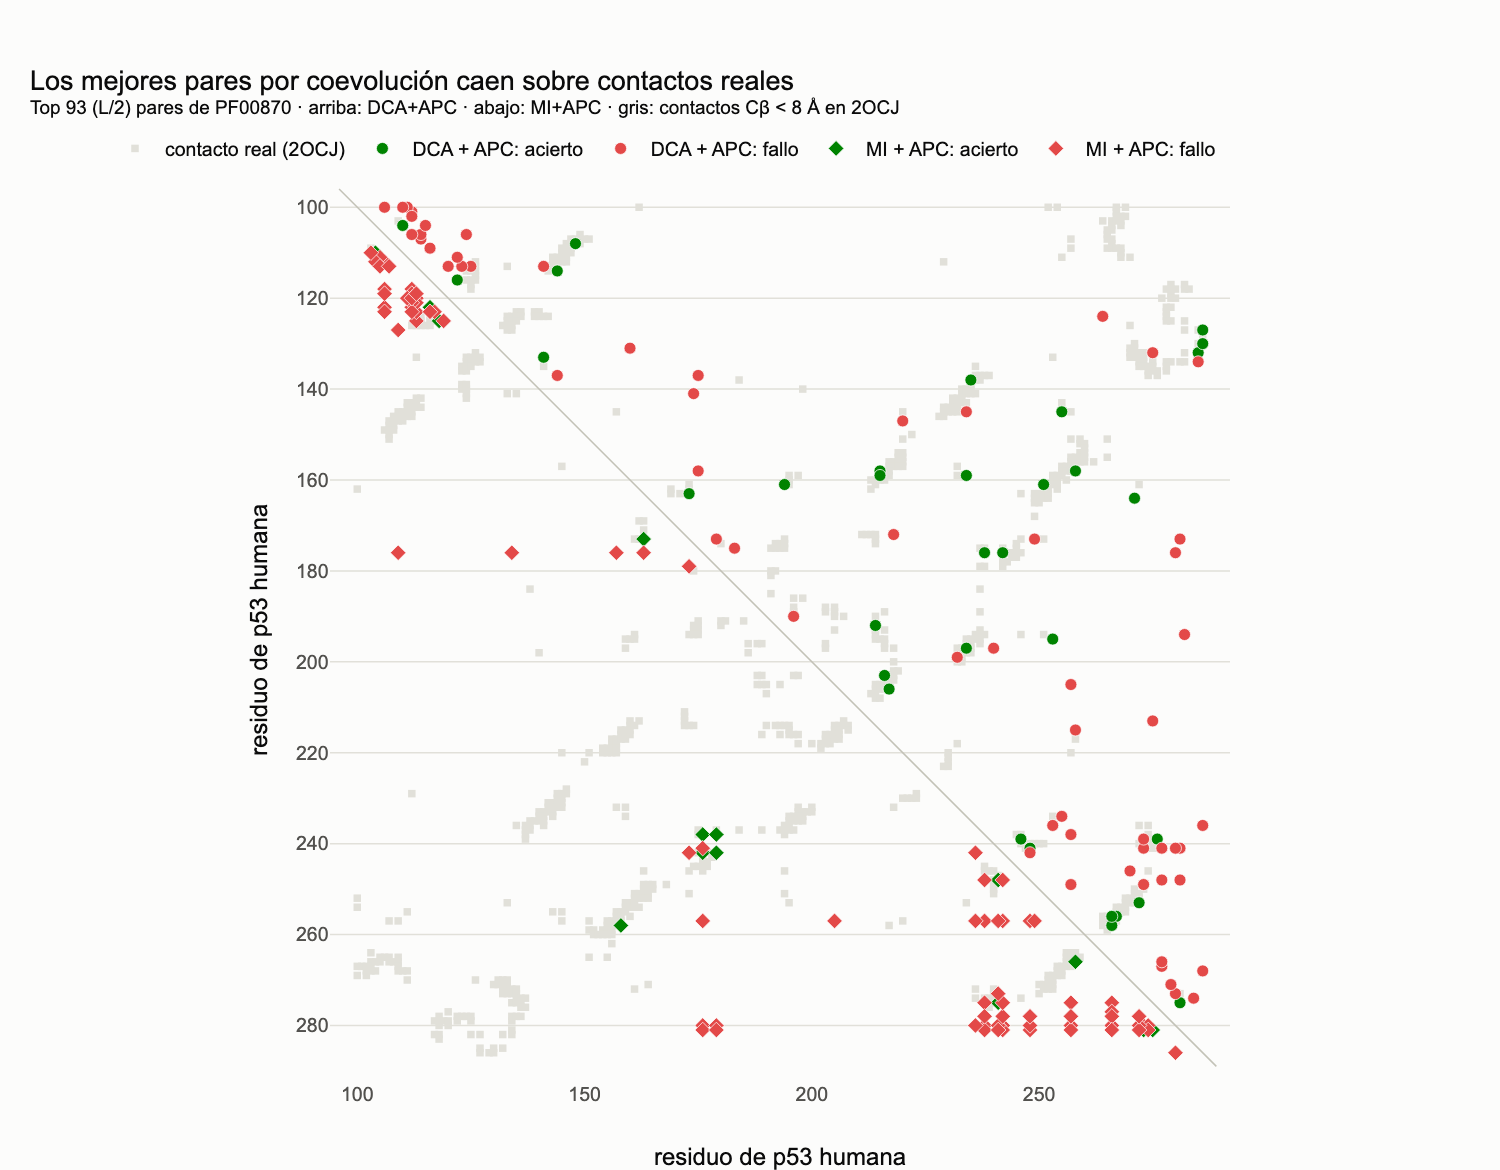

In [16]:
# 📊 Interactivo: mapa de contactos real frente a predicciones por coevolución
K_SHOW = Lc // 2
figp = go.Figure()
ci = np.array([col_res[a] for a, b in pairs]); cj = np.array([col_res[b] for a, b in pairs])
dd = np.array([Dcol[a, b] for a, b in pairs])
figp.add_trace(go.Scatter(x=np.r_[cj[is_contact], ci[is_contact]], y=np.r_[ci[is_contact], cj[is_contact]],
                          mode="markers", marker=dict(size=5, color=ec.GRID, symbol="square"),
                          name="contacto real (2OCJ)", hoverinfo="skip"))
for name, tri, label in [("DCA_APC", "up", "DCA + APC"), ("MI_APC", "down", "MI + APC")]:
    order = ranked(scores[name])[:K_SHOW]
    for good, col, tag in [(True, ec.GREEN, "acierto"), (False, ec.RED, "fallo")]:
        m = order[is_contact[order] == good]
        xs, ys = (cj[m], ci[m]) if tri == "up" else (ci[m], cj[m])
        txt = [f"<b>{label}</b> · rango {int(np.where(order == k)[0][0]) + 1}<br>"
               f"{P53_SEQ[ci[k] - 1]}{ci[k]} – {P53_SEQ[cj[k] - 1]}{cj[k]}<br>"
               f"distancia Cβ en 2OCJ: {dd[k]:.1f} Å → {'contacto' if good else 'no contacto'}" for k in m]
        figp.add_trace(go.Scatter(x=xs, y=ys, mode="markers", text=txt, hovertemplate="%{text}<extra></extra>",
                                  marker=dict(size=8, color=col, symbol="circle" if tri == "up" else "diamond",
                                              line=dict(width=0.5, color="white")),
                                  name=f"{label}: {tag}"))
figp.add_trace(go.Scatter(x=[96, 289], y=[96, 289], mode="lines", line=dict(color=ec.BASELINE, width=1),
                          hoverinfo="skip", showlegend=False))
figp.update_layout(width=820, height=780, margin=dict(l=70, r=30, t=120, b=60),
                   title=f"Los mejores pares por coevolución caen sobre contactos reales<br><sup>Top {K_SHOW} (L/2) pares de "
                         f"PF00870 · arriba: DCA+APC · abajo: MI+APC · gris: contactos Cβ &lt; 8 Å en 2OCJ</sup>",
                   legend=dict(orientation="h", yanchor="bottom", y=1.01, x=0),
                   xaxis=dict(title="residuo de p53 humana", range=[94, 292], constrain="domain"),
                   yaxis=dict(title="residuo de p53 humana", range=[292, 94], scaleanchor="x"))
figp.show()

> 🔎 **Qué observamos.** Los círculos verdes del DCA se agrupan sobre las «diagonales» del mapa real: pares de hebras
> $\beta$ vecinas (bandas paralelas o perpendiculares a la diagonal principal) y contactos entre lazos lejanos en la
> secuencia. Los rombos de la información mutua se dispersan más y fallan más a menudo.

La animación siguiente recorre la lista ordenada del DCA+APC: en cada cuadro añade más pares y actualiza la precisión.

🤔 **Antes de ejecutar, prediga:** ¿la precisión se mantiene constante al ir bajando por la lista, o cae? ¿Por qué?

![Los pares mejor puntuados por DCA+APC se van añadiendo al mapa de contactos de p53: los primeros aciertan casi siempre; al bajar por la lista aumentan los fallos](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-15-estructural/15.2_contactos.gif)

*Los pares mejor puntuados por DCA+APC se van añadiendo al mapa de contactos de p53: los primeros aciertan casi siempre; al bajar por la lista aumentan los fallos*

In [17]:
# Animación: la lista ordenada del DCA+APC llena el mapa de contactos
order_dca = ranked(scores["DCA_APC"])
order_mi = ranked(scores["MI_APC"])
ks = np.unique(np.round(np.geomspace(3, Lc, 36)).astype(int))
curve_k = np.arange(1, Lc + 1)
curve_dca = np.cumsum(is_contact[order_dca[:Lc]]) / curve_k
curve_mi = np.cumsum(is_contact[order_mi[:Lc]]) / curve_k

fig = plt.figure(figsize=(12, 5.6))
axM = fig.add_axes([0.05, 0.10, 0.42, 0.74]); axC = fig.add_axes([0.58, 0.14, 0.39, 0.66])
def update(f):
    axM.clear(); axC.clear()
    k = ks[f]
    axM.scatter(np.r_[cj[is_contact], ci[is_contact]], np.r_[ci[is_contact], cj[is_contact]], s=6, marker="s",
                color=ec.GRID, lw=0)
    top = order_dca[:k]
    good = top[is_contact[top]]; bad = top[~is_contact[top]]
    axM.scatter(cj[good], ci[good], s=26, color=ec.GREEN, lw=0.3, edgecolor="white", zorder=3)
    axM.scatter(cj[bad], ci[bad], s=26, color=ec.RED, lw=0.3, edgecolor="white", zorder=3)
    axM.plot([94, 292], [94, 292], color=ec.BASELINE, lw=1)
    axM.set_xlim(94, 292); axM.set_ylim(292, 94); axM.set_aspect("equal"); axM.grid(False)
    axM.set_xlabel("residuo j"); axM.set_ylabel("residuo i")
    axM.set_title(f"top {k} pares DCA+APC: {len(good)} aciertos, {len(bad)} fallos", loc="left", fontsize=11.5)
    axC.plot(curve_k[:k], curve_dca[:k] * 100, color=ec.BLUE, lw=2)
    axC.plot(curve_k[:k], curve_mi[:k] * 100, color=ec.ORANGE, lw=2)
    axC.axhline(is_contact.mean() * 100, color=ec.MUTED, ls="--", lw=1)
    axC.text(Lc, is_contact.mean() * 100 + 2, "azar", ha="right", color=ec.MUTED, fontsize=10)
    axC.text(curve_k[k - 1] + 2, curve_dca[k - 1] * 100, "DCA+APC", color=ec.INK_2, fontsize=10, va="center")
    axC.text(curve_k[k - 1] + 2, curve_mi[k - 1] * 100, "MI+APC", color=ec.INK_2, fontsize=10, va="center")
    axC.set_xlim(0, Lc * 1.18); axC.set_ylim(0, 105)
    axC.set_xlabel("número de pares aceptados (k)"); axC.set_ylabel("precisión: % de contactos reales")
    fig.suptitle("La coevolución predice contactos: la confianza está en la cabeza de la lista",
                 x=0.05, ha="left", fontsize=13, fontweight="bold")
    return []
ec.animate(fig, update, frames=len(ks), interval=220, name="15.2_contactos")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** Los primeros pares aciertan casi siempre; al bajar por la lista la precisión cae, porque la
> puntuación ordena de más a menos confianza. La curva del DCA+APC queda por encima de la de la MI+APC en toda la lista.
> Con unas pocas decenas de contactos fiables como restricciones, Morcos y colaboradores lograron plegar proteínas sin
> plantilla.

### 6.3 La coevolución necesita muchas secuencias

El número de parámetros del modelo de Potts crece como $L^2\times 20^2$. Contemos exactamente para una proteína de 200
residuos: hay $\binom{200}{2}=19\,900$ pares de columnas, cada uno con una matriz $J_{ij}$ de $20\times20=400$ números.

pares = 19,900 · parámetros J = 7,960,000 ≈ 8.0 millones (+ 4,000 campos h)


   N   Neff  dca   mi
  60  18.03 0.03 0.08
 150  40.51 0.14 0.24
 400  78.64 0.16 0.14
1000 133.67 0.22 0.14
2000 205.60 0.35 0.14
4099 344.98 0.54 0.19


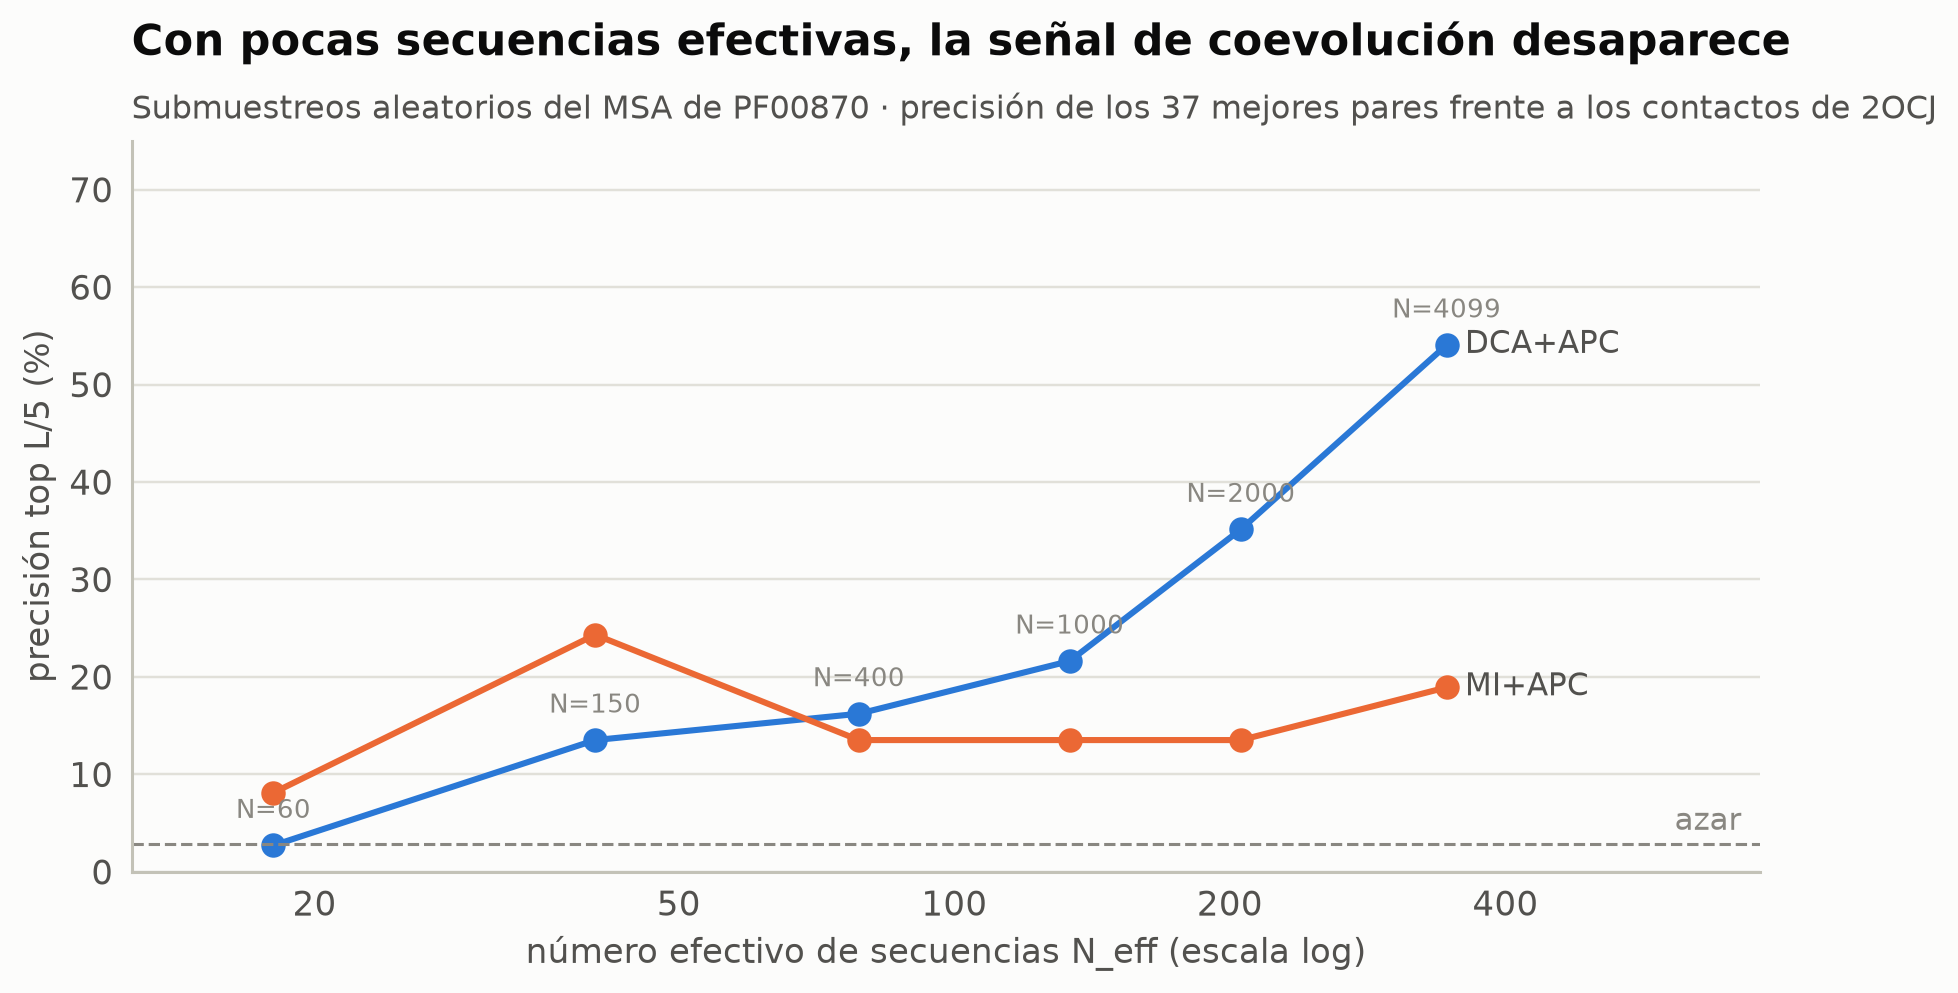

In [18]:
n_par = math.comb(200, 2) * 400
print(f"pares = {math.comb(200, 2):,} · parámetros J = {n_par:,} ≈ {n_par / 1e6:.1f} millones (+ {200 * 20:,} campos h)")

# ¿Cuántas secuencias hacen falta? Submuestreamos el MSA real y repetimos el DCA
rng_sub = np.random.default_rng(15)
rows = []
for n_sub in (60, 150, 400, 1000, 2000, len(X)):
    pick = rng_sub.choice(len(X), size=n_sub, replace=False) if n_sub < len(X) else np.arange(len(X))
    Xs = X[pick]; ws = weights(Xs)
    sc_s, neff_s = dca_scores(Xs, ws)
    o = ranked(sc_s["DCA_APC"]); om = ranked(sc_s["MI_APC"])
    rows.append(dict(N=n_sub, Neff=neff_s, dca=is_contact[o[:Lc // 5]].mean(), mi=is_contact[om[:Lc // 5]].mean()))
sub_df = pd.DataFrame(rows)
print(sub_df.round(2).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(sub_df.Neff, sub_df.dca * 100, "o-", color=ec.BLUE, lw=2)
ax.plot(sub_df.Neff, sub_df.mi * 100, "o-", color=ec.ORANGE, lw=2)
ax.axhline(is_contact.mean() * 100, color=ec.MUTED, ls="--", lw=1)
ax.set_xscale("log")
ec.label_end(ax, sub_df.Neff.iloc[-1], sub_df.dca.iloc[-1] * 100, "DCA+APC")
ec.label_end(ax, sub_df.Neff.iloc[-1], sub_df.mi.iloc[-1] * 100, "MI+APC")
ax.text(sub_df.Neff.max() * 2.1, is_contact.mean() * 100 + 1.5, "azar", ha="right", color=ec.MUTED, fontsize=10)
for _, r_ in sub_df.iterrows():
    ax.annotate(f"N={int(r_.N)}", (r_.Neff, r_.dca * 100), xytext=(0, 9), textcoords="offset points",
                ha="center", fontsize=8.5, color=ec.MUTED)
ax.set_xlabel("número efectivo de secuencias N_eff (escala log)"); ax.set_ylabel("precisión top L/5 (%)")
ax.set_xlim(sub_df.Neff.min() * 0.7, sub_df.Neff.max() * 2.2); ax.set_ylim(0, 75)
ax.set_xticks([20, 50, 100, 200, 400], ["20", "50", "100", "200", "400"]); ax.minorticks_off()
ec.title(ax, "Con pocas secuencias efectivas, la señal de coevolución desaparece",
         "Submuestreos aleatorios del MSA de PF00870 · precisión de los 37 mejores pares frente a los contactos de 2OCJ")
plt.show()

> 🔎 **Qué observamos.** Unos ocho millones de parámetros para una proteína de 200 residuos, como dice el libro. Con
> pocas secuencias efectivas la precisión se acerca al azar, y crece a medida que el alineamiento se hace más profundo.
> La familia de p53 es pequeña ($N_{\text{eff}}$ de unos cientos): los métodos modernos usan alineamientos con miles o
> decenas de miles de secuencias efectivas. Para familias pequeñas, proteínas huérfanas o anticuerpos, la señal es débil,
> y esa limitación reaparece en todo método que dependa del MSA, **incluido AlphaFold2**.

> ✅ **Compruebe su comprensión.** ¿Por qué se reduce el peso de las secuencias casi idénticas? *Porque 200 p53 de
> mamíferos casi idénticas no son 200 «experimentos evolutivos» independientes: comparten sus mutaciones por herencia.
> Sin pesos, esa redundancia inflaría correlaciones que son filogenia, no contacto.*

---

## 7. AlphaFold2 por dentro

En CASP14 (2020), un sistema de DeepMind obtuvo predicciones cuya exactitud, para la mayoría de las dianas, era comparable
a la de las estructuras experimentales. Jumper y colaboradores (2021) describieron el método, **AlphaFold2**, con una
exactitud mediana del esqueleto de **0,96 Å** (RMSD de los C$_\alpha$ sobre el 95 % de los residuos), frente a 2,8 Å
del siguiente mejor método. No fue un avance incremental: fue un cambio de régimen.

AlphaFold2 **no abandona la coevolución: la aprende**. En lugar de extraer contactos con un modelo estadístico fijo (como
nuestro DCA) y luego plegar, entrena una red neuronal de extremo a extremo que lee el MSA y produce directamente
coordenadas atómicas. Su arquitectura tiene tres partes.

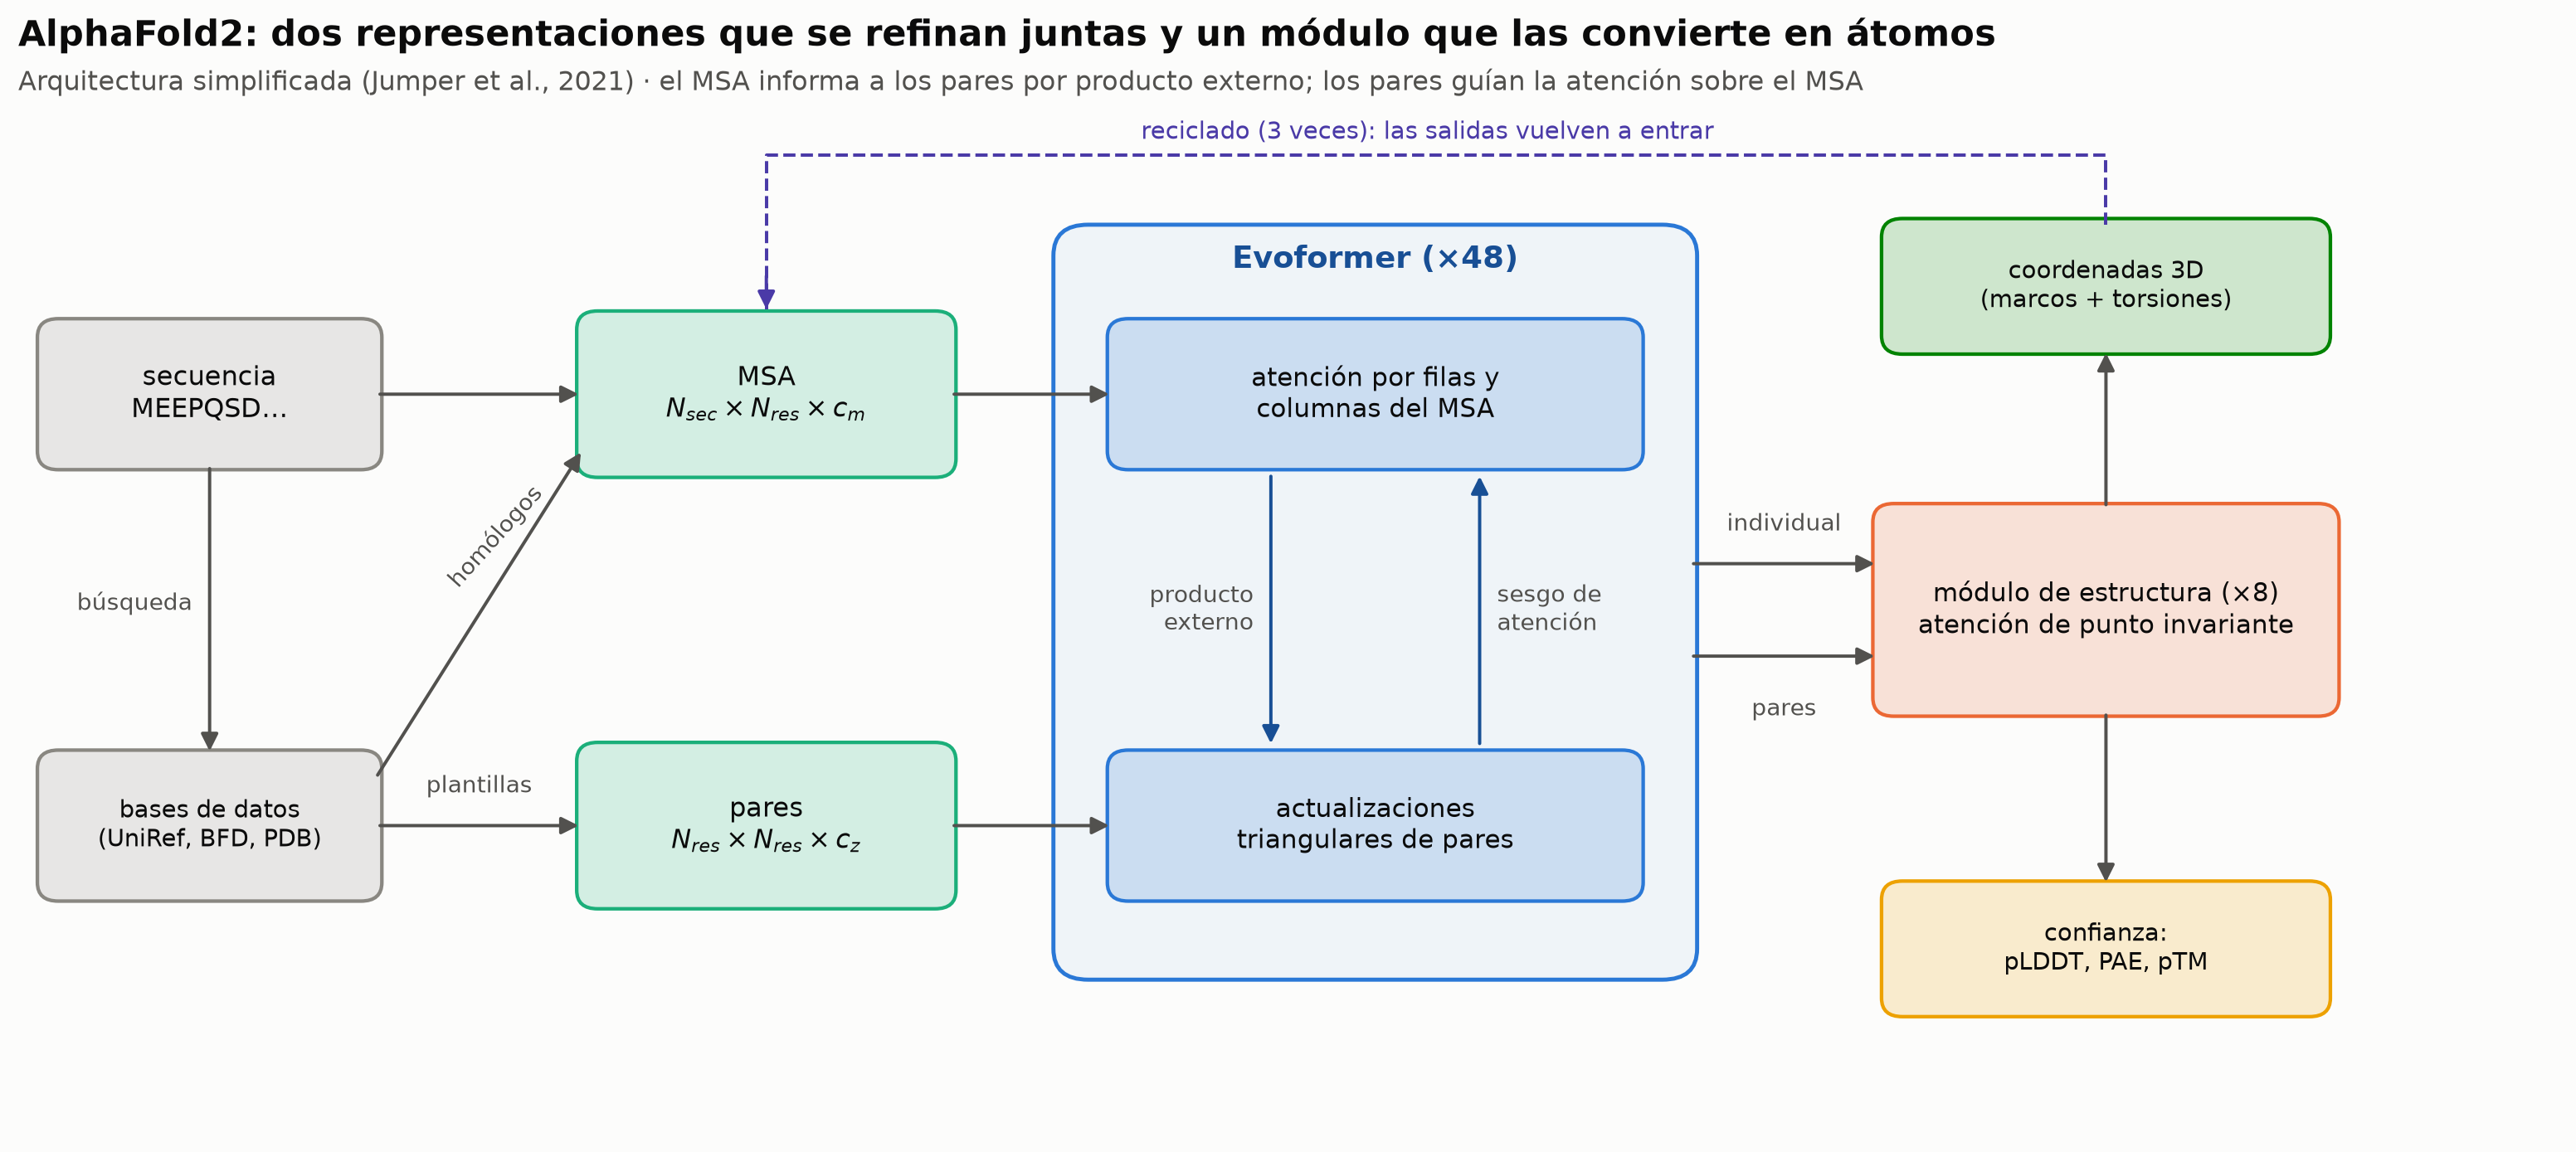

In [19]:
# Esquema de la arquitectura de AlphaFold2 (reproduce la figura del libro)
fig, ax = plt.subplots(figsize=(14, 6.2))
ax.set_xlim(-1.4, 13.2); ax.set_ylim(-3.6, 3.0); ax.axis("off"); ax.grid(False)
def box(x, y, w, h, text, col, fs=10.5, bold=False):
    ax.add_patch(FancyBboxPatch((x - w / 2, y - h / 2), w, h, boxstyle="round,pad=0.04,rounding_size=0.12",
                                fc=col, ec="none", alpha=0.18))
    ax.add_patch(FancyBboxPatch((x - w / 2, y - h / 2), w, h, boxstyle="round,pad=0.04,rounding_size=0.12",
                                fc="none", ec=col, lw=1.4))
    ax.text(x, y, text, ha="center", va="center", fontsize=fs, color=ec.INK, fontweight="bold" if bold else "normal")
def arrow(x0, y0, x1, y1, col=ec.INK_2, text=None, dy=0.18, ls="-"):
    ax.add_patch(FancyArrowPatch((x0, y0), (x1, y1), arrowstyle="-|>", mutation_scale=14, color=col, lw=1.3, ls=ls))
    if text:
        ax.text((x0 + x1) / 2, (y0 + y1) / 2 + dy, text, ha="center", va="bottom", fontsize=9, color=ec.INK_2)
box(-0.3, 1.2, 1.9, 0.9, "secuencia\nMEEPQSD…", ec.MUTED)
box(-0.3, -1.6, 1.9, 0.9, "bases de datos\n(UniRef, BFD, PDB)", ec.MUTED, fs=9.5)
box(2.9, 1.2, 2.1, 1.0, "MSA\n$N_{sec}\\times N_{res}\\times c_m$", ec.AQUA)
box(2.9, -1.6, 2.1, 1.0, "pares\n$N_{res}\\times N_{res}\\times c_z$", ec.AQUA)
arrow(0.65, 1.2, 1.85, 1.2)
arrow(-0.3, 0.75, -0.3, -1.15, text=None); ax.text(-0.4, -0.2, "búsqueda", ha="right", fontsize=9, color=ec.INK_2)
arrow(0.65, -1.3, 1.85, 0.85); ax.text(1.05, -0.05, "homólogos", fontsize=9, color=ec.INK_2, rotation=48)
arrow(0.65, -1.6, 1.85, -1.6, text="plantillas")
ax.add_patch(FancyBboxPatch((4.6, -2.55), 3.6, 4.8, boxstyle="round,pad=0.05,rounding_size=0.2", fc=ec.BLUE, alpha=0.06, ec="none"))
ax.add_patch(FancyBboxPatch((4.6, -2.55), 3.6, 4.8, boxstyle="round,pad=0.05,rounding_size=0.2", fc="none", ec=ec.BLUE, lw=1.6))
ax.text(6.4, 2.02, "Evoformer (×48)", ha="center", fontsize=12, fontweight="bold", color="#184f95")
box(6.4, 1.2, 3.0, 0.9, "atención por filas y\ncolumnas del MSA", ec.BLUE, fs=10)
box(6.4, -1.6, 3.0, 0.9, "actualizaciones\ntriangulares de pares", ec.BLUE, fs=10)
arrow(5.8, 0.7, 5.8, -1.1, col="#184f95"); ax.text(5.7, -0.2, "producto\nexterno", ha="right", va="center", fontsize=9, color=ec.INK_2)
arrow(7.0, -1.1, 7.0, 0.7, col="#184f95"); ax.text(7.1, -0.2, "sesgo de\natención", ha="left", va="center", fontsize=9, color=ec.INK_2)
arrow(3.95, 1.2, 4.9, 1.2); arrow(3.95, -1.6, 4.9, -1.6)
box(10.6, -0.2, 2.6, 1.3, "módulo de estructura (×8)\natención de punto invariante", ec.ORANGE, fs=10)
arrow(8.2, 0.1, 9.3, 0.1, text="individual"); arrow(8.2, -0.5, 9.3, -0.5, text="pares", dy=-0.42)
box(10.6, 1.9, 2.5, 0.8, "coordenadas 3D\n(marcos + torsiones)", ec.GREEN, fs=9.5)
box(10.6, -2.4, 2.5, 0.8, "confianza:\npLDDT, PAE, pTM", ec.YELLOW, fs=9.5)
arrow(10.6, 0.45, 10.6, 1.5); arrow(10.6, -0.85, 10.6, -2.0)
ax.plot([10.6, 10.6, 2.9, 2.9], [2.3, 2.75, 2.75, 1.75], color=ec.VIOLET, ls="--", lw=1.3)
ax.add_patch(FancyArrowPatch((2.9, 2.0), (2.9, 1.72), arrowstyle="-|>", mutation_scale=14, color=ec.VIOLET, lw=1.3))
ax.text(6.7, 2.82, "reciclado (3 veces): las salidas vuelven a entrar", ha="center", va="bottom", fontsize=9.5, color=ec.VIOLET)
ec.title(ax, "AlphaFold2: dos representaciones que se refinan juntas y un módulo que las convierte en átomos",
         "Arquitectura simplificada (Jumper et al., 2021) · el MSA informa a los pares por producto externo; los pares guían la atención sobre el MSA")
plt.show()

> 🔎 **Qué observamos.** Hay dos «pizarras» que se escriben en paralelo: la del **MSA** (una fila por secuencia, una
> columna por residuo) y la de **pares** (una celda por pareja de residuos). El Evoformer las hace conversar 48 veces;
> el módulo de estructura traduce el resultado a coordenadas, y todo se repite tres veces (reciclado).

### 7.1 Entradas: dos tensores

La secuencia se busca en grandes bases de datos con herramientas como las de la lección 4 (`jackhmmer`, `HHblits`)
para construir un MSA, y en el PDB para encontrar plantillas. El MSA se inicializa como un tensor
$N_{\mathrm{sec}}\times N_{\mathrm{res}}\times c_m$ (un vector de dimensión $c_m$ por cada letra del alineamiento) y la
representación de pares como un tensor $N_{\mathrm{res}}\times N_{\mathrm{res}}\times c_z$, en el que la celda $(i,j)$
acabará codificando todo lo que la red «cree» sobre la relación espacial entre los residuos $i$ y $j$.

| Símbolo | Significado |
|---|---|
| $N_{\mathrm{sec}}$ | Número de secuencias del MSA que entran a la red |
| $N_{\mathrm{res}}$ | Número de residuos de la proteína (393 para p53) |
| $c_m$, $c_z$ | Número de canales (dimensión del vector) por celda del MSA y de pares |

La representación de pares crece con el **cuadrado** de la longitud. Para p53 ya son $393^2=154\,449$ celdas, cada una
con un vector de $c_z$ números. Calculemos cuánta memoria ocupa por cada canal y cómo escala.

In [20]:
for n in (100, 393, 1000, 2500):
    cells = n * n
    print(f"N_res = {n:5d}: {cells:>10,} celdas de pares · {cells * 4 / 1e6:8.1f} MB por canal (float32)"
          f" · ×100 canales = {cells * 4 * 100 / 1e9:6.2f} GB")

N_res =   100:     10,000 celdas de pares ·      0.0 MB por canal (float32) · ×100 canales =   0.00 GB
N_res =   393:    154,449 celdas de pares ·      0.6 MB por canal (float32) · ×100 canales =   0.06 GB
N_res =  1000:  1,000,000 celdas de pares ·      4.0 MB por canal (float32) · ×100 canales =   0.40 GB
N_res =  2500:  6,250,000 celdas de pares ·     25.0 MB por canal (float32) · ×100 canales =   2.50 GB


> 🔎 **Qué observamos.** Duplicar la longitud cuadruplica la memoria. Ésa es una de las razones por las que las
> proteínas muy grandes se predicen por fragmentos, como los modelos `F1`, `F2`… de AlphaFold DB para proteínas de más
> de 2700 residuos.

### 7.2 El Evoformer y la atención

El corazón del Evoformer es la **atención**, el mecanismo de los *transformers*. Piense en una reunión en la que cada
participante ($i$) hace una pregunta (su **consulta** $\mathbf q_i$), cada uno de los demás ($j$) muestra una etiqueta
con lo que sabe (su **clave** $\mathbf k_j$) y lo que tiene para contar (su **valor** $\mathbf v_j$). El participante $i$
presta más atención a quienes tienen una etiqueta parecida a su pregunta y resume lo que cuentan:

$$
\mathbf o_i=\sum_{j=1}^{n}\alpha_{ij}\,\mathbf v_j,\qquad
\alpha_{ij}=\frac{\exp\!\big(\mathbf q_i^\top\mathbf k_j/\sqrt{c}+b_{ij}\big)}{\sum_{j'}\exp\!\big(\mathbf q_i^\top\mathbf k_{j'}/\sqrt{c}+b_{ij'}\big)} .
$$

| Símbolo | Significado |
|---|---|
| $\mathbf q_i,\mathbf k_j,\mathbf v_j$ | Consulta, clave y valor: proyecciones lineales aprendidas de las entradas |
| $\alpha_{ij}$ | Peso de atención de la posición $i$ sobre la $j$; los pesos de cada $i$ suman 1 (*softmax*) |
| $c$ | Dimensión de las consultas y claves; $\sqrt c$ estabiliza la escala del producto escalar |
| $b_{ij}$ | Sesgo aditivo; en AlphaFold2 procede de la representación de pares |

**Ejemplo a mano.** Tres residuos, $c=4$. Los productos $\mathbf q_1^\top\mathbf k_j$ valen $(2,\,1,\,0)$; divididos por
$\sqrt4=2$ quedan $(1;\ 0{,}5;\ 0)$. Sus exponenciales: $e^1=2{,}718$, $e^{0{,}5}=1{,}649$, $e^0=1$, que suman $5{,}367$.
Los pesos son $\alpha_{1\cdot}=(0{,}506;\ 0{,}307;\ 0{,}186)$: el residuo 1 atiende sobre todo al 1.

Ahora supongamos que la representación de pares «cree» que el residuo 3 está en contacto con el 1 y aporta un sesgo
$b_{13}=+2$. Los argumentos pasan a $(1;\ 0{,}5;\ 2)$, con exponenciales $2{,}718;\ 1{,}649;\ 7{,}389$ (suma $11{,}756$), y
los pesos a $(0{,}231;\ 0{,}140;\ 0{,}629)$. **La geometría supuesta cambió a quién escucha el residuo 1.**

sin sesgo : [0.506 0.307 0.186]  suma = 0.9999999999999999
con b13=+2: [0.231 0.14  0.629]
salida o_1 sin sesgo: [0.32  0.121]  · con sesgo: [-0.397 -0.488]


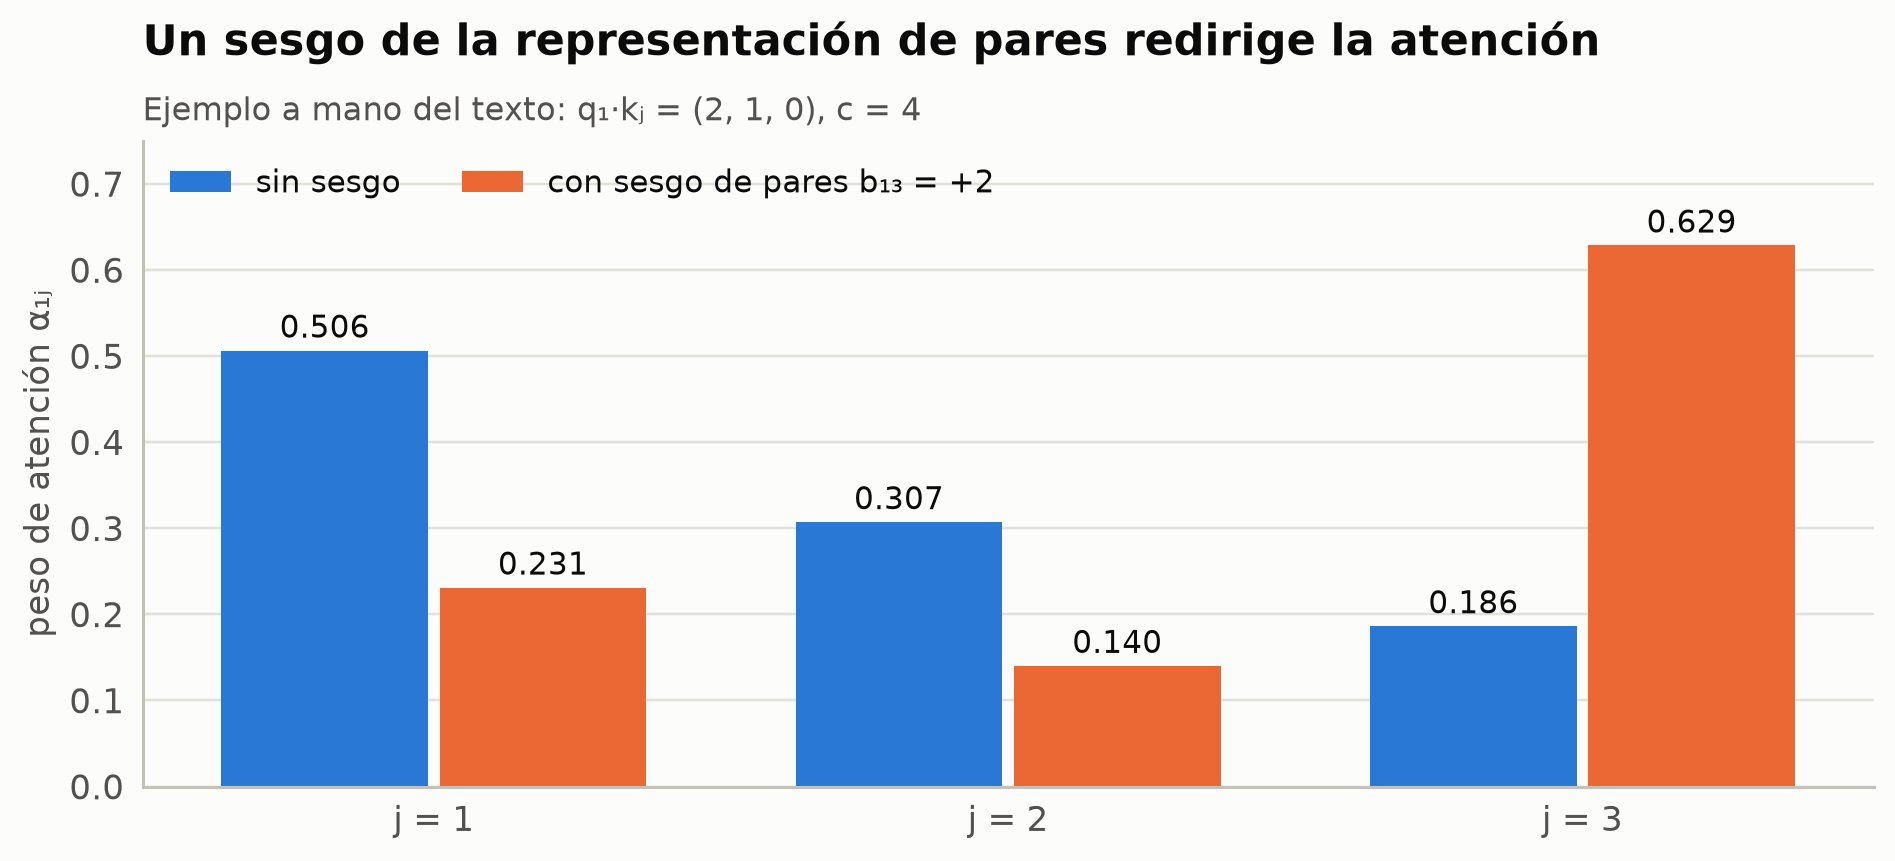

In [21]:
def attention_weights(qk, c, b=None):
    """Pesos de atención (softmax) a partir de los productos q·k, la dimensión c y un sesgo opcional."""
    z = np.asarray(qk, float) / np.sqrt(c) + (0 if b is None else np.asarray(b, float))
    e = np.exp(z - z.max())                  # restar el máximo no cambia el resultado y evita desbordes
    return e / e.sum()

qk = [2, 1, 0]
a0 = attention_weights(qk, 4)
a1 = attention_weights(qk, 4, b=[0, 0, 2])
print("sin sesgo :", a0.round(3), " suma =", a0.sum())
print("con b13=+2:", a1.round(3))
v = np.array([[1.0, 0.0], [0.0, 1.0], [-1.0, -1.0]])      # valores de juguete (2 dimensiones)
print("salida o_1 sin sesgo:", (a0 @ v).round(3), " · con sesgo:", (a1 @ v).round(3))

fig, ax = plt.subplots(figsize=(8.5, 3.8))
xk = np.arange(3)
ax.bar(xk - 0.19, a0, width=0.36, color=ec.BLUE, label="sin sesgo")
ax.bar(xk + 0.19, a1, width=0.36, color=ec.ORANGE, label="con sesgo de pares b₁₃ = +2")
for x_, a_, b_ in zip(xk, a0, a1):
    ax.text(x_ - 0.19, a_ + 0.015, f"{a_:.3f}", ha="center", fontsize=10)
    ax.text(x_ + 0.19, b_ + 0.015, f"{b_:.3f}", ha="center", fontsize=10)
ax.set_xticks(xk, ["j = 1", "j = 2", "j = 3"]); ax.set_ylabel("peso de atención α₁ⱼ"); ax.set_ylim(0, 0.75)
ax.legend(loc="upper left", ncols=2, bbox_to_anchor=(0, 1.0))
ec.title(ax, "Un sesgo de la representación de pares redirige la atención",
         "Ejemplo a mano del texto: q₁·kⱼ = (2, 1, 0), c = 4")
plt.show()

> 🔎 **Qué observamos.** Los pesos siempre suman 1; el sesgo no «añade» atención, la **redistribuye**. En AlphaFold2
> esa redistribución es la vía por la que la geometría que la red va construyendo guía la lectura del alineamiento.

En el Evoformer la atención se aplica en varias direcciones:

* **por filas del MSA**: cada secuencia mira a lo largo de sus residuos, con el sesgo $b_{ij}$ tomado de la
  representación de pares;
* **por columnas del MSA**: cada posición compara lo que ocurre en distintas secuencias, que es **donde vive la
  coevolución** que medimos en la sección 6;
* **sobre la propia representación de pares**, con las **actualizaciones triangulares**: la celda $(i,j)$ se actualiza
  combinando las celdas $(i,k)$ y $(k,j)$ para todos los $k$.

Finalmente, un **producto externo** promediado sobre las secuencias del MSA transfiere la información de coevolución a la
representación de pares.

### 7.3 ¿Por qué triángulos? La desigualdad triangular en una proteína real

Las distancias de cualquier objeto tridimensional cumplen la **desigualdad triangular**: $d_{ij}\le d_{ik}+d_{kj}$.
Si la red sabe que $i$ toca a $k$ (≈ 6 Å) y $k$ toca a $j$ (≈ 6 Å), ya sabe que $d_{ij}\le12$ Å aunque nadie le haya
dicho nada sobre el par $(i,j)$. Encadenando triángulos, **unos pocos contactos restringen todas las distancias**.

Comprobémoslo con el cristal `2OCJ`: fingimos conocer **sólo** los contactos (pares de C$_\alpha$ a menos de 8 Å, con su
distancia) y calculamos, para todos los demás pares, la cota superior que imponen los triángulos encadenados (el camino
más corto por el grafo de contactos).

🤔 **Antes de ejecutar, prediga:** ¿las cotas serán muy holgadas (inútiles) o seguirán de cerca a las distancias reales?

pares con |i−j| ≥ 6: 17,766 · conocidos (contacto): 442 (2.5%)
cota ≥ distancia real en el 100 % de los casos: True
correlación cota–real en pares desconocidos: r = 0.97; cota media / real media = 26.1 / 22.4 Å


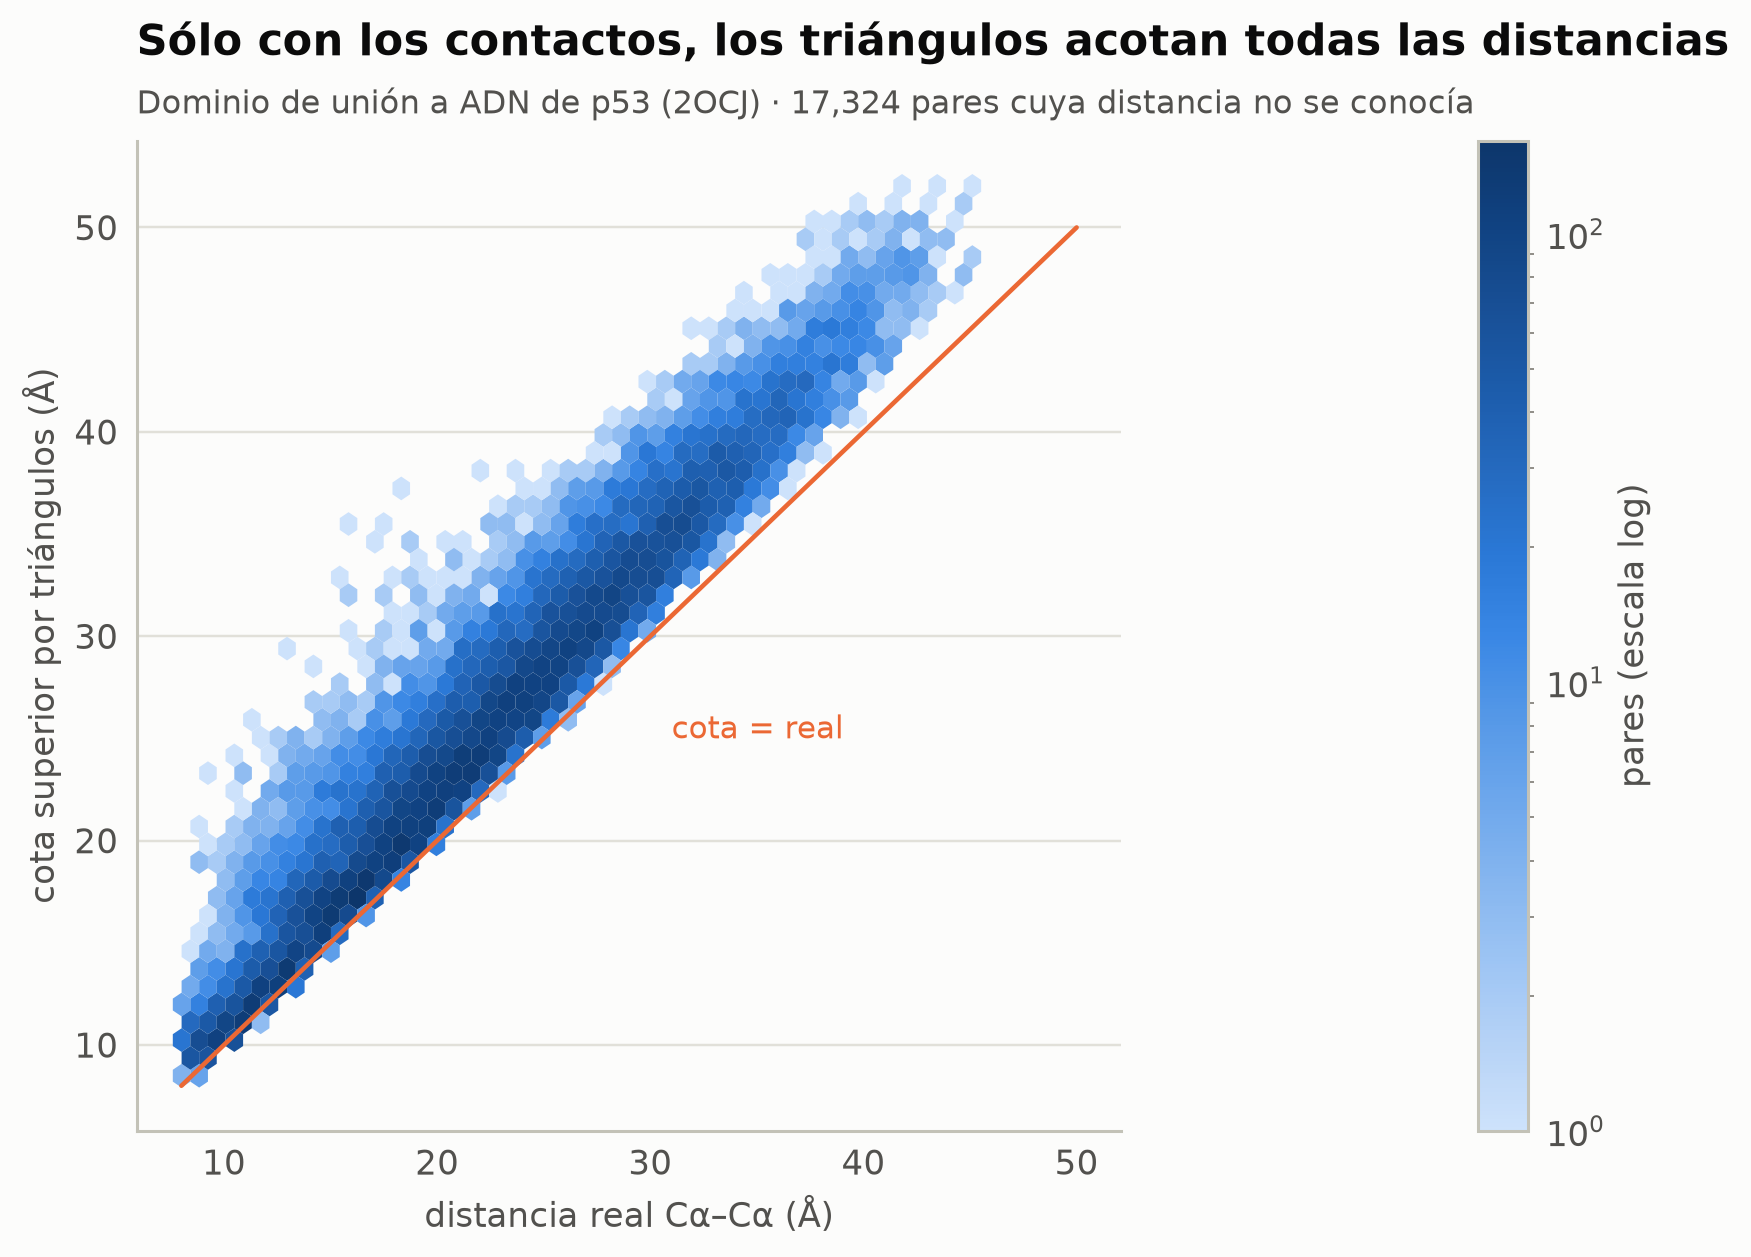

In [22]:
from scipy.sparse.csgraph import shortest_path
ca_x = np.array([xtal[r][0] for r in sorted(xtal)])
Dx = np.linalg.norm(ca_x[:, None] - ca_x[None], axis=2)
known = np.where(Dx < 8, Dx, 0)                       # sólo conocemos las distancias de contacto
bound = shortest_path(known, method="D", directed=False)
iu = np.triu_indices(len(Dx), k=6)
real, ub = Dx[iu], bound[iu]
far = real >= 8                                        # pares cuya distancia NO conocíamos
print(f"pares con |i−j| ≥ 6: {len(real):,} · conocidos (contacto): {(~far).sum():,} ({(~far).mean():.1%})")
print(f"cota ≥ distancia real en el 100 % de los casos: {np.all(ub >= real - 1e-9)}")
print(f"correlación cota–real en pares desconocidos: r = {np.corrcoef(ub[far], real[far])[0, 1]:.2f}; "
      f"cota media / real media = {ub[far].mean():.1f} / {real[far].mean():.1f} Å")

fig, ax = plt.subplots(figsize=(7.5, 5.6))
hb = ax.hexbin(real[far], ub[far], gridsize=45, cmap=ec.CMAP_SEQ, mincnt=1, bins="log")
ax.plot([8, 50], [8, 50], color=ec.ORANGE, lw=1.5)
ax.text(31, 25, "cota = real", color=ec.ORANGE, fontsize=10, ha="left")
ax.set_xlabel("distancia real Cα–Cα (Å)"); ax.set_ylabel("cota superior por triángulos (Å)")
fig.colorbar(hb, ax=ax, label="pares (escala log)")
ec.title(ax, "Sólo con los contactos, los triángulos acotan todas las distancias",
         f"Dominio de unión a ADN de p53 (2OCJ) · {len(real[far]):,} pares cuya distancia no se conocía")
plt.show()

> 🔎 **Qué observamos.** Todas las cotas son válidas (nunca menores que la distancia real) y siguen de cerca a las
> distancias reales: conocer sólo los contactos, menos del 3 % de los pares, ya determina aproximadamente la forma
> completa. Las actualizaciones triangulares del Evoformer hacen que cada par «razone» sobre los triángulos que forma con
> terceros residuos e imponen consistencia tridimensional **antes de que exista ninguna coordenada**.

### 7.4 El módulo de estructura: un marco rígido por residuo

Cada residuo se representa como un **cuerpo rígido**, con un **marco local** (una rotación $\mathbf R_i$ y una traslación
$\mathbf t_i$) definido por sus átomos N, C$_\alpha$ y C, que al principio están todos en el origen. Durante ocho bloques
con pesos compartidos, la **atención de punto invariante** (IPA) actualiza esos marcos. Es una atención en la que las
consultas y claves incluyen puntos tridimensionales expresados en el marco de cada residuo, construida para que el resultado
**no cambie si se rota o traslada toda la estructura**. Al final se predicen los ángulos de torsión de las cadenas
laterales y, con ellos, las coordenadas de todos los átomos pesados.

Construyamos el marco local de un residuo real (Arg175, un punto caliente de cáncer) con el procedimiento de
Gram-Schmidt y comprobemos la invariancia: las coordenadas de un vecino **vistas desde ese marco** no cambian si rotamos
y trasladamos la proteína entera.

In [23]:
def frame(n, ca, c):
    """Marco local (R, t) de un residuo a partir de N, CA y C (Gram-Schmidt): columnas de R = ejes x, y, z."""
    e1 = (c - ca) / np.linalg.norm(c - ca)
    u2 = (n - ca) - ((n - ca) @ e1) * e1
    e2 = u2 / np.linalg.norm(u2)
    return np.column_stack([e1, e2, np.cross(e1, e2)]), ca

def atom(df, r, name):
    a = df[(df.resnum == r) & (df.atom == name) & (df.record == "ATOM")].iloc[0]
    return np.array([a.x, a.y, a.z])

R175, t175 = frame(atom(af_df, 175, "N"), atom(af_df, 175, "CA"), atom(af_df, 175, "C"))
zn_neighbor = atom(af_df, 176, "SG")                    # azufre de Cys176, ligando del zinc estructural
local = R175.T @ (zn_neighbor - t175)
print("R ortonormal:", np.allclose(R175.T @ R175, np.eye(3)), "· det(R) =", round(np.linalg.det(R175), 3))
print("Cys176 SG en el marco de Arg175 (Å):", local.round(2))

# Rotamos y trasladamos TODA la proteína al azar
rng_rot = np.random.default_rng(7)
Qm, _ = np.linalg.qr(rng_rot.normal(size=(3, 3)))
Qm *= np.sign(np.linalg.det(Qm))                        # rotación propia (det = +1)
shift = rng_rot.normal(0, 30, 3)
moved = af_df.copy(); moved[["x", "y", "z"]] = af_df[["x", "y", "z"]].values @ Qm.T + shift
R2, t2 = frame(atom(moved, 175, "N"), atom(moved, 175, "CA"), atom(moved, 175, "C"))
print("tras rotar y trasladar todo:        ", (R2.T @ (atom(moved, 176, "SG") - t2)).round(2), "→ idénticas")

R ortonormal: True · det(R) = 1.0
Cys176 SG en el marco de Arg175 (Å): [ 3.49 -3.98  0.7 ]
tras rotar y trasladar todo:         [ 3.49 -3.98  0.7 ] → idénticas


> 🔎 **Qué observamos.** El marco es una rotación válida (ortonormal, determinante $+1$) y las coordenadas del vecino
> vistas desde él no cambian con la pose global. Por eso AlphaFold2 no necesita «saber» dónde está la proteína en el
> espacio: razona sólo sobre posiciones relativas.

### 7.5 Entrenamiento y reciclado

La función de pérdida principal, **FAPE** (*frame aligned point error*), compara las posiciones atómicas predichas y
reales **expresadas en el marco local de cada residuo** (exactamente la operación de la celda anterior), lo que la hace
sensible también a la **quiralidad**: una estructura y su imagen especular tienen las mismas distancias, pero no las
mismas coordenadas locales (lo comprobaremos en la sección 8). La red se entrenó con estructuras del PDB y, en una segunda
fase, con predicciones propias de alta confianza sobre secuencias sin estructura (**autodestilación**). La salida completa
se vuelve a introducir como entrada tres veces (**reciclado**), lo que permite refinar progresivamente la predicción.

> ✅ **Compruebe su comprensión.** ¿En qué parte de AlphaFold2 «vive» la señal que en la sección 6 extrajimos con DCA?
> *En la atención por columnas del MSA (que compara posiciones a través de las secuencias) y en el producto externo que
> la transfiere a la representación de pares; allí la red aprende, en lugar de calcular con una fórmula fija, qué pares
> covarían por contacto.*

---

## 8. Confianza: lDDT, pLDDT y PAE

Una predicción sin estimación de su error sería peligrosa: un médico no aceptaría un análisis de laboratorio sin rango de
referencia. AlphaFold2 aprende a predecir, además de la estructura, **cuánto se equivoca**. Para entender qué predice,
primero hay que entender qué mide.

### 8.1 El lDDT: comparar sin superponer

El **lDDT** (*local Distance Difference Test*; Mariani et al., 2013) compara un modelo con la referencia **sin
superponerlos**. Para cada átomo $i$ se miran sus vecinos en la referencia (los que están a menos de $R_0=15$ Å) y se cuenta
qué fracción de esas distancias se conserva en el modelo, con cuatro tolerancias:

$$
\mathrm{lDDT}_i=\frac14\sum_{\tau\in\{0{,}5,\,1,\,2,\,4\}}\frac{\big|\{j:\ d^{\mathrm{ref}}_{ij}<R_0,\ |d^{\mathrm{mod}}_{ij}-d^{\mathrm{ref}}_{ij}|<\tau\}\big|}{\big|\{j:\ d^{\mathrm{ref}}_{ij}<R_0\}\big|} .
$$

El **pLDDT** es la predicción que hace la red de $100\times\mathrm{lDDT}_i$ (calculado sobre los C$_\alpha$) para cada
residuo, **sin conocer la estructura real**.

| Símbolo | Significado |
|---|---|
| $d^{\mathrm{ref}}_{ij},\ d^{\mathrm{mod}}_{ij}$ | Distancias entre los átomos $i$ y $j$ en la estructura de referencia y en el modelo |
| $R_0$ | Radio de inclusión: sólo cuentan los vecinos a menos de 15 Å en la referencia |
| $\tau$ | Tolerancias de 0,5, 1, 2 y 4 Å, promediadas |

**Ejemplo a mano.** Un residuo tiene 4 vecinos a menos de 15 Å en la referencia, y en el modelo sus distancias cambian
$|\Delta d|=0{,}3;\ 0{,}7;\ 1{,}5;\ 5{,}0$ Å. Con $\tau=0{,}5$ se conserva 1 de 4; con $\tau=1$, 2 de 4; con $\tau=2$, 3
de 4; con $\tau=4$, 3 de 4. Entonces $\mathrm{lDDT}_i=\tfrac14(0{,}25+0{,}5+0{,}75+0{,}75)=0{,}5625$, es decir, un
pLDDT «ideal» de 56.

In [24]:
dd_toy = np.array([0.3, 0.7, 1.5, 5.0])
print("lDDT a mano =", np.mean([np.mean(dd_toy < t) for t in (0.5, 1, 2, 4)]))

def lddt(model, ref, R0=15.0, taus=(0.5, 1, 2, 4)):
    """lDDT por residuo (sobre C-alfa) de un modelo frente a una referencia, con correspondencia fija."""
    Dr = np.linalg.norm(ref[:, None] - ref[None], axis=2)
    Dm = np.linalg.norm(model[:, None] - model[None], axis=2)
    mask = (Dr < R0) & ~np.eye(len(ref), dtype=bool)
    diff = np.abs(Dm - Dr)
    per = np.mean([((diff < t) & mask).sum(1) / mask.sum(1) for t in taus], axis=0)
    return per

# ¿Por qué FAPE y no sólo distancias? La imagen especular tiene exactamente las mismas distancias
ref_dbd = np.array([xtal[r][0] for r in sorted(xtal)])
mirror = ref_dbd * np.array([-1, 1, 1])
print(f"imagen especular de 2OCJ: lDDT = {lddt(mirror, ref_dbd).mean():.3f}  ·  RMSD tras Kabsch = {sup_rmsd(mirror, ref_dbd):.1f} Å")

lDDT a mano = 0.5625
imagen especular de 2OCJ: lDDT = 1.000  ·  RMSD tras Kabsch = 14.8 Å


> 🔎 **Qué observamos.** El lDDT de la imagen especular es perfecto (1,000): las distancias no distinguen una mano
> izquierda de una derecha. El RMSD tras la mejor rotación propia, en cambio, es de varios angstroms. Por eso AlphaFold2
> entrena con FAPE, que mide posiciones en marcos locales y sí «ve» la quiralidad, y usa el lDDT sólo como medida de
> confianza.

### 8.2 El pLDDT de p53 y sus cuatro bandas

Por ser local y no requerir superposición, el lDDT evalúa bien proteínas con varios dominios que se mueven entre sí, y el
pLDDT hereda esa propiedad: mide si el **entorno local** de cada residuo está bien predicho, no si los dominios están bien
colocados unos respecto a otros. Por convención se interpreta en cuatro bandas:

| Banda | pLDDT | Lectura práctica |
|---|---|---|
| muy alta | > 90 | Esqueleto y la mayoría de cadenas laterales fiables |
| segura | 70–90 | Esqueleto fiable |
| baja | 50–70 | Precaución: puede haber errores de esqueleto |
| muy baja | < 50 | No interpretar la forma; a menudo región intrínsecamente desordenada |

🤔 **Antes de ejecutar, prediga:** p53 tiene un dominio de transactivación N-terminal que, en solución, no tiene
estructura fija. ¿En qué banda caerá?

N-terminal (TAD + PRR)         1- 93: pLDDT medio = 48.4
Unión a ADN                   94-292: pLDDT medio = 95.3
Enlace                       293-324: pLDDT medio = 47.4
Tetramerización              325-356: pLDDT medio = 90.9
C-terminal                   357-393: pLDDT medio = 43.4


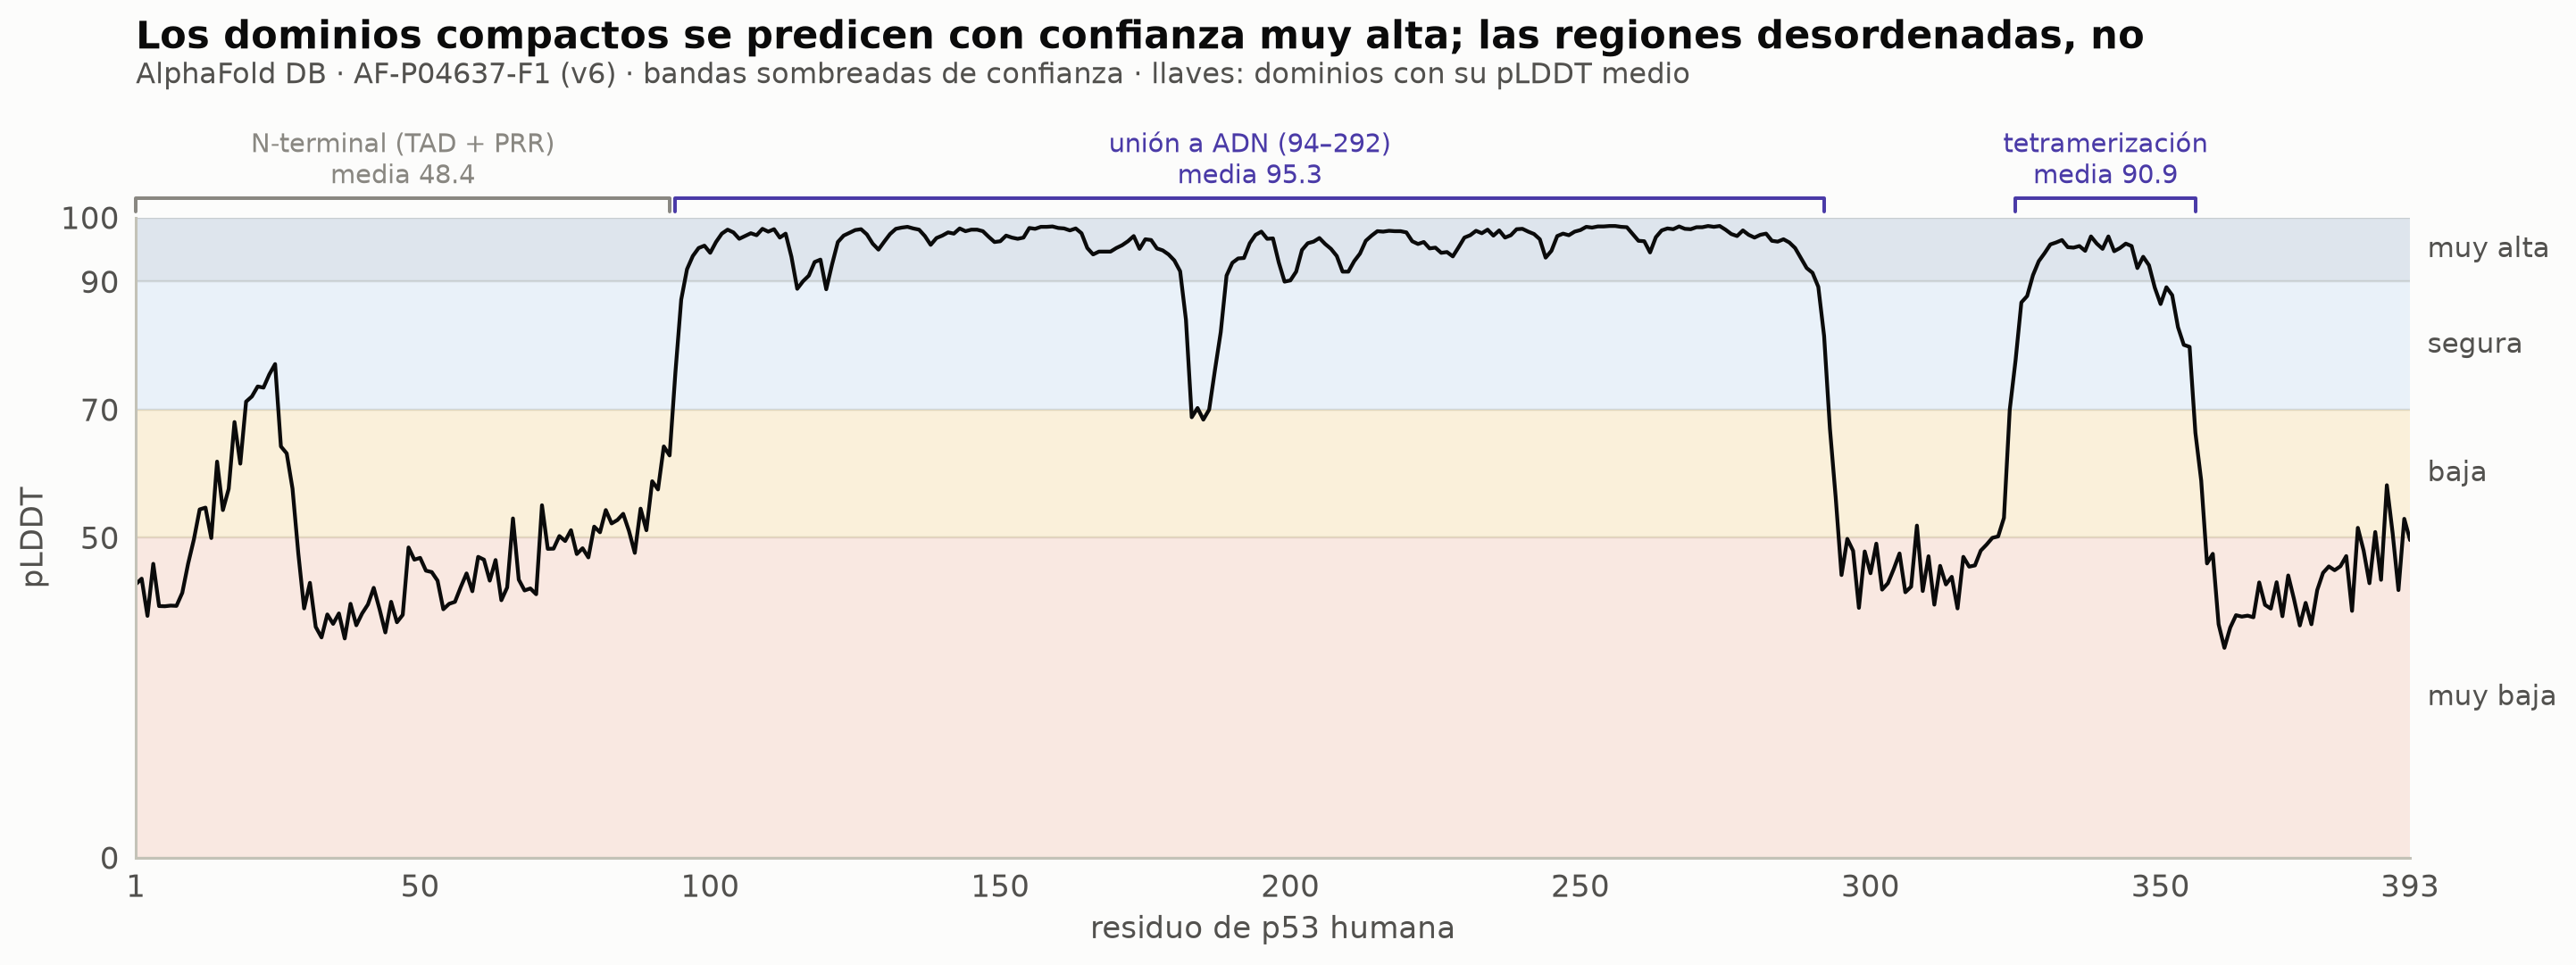

In [25]:
# pLDDT por residuo (reproduce la figura «pLDDT de la p53 humana» del libro)
dom_mean = {short: plddt[a - 1:b].mean() for a, b, name, short in DOMAINS}
for a, b, name, short in DOMAINS:
    print(f"{name:28s} {a:3d}-{b:3d}: pLDDT medio = {dom_mean[short]:.1f}")

fig, ax = plt.subplots(figsize=(13, 4.8))
for lo, hi, name in BANDS:
    ax.axhspan(lo, min(hi, 100), color=BAND_COLOR[name], alpha=0.13, lw=0)
    ax.text(396, (lo + min(hi, 100)) / 2, name, va="center", fontsize=10, color=ec.INK_2)
ax.plot(res, plddt, color=ec.INK, lw=1.4)
for a, b, name, short in [(1, 93, "N-terminal (TAD + PRR)", "TAD+PRR"), (94, 292, "unión a ADN (94–292)", "DBD"),
                          (325, 356, "tetramerización", "TET")]:
    col = ec.VIOLET if short != "TAD+PRR" else ec.MUTED
    ax.plot([a, a, b, b], [101, 103, 103, 101], color=col, lw=1.3, clip_on=False)
    ax.text((a + b) / 2, 104, f"{name}\nmedia {dom_mean[short]:.1f}", ha="center", va="bottom", fontsize=9.5,
            color=col, clip_on=False)
ax.set_xlim(1, 393); ax.set_ylim(0, 100); ax.set_yticks([0, 50, 70, 90, 100])
ax.set_xticks([1, 50, 100, 150, 200, 250, 300, 350, 393])
ax.set_xlabel("residuo de p53 humana"); ax.set_ylabel("pLDDT")
ax.set_title("Los dominios compactos se predicen con confianza muy alta; las regiones desordenadas, no", loc="left", pad=62)
ax.text(0, 1.21, "AlphaFold DB · AF-P04637-F1 (v6) · bandas sombreadas de confianza · llaves: dominios con su pLDDT medio",
        transform=ax.transAxes, fontsize=10.5, color=ec.INK_2)
plt.show()

> 🔎 **Qué observamos.** Son las cifras del libro: el dominio de unión a ADN (95,3) y el de tetramerización (90,9) están en
> la banda muy alta; la región N-terminal de transactivación y rica en prolina (48,4), el enlace entre dominios (47,4) y el extremo
> C-terminal (43,4) caen en la banda muy baja. Son regiones **intrínsecamente desordenadas**, que en la célula sólo
> adoptan estructura al unirse a otras proteínas. Veamos el modelo en 3D con cada C$_\alpha$ coloreado por su banda.

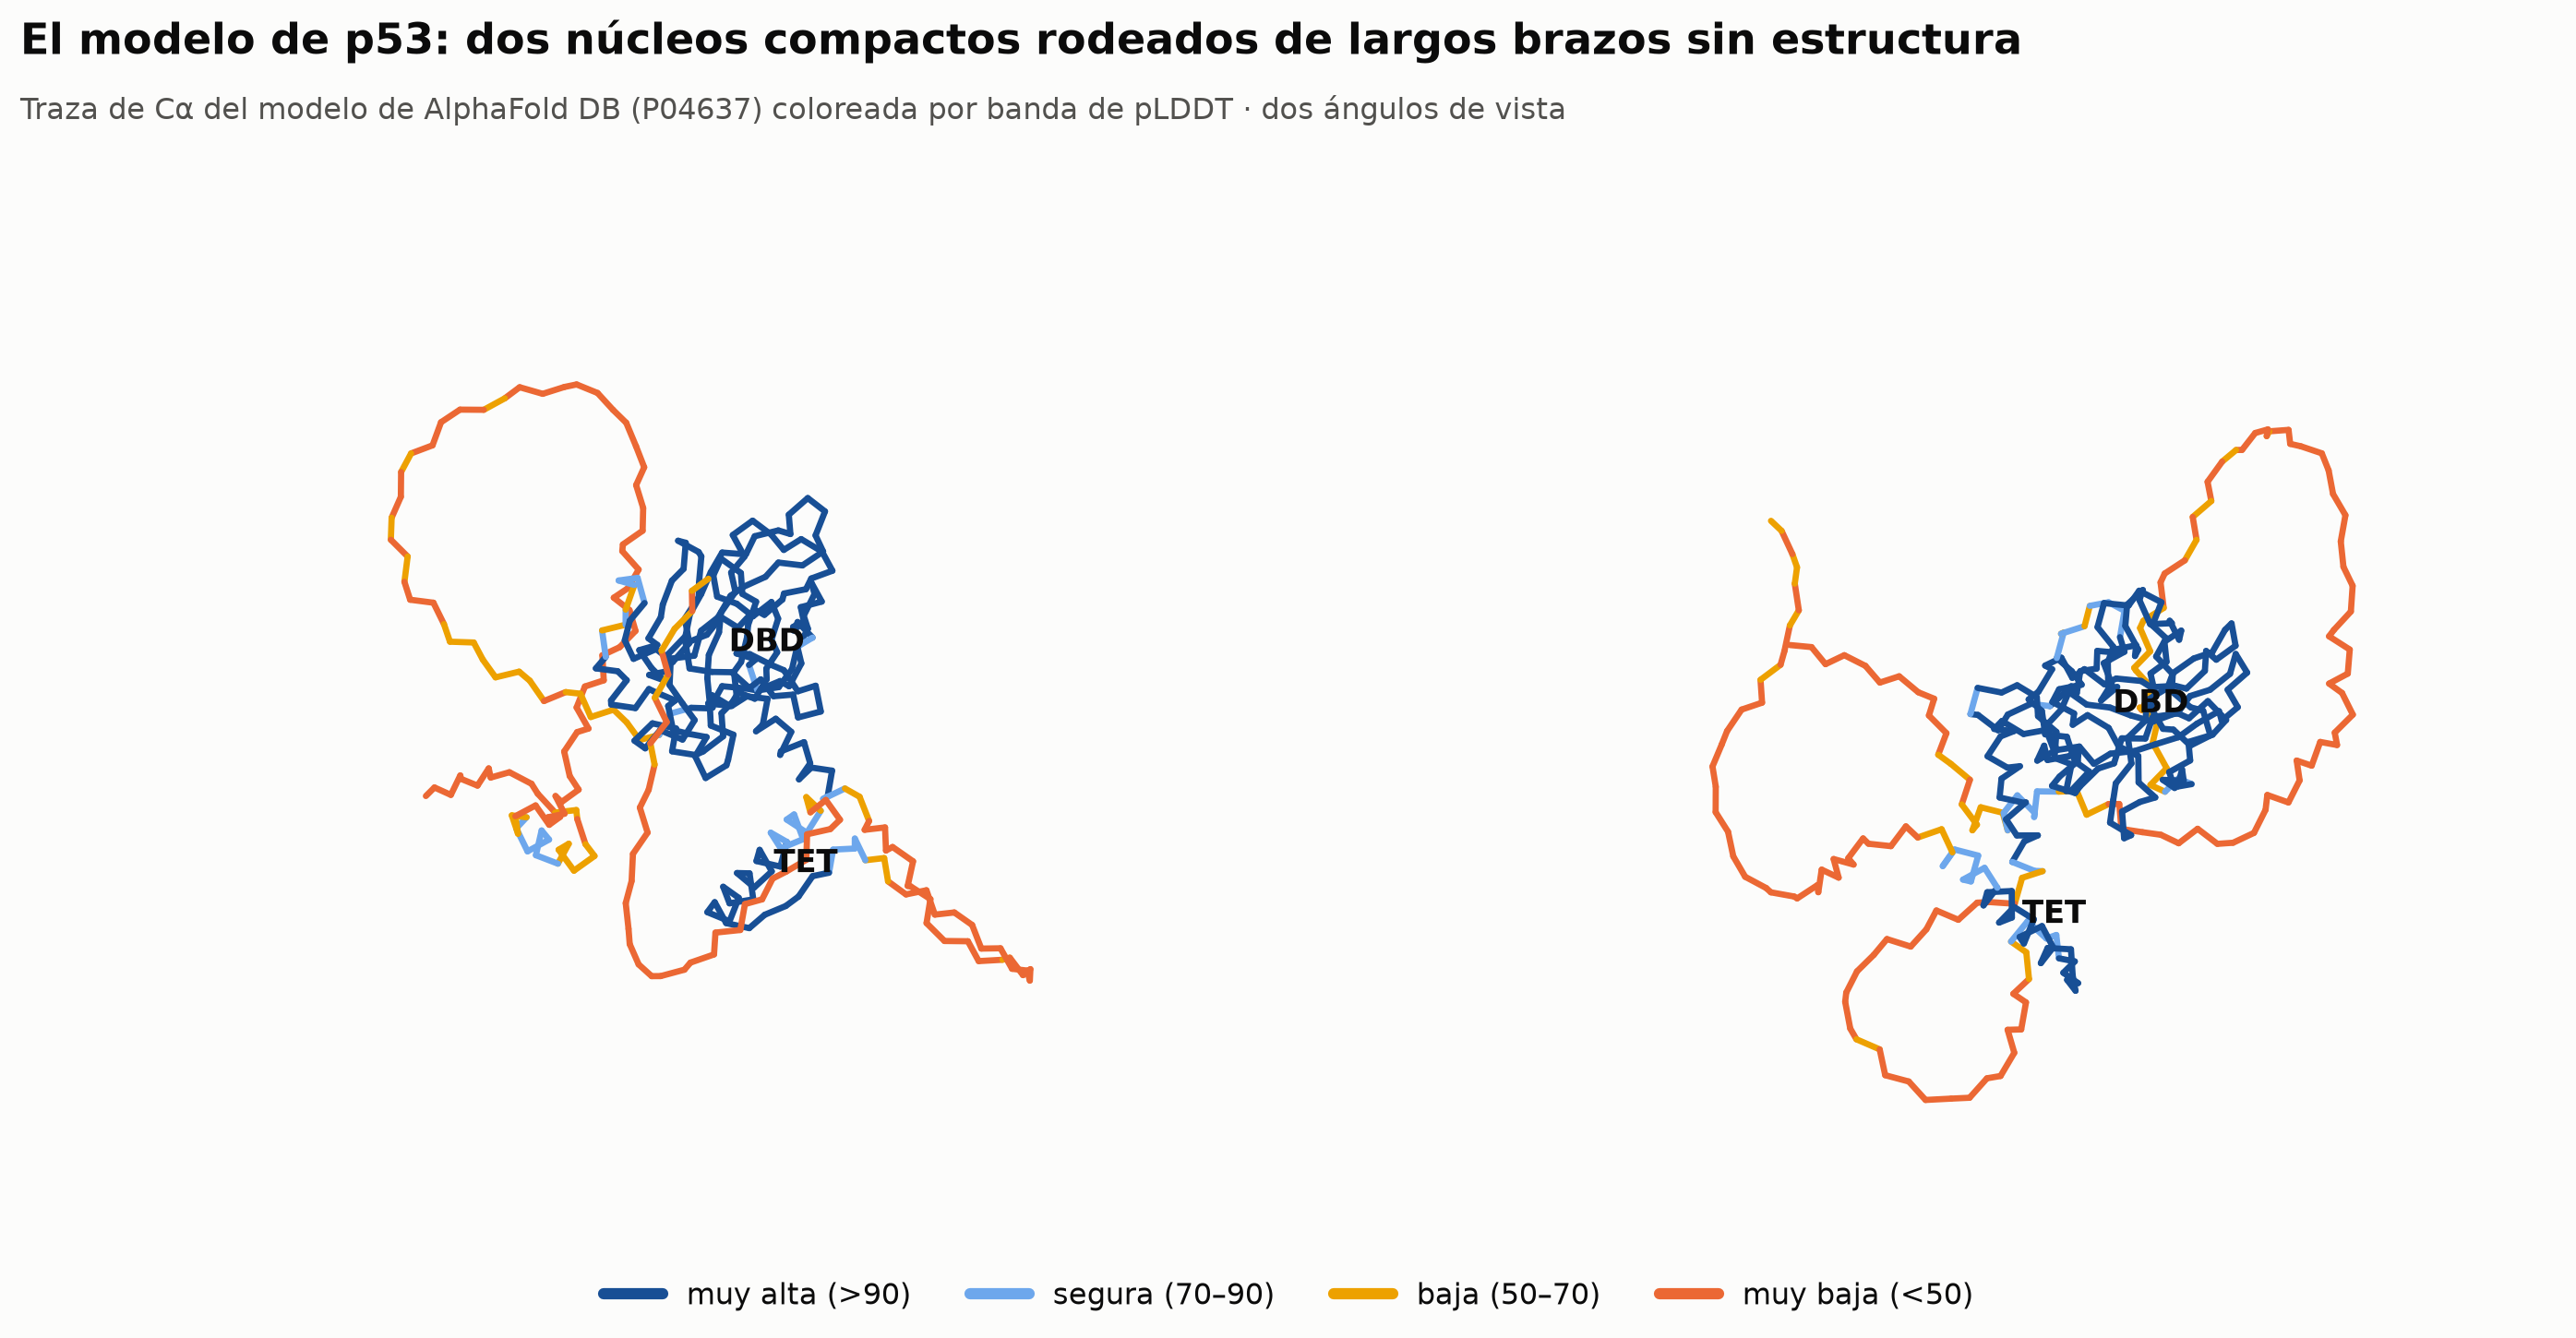

In [26]:
# Traza de C-alfa del modelo coloreada por banda de pLDDT (dos vistas)
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
CA_af = np.array([af[r][0] for r in res])
cols3d = [BAND_COLOR[band_of(v)] for v in plddt]
fig = plt.figure(figsize=(13, 5.8))
for k, (elev, azim) in enumerate([(20, 30), (20, 120)]):
    ax = fig.add_subplot(1, 2, k + 1, projection="3d")
    for i in range(len(CA_af) - 1):
        ax.plot(*CA_af[i:i + 2].T, color=cols3d[i], lw=2.2)
    ax.view_init(elev=elev, azim=azim); ax.set_axis_off()
    ax.set_box_aspect(np.ptp(CA_af, axis=0))
    for a, b, name, short in [(94, 292, "", "DBD"), (325, 356, "", "TET")]:
        cen = CA_af[a - 1:b].mean(0)
        ax.text(*cen, short, fontsize=11, fontweight="bold", color=ec.INK)
handles = [plt.Line2D([], [], color=BAND_COLOR[n], lw=4, label=f"{n} ({'>90' if n=='muy alta' else '70–90' if n=='segura' else '50–70' if n=='baja' else '<50'})")
           for _, _, n in BANDS]
fig.legend(handles=handles, loc="lower center", ncols=4, frameon=False, fontsize=10.5)
ec.fig_title(fig, "El modelo de p53: dos núcleos compactos rodeados de largos brazos sin estructura",
             "Traza de Cα del modelo de AlphaFold DB (P04637) coloreada por banda de pLDDT · dos ángulos de vista")
plt.show()

> 🔎 **Qué observamos.** Los segmentos naranjas (pLDDT < 50) forman lazos largos, extendidos y sin empaquetar: el aspecto
> típico de una región desordenada en un modelo de AlphaFold. **Esa forma no significa nada**: es un espagueti que la red
> dibuja para rellenar coordenadas, no una predicción de conformación.

A continuación, la misma pista de pLDDT en versión interactiva. Pase el cursor sobre cualquier residuo: verá su
aminoácido, su pLDDT y banda, su dominio, la predicción de ESMFold (que estudiaremos en la sección 12) y la patogenicidad
media que asigna **AlphaMissense** (Cheng et al., 2023) a las 19 sustituciones posibles en esa posición. Los rombos marcan
puntos calientes de mutación en cáncer.

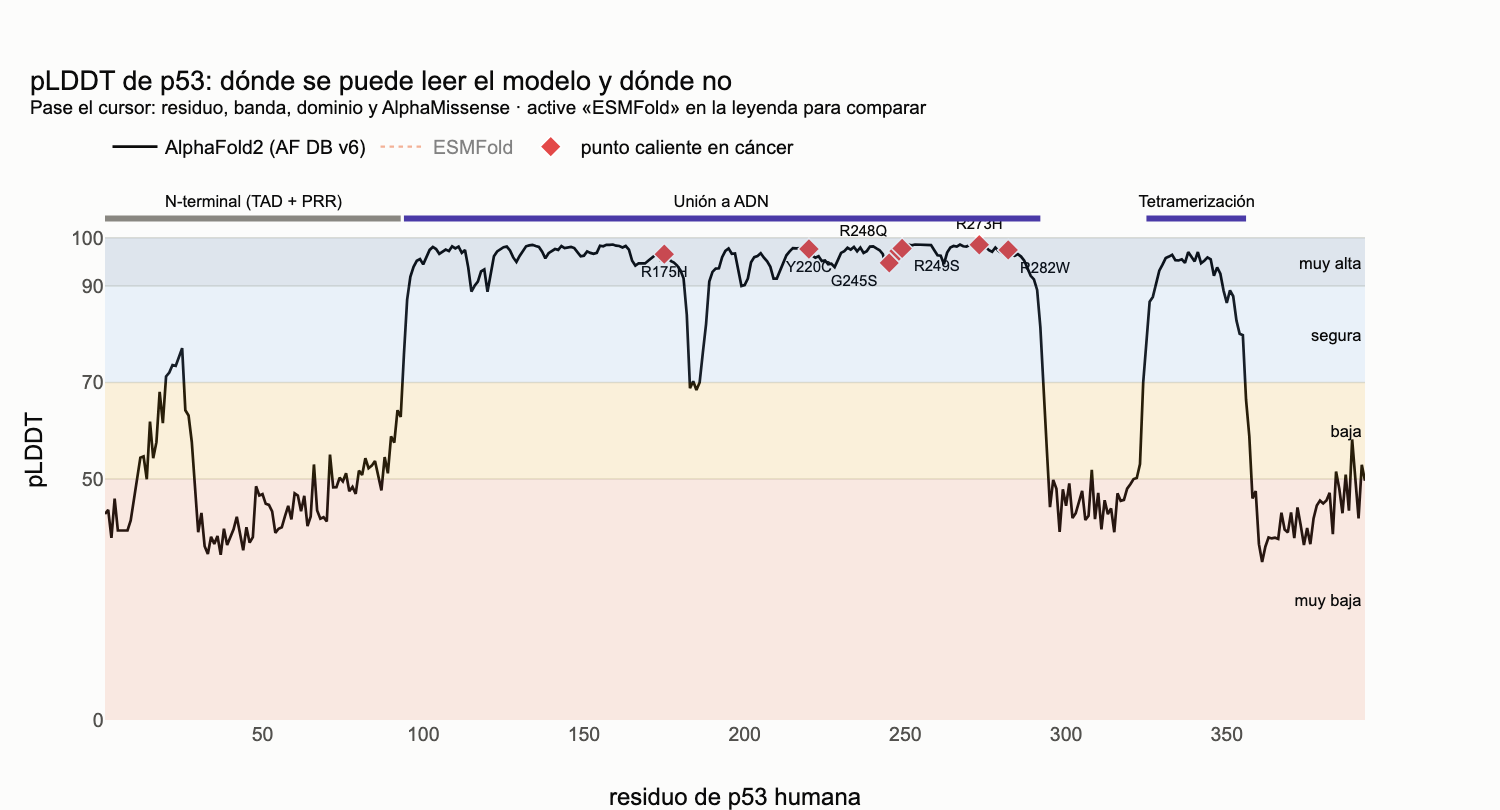

In [27]:
# 📊 Interactivo: pista de pLDDT con dominios, bandas, ESMFold, AlphaMissense y puntos calientes
am["pos"] = am.protein_variant.str[1:-1].astype(int)
am_pos = am.groupby("pos").am_pathogenicity.mean().reindex(res).values
HOTSPOTS = ["R175H", "Y220C", "G245S", "R248Q", "R249S", "R273H", "R282W"]
hot_pos = [int(h[1:-1]) for h in HOTSPOTS]
hover = [f"<b>{P53_SEQ[r - 1]}{r}</b> · dominio: {domain_of(r)}<br>pLDDT AlphaFold: {p:.1f} ({band_of(p)})"
         f"<br>pLDDT ESMFold: {pe:.1f}<br>AlphaMissense medio (19 cambios): {m:.2f}"
         for r, p, pe, m in zip(res, plddt, plddt_esm, am_pos)]
figi = go.Figure()
for lo, hi, name in BANDS:
    figi.add_hrect(y0=lo, y1=min(hi, 100), fillcolor=BAND_COLOR[name], opacity=0.13, line_width=0,
                   annotation_text=name, annotation_position="right", annotation_font_size=11)
for a, b, name, short in DOMAINS:
    if short in ("DBD", "TET", "TAD+PRR"):
        figi.add_shape(type="line", x0=a, x1=b, y0=104, y1=104, line=dict(color=ec.VIOLET if short != "TAD+PRR" else ec.MUTED, width=4))
        figi.add_annotation(x=(a + b) / 2, y=104, text=name, showarrow=False, yshift=12, font=dict(size=11))
figi.add_trace(go.Scatter(x=res, y=plddt, mode="lines", line=dict(color=ec.INK, width=1.8), name="AlphaFold2 (AF DB v6)",
                          text=hover, hovertemplate="%{text}<extra></extra>"))
figi.add_trace(go.Scatter(x=res, y=plddt_esm, mode="lines", line=dict(color=ec.ORANGE, width=1.4, dash="dot"),
                          name="ESMFold", visible="legendonly", hoverinfo="skip"))
figi.add_trace(go.Scatter(x=hot_pos, y=[plddt[p - 1] for p in hot_pos], mode="markers+text",
                          text=HOTSPOTS, textfont=dict(size=10),
                          textposition=["bottom center", "bottom center", "bottom left", "top left", "bottom right",
                                        "top center", "bottom right"],
                          marker=dict(symbol="diamond", size=11, color=ec.RED, line=dict(color="white", width=1)),
                          name="punto caliente en cáncer",
                          customdata=[[plddt[p - 1], am.set_index("protein_variant").am_pathogenicity[h]] for p, h in zip(hot_pos, HOTSPOTS)],
                          hovertemplate="<b>%{text}</b><br>pLDDT %{customdata[0]:.1f}: la estructura local es fiable"
                                        "<br>AlphaMissense de esta sustitución: %{customdata[1]:.3f}<extra></extra>"))
figi.update_layout(width=1000, height=540, margin=dict(l=70, r=90, t=120, b=60), hovermode="closest",
                   title="pLDDT de p53: dónde se puede leer el modelo y dónde no<br><sup>Pase el cursor: residuo, banda, "
                         "dominio y AlphaMissense · active «ESMFold» en la leyenda para comparar</sup>",
                   legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0),
                   xaxis=dict(title="residuo de p53 humana", range=[1, 393]),
                   yaxis=dict(title="pLDDT", range=[0, 112], tickvals=[0, 50, 70, 90, 100]))
figi.show()

> 🔎 **Qué observamos.** Los puntos calientes de cáncer caen todos en el dominio de unión a ADN, en la banda muy alta: allí
> el modelo es fiable para razonar sobre la estructura. La patogenicidad media de AlphaMissense sigue de cerca al pLDDT:
> alta en los dominios plegados, baja en las regiones desordenadas, donde muchos cambios se toleran.

### 8.3 El PAE: ¿están bien colocados los dominios entre sí?

El pLDDT no dice nada sobre la **posición relativa** de los dominios. Para eso AlphaFold2 ofrece el **error alineado
predicho** (PAE). El elemento $\mathrm{PAE}_{ij}$ es el error esperado, en Å, en la posición del residuo $j$ **si se
superponen la predicción y la estructura real sobre el marco local del residuo $i$**.

Piense en un plano de una ciudad dibujado de memoria. Si se pone de pie en la catedral ($i$) y mira hacia la plaza de al
lado ($j$), el plano acierta. Si desde la catedral busca un barrio del otro lado del río, cada barrio puede estar bien
dibujado por dentro, pero mal colocado respecto al otro. Una matriz de PAE con **bloques de valores bajos en la
diagonal** indica dominios bien definidos; valores altos **fuera** de los bloques indican que la posición relativa de esos
dominios es incierta.

| Símbolo | Significado |
|---|---|
| $\mathrm{PAE}_{ij}$ | Error esperado (Å) en la posición de $j$ tras superponer sobre el marco del residuo $i$ |
| fila $i$ | Residuo de referencia (sobre el que se superpone) |
| columna $j$ | Residuo cuya posición se evalúa |

Note que la matriz **no es simétrica**: superponer sobre $i$ y mirar $j$ no es lo mismo que superponer sobre $j$ y mirar $i$.

asimetría media |PAE_ij − PAE_ji| = 2.75 Å
                                      DBD   TET  TAD+PRR
superpongo sobre (i) ↓ / miro (j) →                     
DBD                                   3.6  20.1     26.7
TET                                  20.9   2.9     28.3
TAD+PRR                              30.0  29.9     22.5


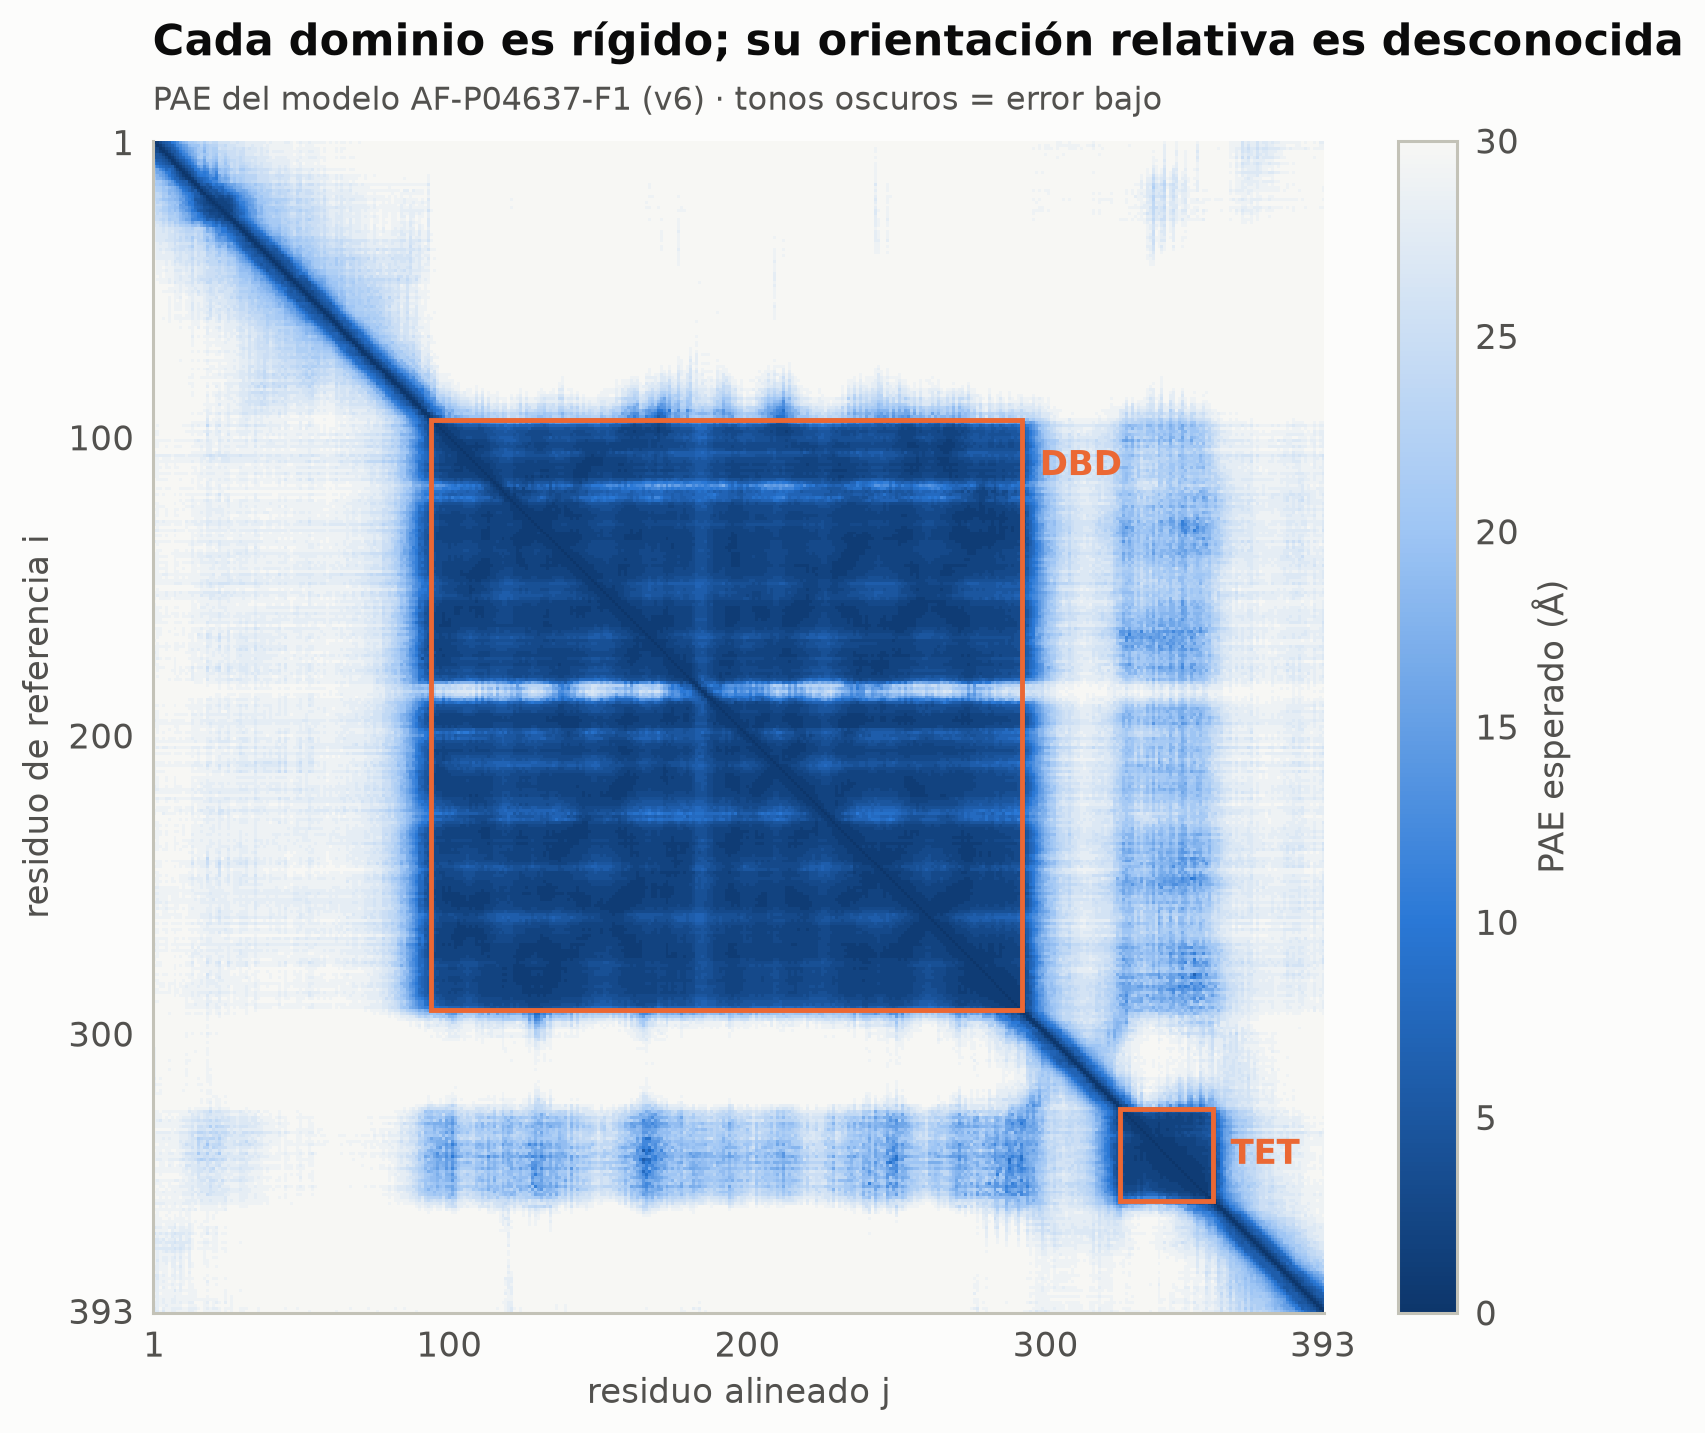

In [28]:
# Matriz de PAE (reproduce la figura del libro: oscuro = error bajo = confianza)
from matplotlib.colors import LinearSegmentedColormap
cmap_pae = LinearSegmentedColormap.from_list("pae", ["#0d366b", "#2a78d6", "#9ec5f4", "#f7f7f4"])
print(f"asimetría media |PAE_ij − PAE_ji| = {np.abs(PAE - PAE.T).mean():.2f} Å")
blocks = {"DBD": slice(93, 292), "TET": slice(324, 356), "TAD+PRR": slice(0, 93)}
tab = pd.DataFrame({a: {b: PAE[blocks[a], blocks[b]].mean() for b in blocks} for a in blocks}).T
tab.index.name = "superpongo sobre (i) ↓ / miro (j) →"
print(tab.round(1))

fig, ax = plt.subplots(figsize=(7.6, 6.4))
im = ax.imshow(PAE, cmap=cmap_pae, vmin=0, vmax=30, origin="upper", interpolation="nearest",
               extent=(0.5, 393.5, 393.5, 0.5))
for a, b, name in [(94, 292, "DBD"), (325, 356, "TET")]:
    ax.add_patch(Rectangle((a, a), b - a, b - a, fill=False, ec=ec.ORANGE, lw=1.6))
    ax.text(b + 6, a + 10, name, color=ec.ORANGE, fontsize=11, fontweight="bold", va="top")
ax.set_xlabel("residuo alineado j"); ax.set_ylabel("residuo de referencia i"); ax.grid(False)
ax.set_xticks([1, 100, 200, 300, 393]); ax.set_yticks([1, 100, 200, 300, 393])
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03, label="PAE esperado (Å)")
ec.title(ax, "Cada dominio es rígido; su orientación relativa es desconocida",
         "PAE del modelo AF-P04637-F1 (v6) · tonos oscuros = error bajo")
plt.show()

> 🔎 **Qué observamos.** Dos bloques oscuros en la diagonal: el DBD (PAE medio 3,6 Å) y el dominio de tetramerización
> (2,9 Å). Fuera de ellos, todo es claro: desde el marco del DBD, la posición del dominio de tetramerización tiene un error
> esperado de **20,1 Å**. Atención a la escala de color: aquí, a diferencia del resto del curso, el **oscuro es lo bueno**
> (error bajo), por coherencia con la figura del libro y con AlphaFold DB.

En la versión interactiva, pase el cursor por cualquier celda para leer la pregunta que responde.

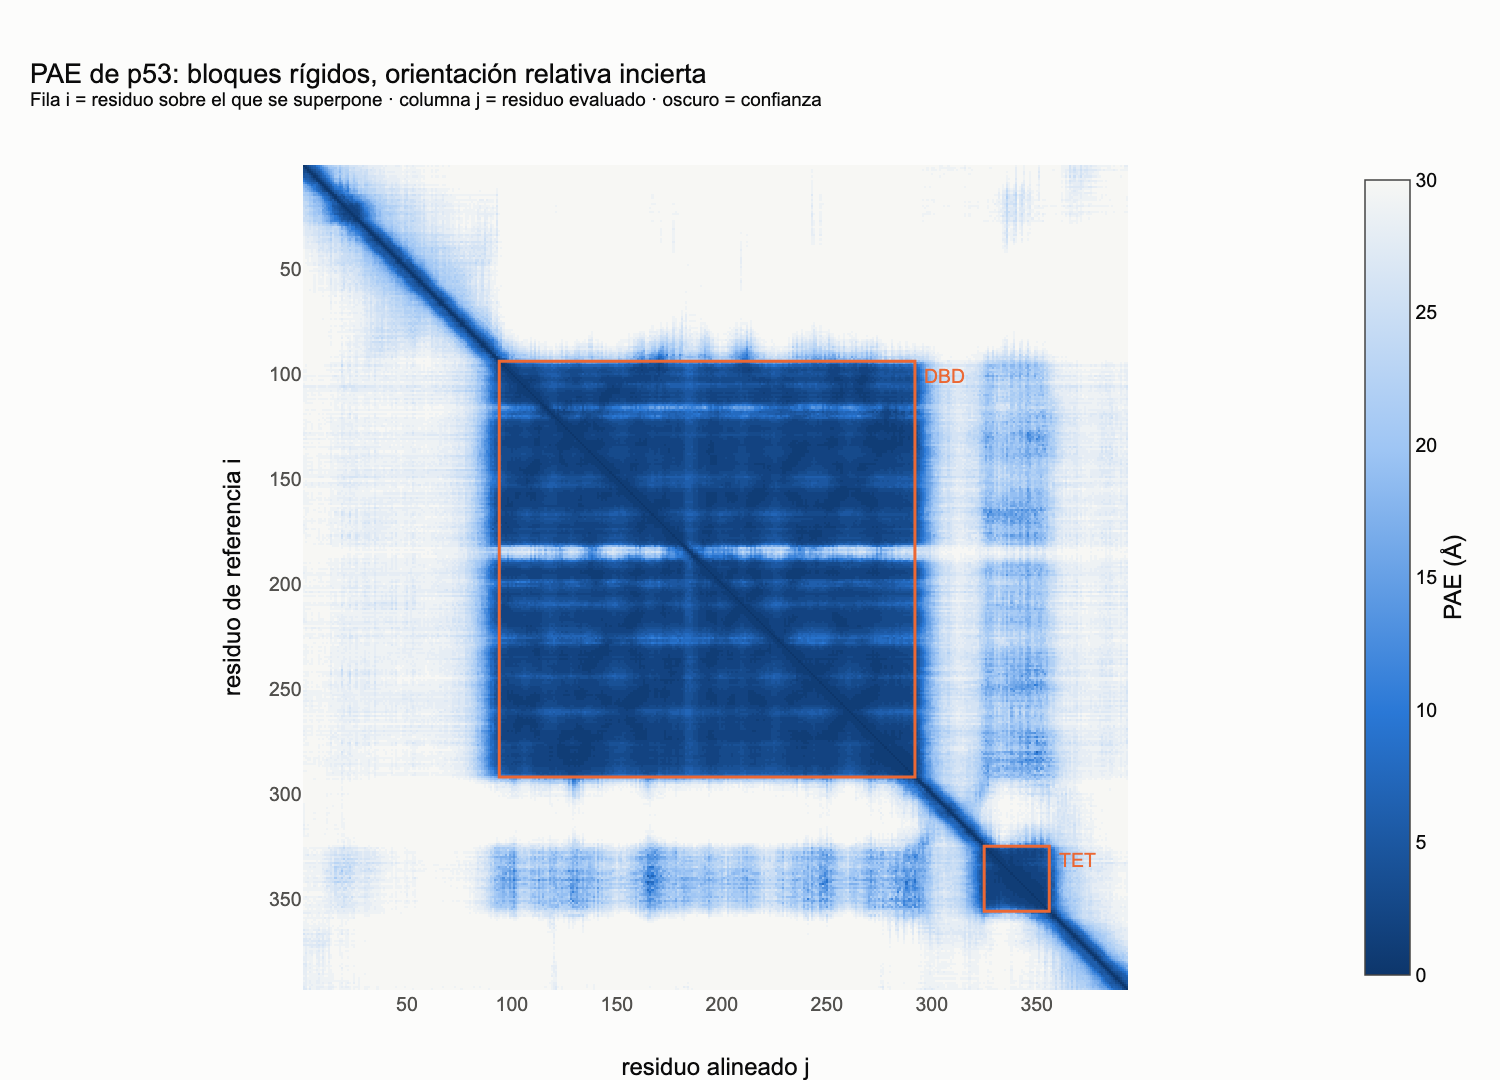

In [29]:
# 📊 Interactivo: matriz de PAE con lectura de cada celda
figpae = go.Figure(go.Heatmap(
    z=PAE, x=res, y=res, zmin=0, zmax=30,
    colorscale=[[0, "#0d366b"], [0.33, "#2a78d6"], [0.66, "#9ec5f4"], [1, "#f7f7f4"]],
    colorbar=dict(title=dict(text="PAE (Å)", side="right")),
    hovertemplate="Superpongo sobre el residuo <b>i = %{y}</b><br>"
                  "¿dónde está <b>j = %{x}</b>? error esperado: <b>%{z} Å</b><br>"
                  "(DBD 94–292 · TET 325–356)<extra></extra>"))
for a, b, name in [(94, 292, "DBD"), (325, 356, "TET")]:
    figpae.add_shape(type="rect", x0=a, x1=b, y0=a, y1=b, line=dict(color=ec.ORANGE, width=2))
    figpae.add_annotation(x=b, y=a, text=name, showarrow=False, xanchor="left", yanchor="top", xshift=4,
                          font=dict(color=ec.ORANGE, size=13))
figpae.update_layout(width=760, height=720, margin=dict(l=70, r=30, t=110, b=60),
                     title="PAE de p53: bloques rígidos, orientación relativa incierta<br><sup>Fila i = residuo sobre el que "
                           "se superpone · columna j = residuo evaluado · oscuro = confianza</sup>",
                     xaxis=dict(title="residuo alineado j", constrain="domain"),
                     yaxis=dict(title="residuo de referencia i", autorange="reversed", scaleanchor="x"))
figpae.show()

La animación siguiente recorre las filas de la matriz: en cada cuadro «nos paramos» sobre un residuo $i$ y vemos el
error esperado para toda la proteína desde allí.

🤔 **Antes de ejecutar, prediga:** cuando $i$ esté dentro del DBD, ¿qué forma tendrá la curva de error sobre los
residuos del propio DBD? ¿Y cuando $i$ esté en la región desordenada N-terminal?

![Recorremos la matriz de PAE fila a fila: parados dentro de un dominio, el error es bajo en ese mismo dominio y alto en el resto; parados en una región desordenada, todo es incierto](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-15-estructural/15.2_pae_filas.gif)

*Recorremos la matriz de PAE fila a fila: parados dentro de un dominio, el error es bajo en ese mismo dominio y alto en el resto; parados en una región desordenada, todo es incierto*

In [30]:
# Animación: una fila de la matriz de PAE a la vez
rows_anim = np.unique(np.r_[np.linspace(1, 393, 30).astype(int), [175, 248, 273, 340]])
fig = plt.figure(figsize=(12.5, 5.2))
axI = fig.add_axes([0.04, 0.12, 0.34, 0.72]); axR = fig.add_axes([0.46, 0.14, 0.51, 0.66])
def update(f):
    axI.clear(); axR.clear()
    i = rows_anim[f]
    axI.imshow(PAE, cmap=cmap_pae, vmin=0, vmax=30, extent=(0.5, 393.5, 393.5, 0.5), interpolation="nearest")
    axI.axhline(i, color=ec.ORANGE, lw=2); axI.grid(False)
    axI.set_xticks([1, 200, 393]); axI.set_yticks([1, 200, 393])
    axI.set_xlabel("j"); axI.set_ylabel("i")
    for a, b, name, short in DOMAINS:
        if short in ("DBD", "TET"):
            axR.axvspan(a, b, color=ec.VIOLET, alpha=0.08, lw=0)
            axR.text((a + b) / 2, 31, short, ha="center", fontsize=10, color=ec.VIOLET)
    axR.plot(res, PAE[i - 1], color=ec.BLUE, lw=1.8)
    axR.axvline(i, color=ec.ORANGE, lw=1.5)
    axR.set_xlim(1, 393); axR.set_ylim(0, 33)
    axR.set_xlabel("residuo evaluado j"); axR.set_ylabel(f"PAE(i = {i}, j) en Å")
    axR.set_title(f"Parados en el residuo {P53_SEQ[i - 1]}{i} ({domain_of(i)}, pLDDT {plddt[i - 1]:.0f})",
                  loc="left", fontsize=12)
    fig.suptitle("¿Qué tan bien conozco cada residuo si me paro en i?", x=0.04, ha="left", fontsize=13, fontweight="bold")
    return []
ec.animate(fig, update, frames=len(rows_anim), interval=350, name="15.2_pae_filas")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** Parados en el DBD, la curva forma un «valle» profundo (≈ 1–6 Å) exactamente sobre los residuos
> del DBD y sube a más de 20 Å en el resto. Parados en el dominio de tetramerización, el valle se desplaza a 325–356.
> Parados en una región desordenada, la curva es alta en casi todas partes: ni siquiera los vecinos cercanos están bien
> colocados.

> ✅ **Compruebe su comprensión.** Un estudiante mide en el modelo la distancia entre Arg248 (DBD) y Leu344 (TET) y
> concluye que «están a 45 Å». ¿Qué le diría? *Que el PAE entre ambos dominios ronda los 20 Å: la orientación relativa en
> el modelo es arbitraria y esa distancia no tiene significado. Dentro de cada dominio, en cambio, las distancias son
> fiables.*

---

## 9. Ejemplo resuelto: leer el modelo de p53 y compararlo con el cristal

> 📘 **Ejemplo del libro — «Leer un modelo de AlphaFold DB: p53».** La p53 humana (393 residuos) mezcla dominios compactos
> con largas regiones desordenadas. En su modelo de AlphaFold DB, el 52,7 % de los residuos tiene pLDDT muy alto, el 7,1 %
> seguro, el 10,4 % bajo y el 29,8 % muy bajo. Dentro del dominio de unión a ADN el PAE medio es de 3,6 Å, y dentro del de
> tetramerización, de 2,9 Å; pero el PAE medio de las posiciones del dominio de tetramerización vistas desde el marco del
> dominio de unión a ADN es de 20,1 Å. Traducción: cada dominio está bien predicho, pero su orientación relativa en el
> modelo es arbitraria. ¿Es fiable el dominio de alta confianza? Comparando sus C$_\alpha$ (residuos 94–292) con el
> cristal `2OCJ`, 194 pares tienen un RMSD de 0,51 Å y un TM-score de 0,99.

Las fracciones y los PAE ya los verificamos en la sección 3. El libro muestra este código para leer el pLDDT directamente
de la columna del factor $B$ del archivo PDB:

```python
import requests

acc = "P04637"                                   # p53 humana
api = f"https://alphafold.ebi.ac.uk/api/prediction/{acc}"
meta = requests.get(api, timeout=30).json()[0]
pdb = requests.get(meta["pdbUrl"], timeout=60).text
plddt = {}
for linea in pdb.splitlines():                   # pLDDT = columna B
    if linea.startswith("ATOM") and linea[12:16] == " CA ":
        plddt[int(linea[22:26])] = float(linea[60:66])
bajos = [r for r, v in plddt.items() if v < 50]
print(f"{len(plddt)} residuos; {len(bajos)} con pLDDT < 50")
```

Lo aplicamos a nuestra copia del modelo (la misma lógica, sin depender de la red), y luego hacemos la comparación con el
cristal con todas las medidas que conocemos: RMSD tras Kabsch, TM-score, GDT_TS y lDDT.

In [31]:
pdb_text = course_text("152_AF-P04637-F1-model_v6.pdb.gz")
plddt_b = {}
for linea in pdb_text.splitlines():                     # pLDDT = columna B
    if linea.startswith("ATOM") and linea[12:16] == " CA ":
        plddt_b[int(linea[22:26])] = float(linea[60:66])
bajos = [r for r, v in plddt_b.items() if v < 50]
print(f"{len(plddt_b)} residuos; {len(bajos)} con pLDDT < 50")

# Modelo (AlphaFold y ESMFold) frente al cristal 2OCJ en el dominio de unión a ADN
com = [k for k in sorted(xtal) if 94 <= k <= 292 and k in af]
Q = np.array([xtal[k][0] for k in com])
rows = []
per_res = {}
for name, model in [("AlphaFold2", af), ("ESMFold", esm)]:
    P = np.array([model[k][0] for k in com])
    R, t = kabsch(P, Q)
    dev = np.linalg.norm(P @ R.T + t - Q, axis=1)
    g, pc = gdt_ts(P, Q)
    ld = lddt(P, Q)
    per_res[name] = (dev, ld)
    rows.append({"modelo": name, "pares Cα": len(com), "RMSD (Å)": round(rmsd(P @ R.T + t, Q), 2),
                 "TM-score": round(tmscore(P, Q, len(com)), 3), "GDT_TS": round(g, 1),
                 "lDDT ×100": round(100 * ld.mean(), 1),
                 "pLDDT medio": round(np.mean([model[k][1] * (100 if name == "ESMFold" else 1) for k in com]), 1)})
cmp_df = pd.DataFrame(rows).set_index("modelo")
print(cmp_df.to_string())
full_af = np.array([af[r][0] for r in res]); full_esm = np.array([esm[r][0] for r in res])
print(f"\nAlphaFold frente a ESMFold, cadena completa: RMSD = {sup_rmsd(full_af, full_esm):.1f} Å · "
      f"sólo DBD: {sup_rmsd(full_af[93:292], full_esm[93:292]):.2f} Å · sólo TET: {sup_rmsd(full_af[324:356], full_esm[324:356]):.2f} Å")

393 residuos; 117 con pLDDT < 50
            pares Cα  RMSD (Å)  TM-score  GDT_TS  lDDT ×100  pLDDT medio
modelo                                                                  
AlphaFold2       194      0.51     0.991    98.8       97.6         95.6
ESMFold          194      1.16     0.968    95.4       91.4         92.2

AlphaFold frente a ESMFold, cadena completa: RMSD = 21.0 Å · sólo DBD: 1.57 Å · sólo TET: 0.65 Å


> 🔎 **Qué observamos.** El modelo de AlphaFold reproduce el cristal con **194 pares, RMSD 0,51 Å y TM-score 0,99**, las
> cifras del libro, con un GDT_TS muy por encima de 90 (el umbral de «competitivo con lo experimental»). ESMFold, que no
> usa MSA, también acierta el plegamiento, con un error algo mayor. Y un aviso práctico: el RMSD de la **cadena completa**
> entre los dos modelos es de unos 20 Å, aunque cada dominio coincide al angstrom: comparar proteínas multidominio con un
> único RMSD global mezcla la orientación arbitraria de los dominios con la calidad de cada uno.

Una advertencia honesta, que el libro también hace: `2OCJ` se depositó en 2007 y pudo formar parte del conjunto de
entrenamiento de AlphaFold2. La evaluación justa de un predictor exige estructuras publicadas **después** de su
entrenamiento, que es exactamente lo que garantiza CASP.

¿Predice bien el pLDDT el lDDT real? Veámoslo residuo a residuo.

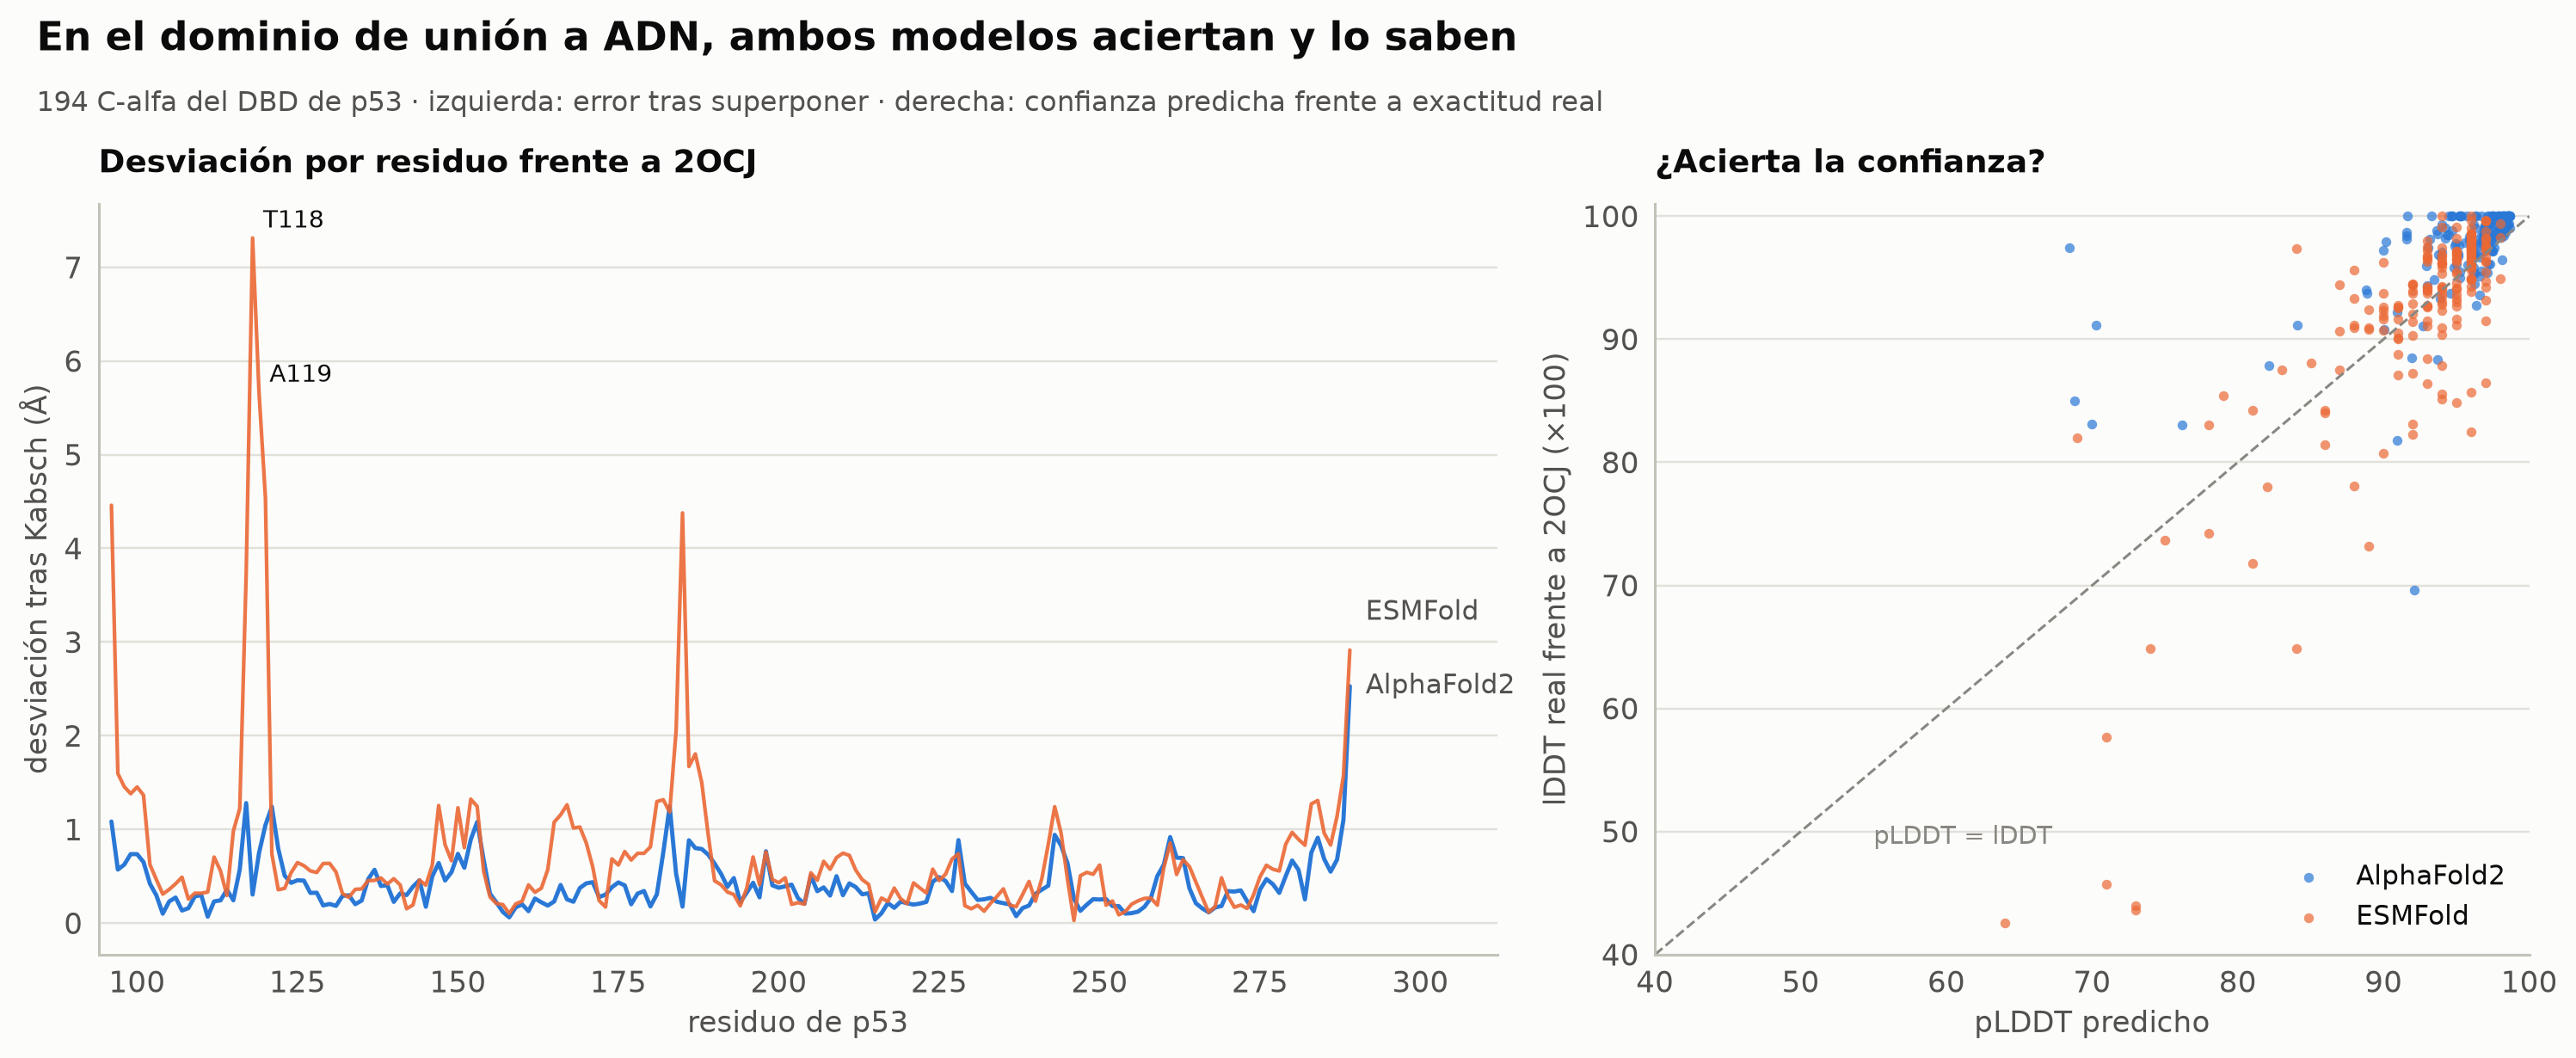

correlación pLDDT–lDDT: AlphaFold2 r = 0.60 · ESMFold r = 0.85


In [32]:
dev_af, ld_af = per_res["AlphaFold2"]; dev_esm, ld_esm = per_res["ESMFold"]
pl_com = np.array([af[k][1] for k in com]); ple_com = np.array([esm[k][1] * 100 for k in com])
fig, axs = plt.subplots(1, 2, figsize=(13.5, 4.8), gridspec_kw=dict(width_ratios=[1.6, 1]))
ax = axs[0]
ax.plot(com, dev_af, color=ec.BLUE, lw=1.6); ax.plot(com, dev_esm, color=ec.ORANGE, lw=1.4, alpha=0.9)
ec.label_end(ax, com[-1], dev_af[-1], "AlphaFold2"); ec.label_end(ax, com[-1], dev_esm[-1] + 0.4, "ESMFold")
ax.set_xlim(94, 312); ax.set_xlabel("residuo de p53"); ax.set_ylabel("desviación tras Kabsch (Å)")
top = np.argsort(-dev_esm)[:2]
for k in top:
    ax.annotate(f"{P53_SEQ[com[k] - 1]}{com[k]}", (com[k], dev_esm[k]), xytext=(4, 4), textcoords="offset points", fontsize=9)
ax.set_title("Desviación por residuo frente a 2OCJ", loc="left", fontsize=12)
ax = axs[1]
ax.scatter(pl_com, 100 * ld_af, s=14, color=ec.BLUE, alpha=0.7, lw=0, label="AlphaFold2")
ax.scatter(ple_com, 100 * ld_esm, s=14, color=ec.ORANGE, alpha=0.7, lw=0, label="ESMFold")
ax.plot([40, 100], [40, 100], color=ec.MUTED, lw=1, ls="--"); ax.text(55, 49, "pLDDT = lDDT", color=ec.MUTED, fontsize=9.5)
ax.set_xlim(40, 100); ax.set_ylim(40, 101)
ax.set_xlabel("pLDDT predicho"); ax.set_ylabel("lDDT real frente a 2OCJ (×100)")
ax.legend(loc="lower right"); ax.set_title("¿Acierta la confianza?", loc="left", fontsize=12)
ec.fig_title(fig, "En el dominio de unión a ADN, ambos modelos aciertan y lo saben",
             "194 C-alfa del DBD de p53 · izquierda: error tras superponer · derecha: confianza predicha frente a exactitud real")
plt.show()
print(f"correlación pLDDT–lDDT: AlphaFold2 r = {np.corrcoef(pl_com, ld_af)[0, 1]:.2f} · ESMFold r = {np.corrcoef(ple_com, ld_esm)[0, 1]:.2f}")

> 🔎 **Qué observamos.** Casi todo el DBD está por debajo de 1 Å de desviación con AlphaFold; los picos coinciden con
> lazos expuestos y con los extremos. A la derecha, los puntos se concentran arriba a la derecha: cuando la red dice
> «confío» (pLDDT > 90), el lDDT real también es alto. Dentro de un dominio tan bien predicho, la correlación entre ambos
> es moderada porque casi no hay variación que explicar; la utilidad del pLDDT aparece al comparar regiones **distintas**.

---

## 10. 🧬 Caso real: mutaciones de cáncer en p53 a la luz de la confianza

Volvamos al oncólogo del principio. El informe de secuenciación de un tumor de colon muestra la variante somática
*TP53* c.743G>A, que en la proteína es **p.Arg248Gln (R248Q)**; en otra paciente aparece **p.Pro72Arg (P72R)**. ¿Qué
puede decirnos la estructura de cada una?

La gran mayoría de las mutaciones de p53 en cáncer caen en el dominio de unión a ADN, y un puñado de «puntos calientes»
concentra una fracción enorme de todos los casos. Cho y colaboradores (1994) explicaron por qué con el cristal de p53 unida
a ADN (`1TSR`): algunos puntos calientes son residuos que **tocan el ADN** (mutantes de contacto) y otros sostienen el
andamio del dominio o el sitio de zinc (mutantes estructurales).

Combinaremos cuatro fuentes: el pLDDT del modelo (¿podemos confiar en la estructura local?), la distancia al ADN y al zinc
en `1TSR` (cadena B, la copia unida específicamente al ADN), y la puntuación de AlphaMissense para la sustitución concreta.

In [33]:
# Distancia mínima (átomos pesados) de cada residuo al ADN y al zinc en 1TSR, cadena B
tsr = x1tsr_df
dna_xyz = tsr[tsr.chain.isin(["E", "F"]) & (tsr.record == "ATOM")][["x", "y", "z"]].values
zn_xyz = tsr[(tsr.resname == "ZN") & (tsr.chain == "B")][["x", "y", "z"]].values
protB = tsr[(tsr.chain == "B") & (tsr.record == "ATOM") & (tsr.element != "H")]
dist_dna, dist_zn = {}, {}
for r_, g in protB.groupby("resnum"):
    xyz = g[["x", "y", "z"]].values
    dist_dna[r_] = np.linalg.norm(xyz[:, None] - dna_xyz[None], axis=2).min()
    dist_zn[r_] = np.linalg.norm(xyz[:, None] - zn_xyz[None], axis=2).min()
am_idx = am.set_index("protein_variant")
rows = []
for v in HOTSPOTS + ["P72R"]:
    p = int(v[1:-1])
    dD, dZ = dist_dna.get(p, np.nan), dist_zn.get(p, np.nan)
    kind = ("fuera del modelo fiable" if plddt[p - 1] < 70 else
            "contacto con el ADN" if dD < 4 else "estructural (sitio de zinc)" if dZ < 7 else "estructural (andamio)")
    rows.append({"variante": v, "dominio": domain_of(p), "pLDDT": round(plddt[p - 1], 1), "banda": band_of(plddt[p - 1]),
                 "dist. ADN (Å)": round(dD, 1), "dist. Zn (Å)": round(dZ, 1),
                 "AlphaMissense": am_idx.am_pathogenicity[v], "clase AM": am_idx.am_class[v], "lectura estructural": kind})
hot_df = pd.DataFrame(rows).set_index("variante")
hot_df

,dominio,pLDDT,banda,dist. ADN (Å),dist. Zn (Å),AlphaMissense,clase AM,lectura estructural
variante,,,,,,,,
R175H,DBD,96.6,muy alta,13.2,5.2,0.9857,LPath,estructural (sitio de zinc)
Y220C,DBD,97.7,muy alta,29.8,28.6,0.8515,LPath,estructural (andamio)
G245S,DBD,94.8,muy alta,9.7,6.2,0.9732,LPath,estructural (sitio de zinc)
R248Q,DBD,97.2,muy alta,3.4,9.6,0.9963,LPath,contacto con el ADN
R249S,DBD,97.8,muy alta,6.3,11.3,0.9995,LPath,estructural (andamio)
R273H,DBD,98.6,muy alta,2.5,12.1,0.9889,LPath,contacto con el ADN
R282W,DBD,97.5,muy alta,9.8,19.9,0.9462,LPath,estructural (andamio)
P72R,TAD+PRR,48.2,muy baja,NaN,NaN,0.0724,LBen,fuera del modelo fiable


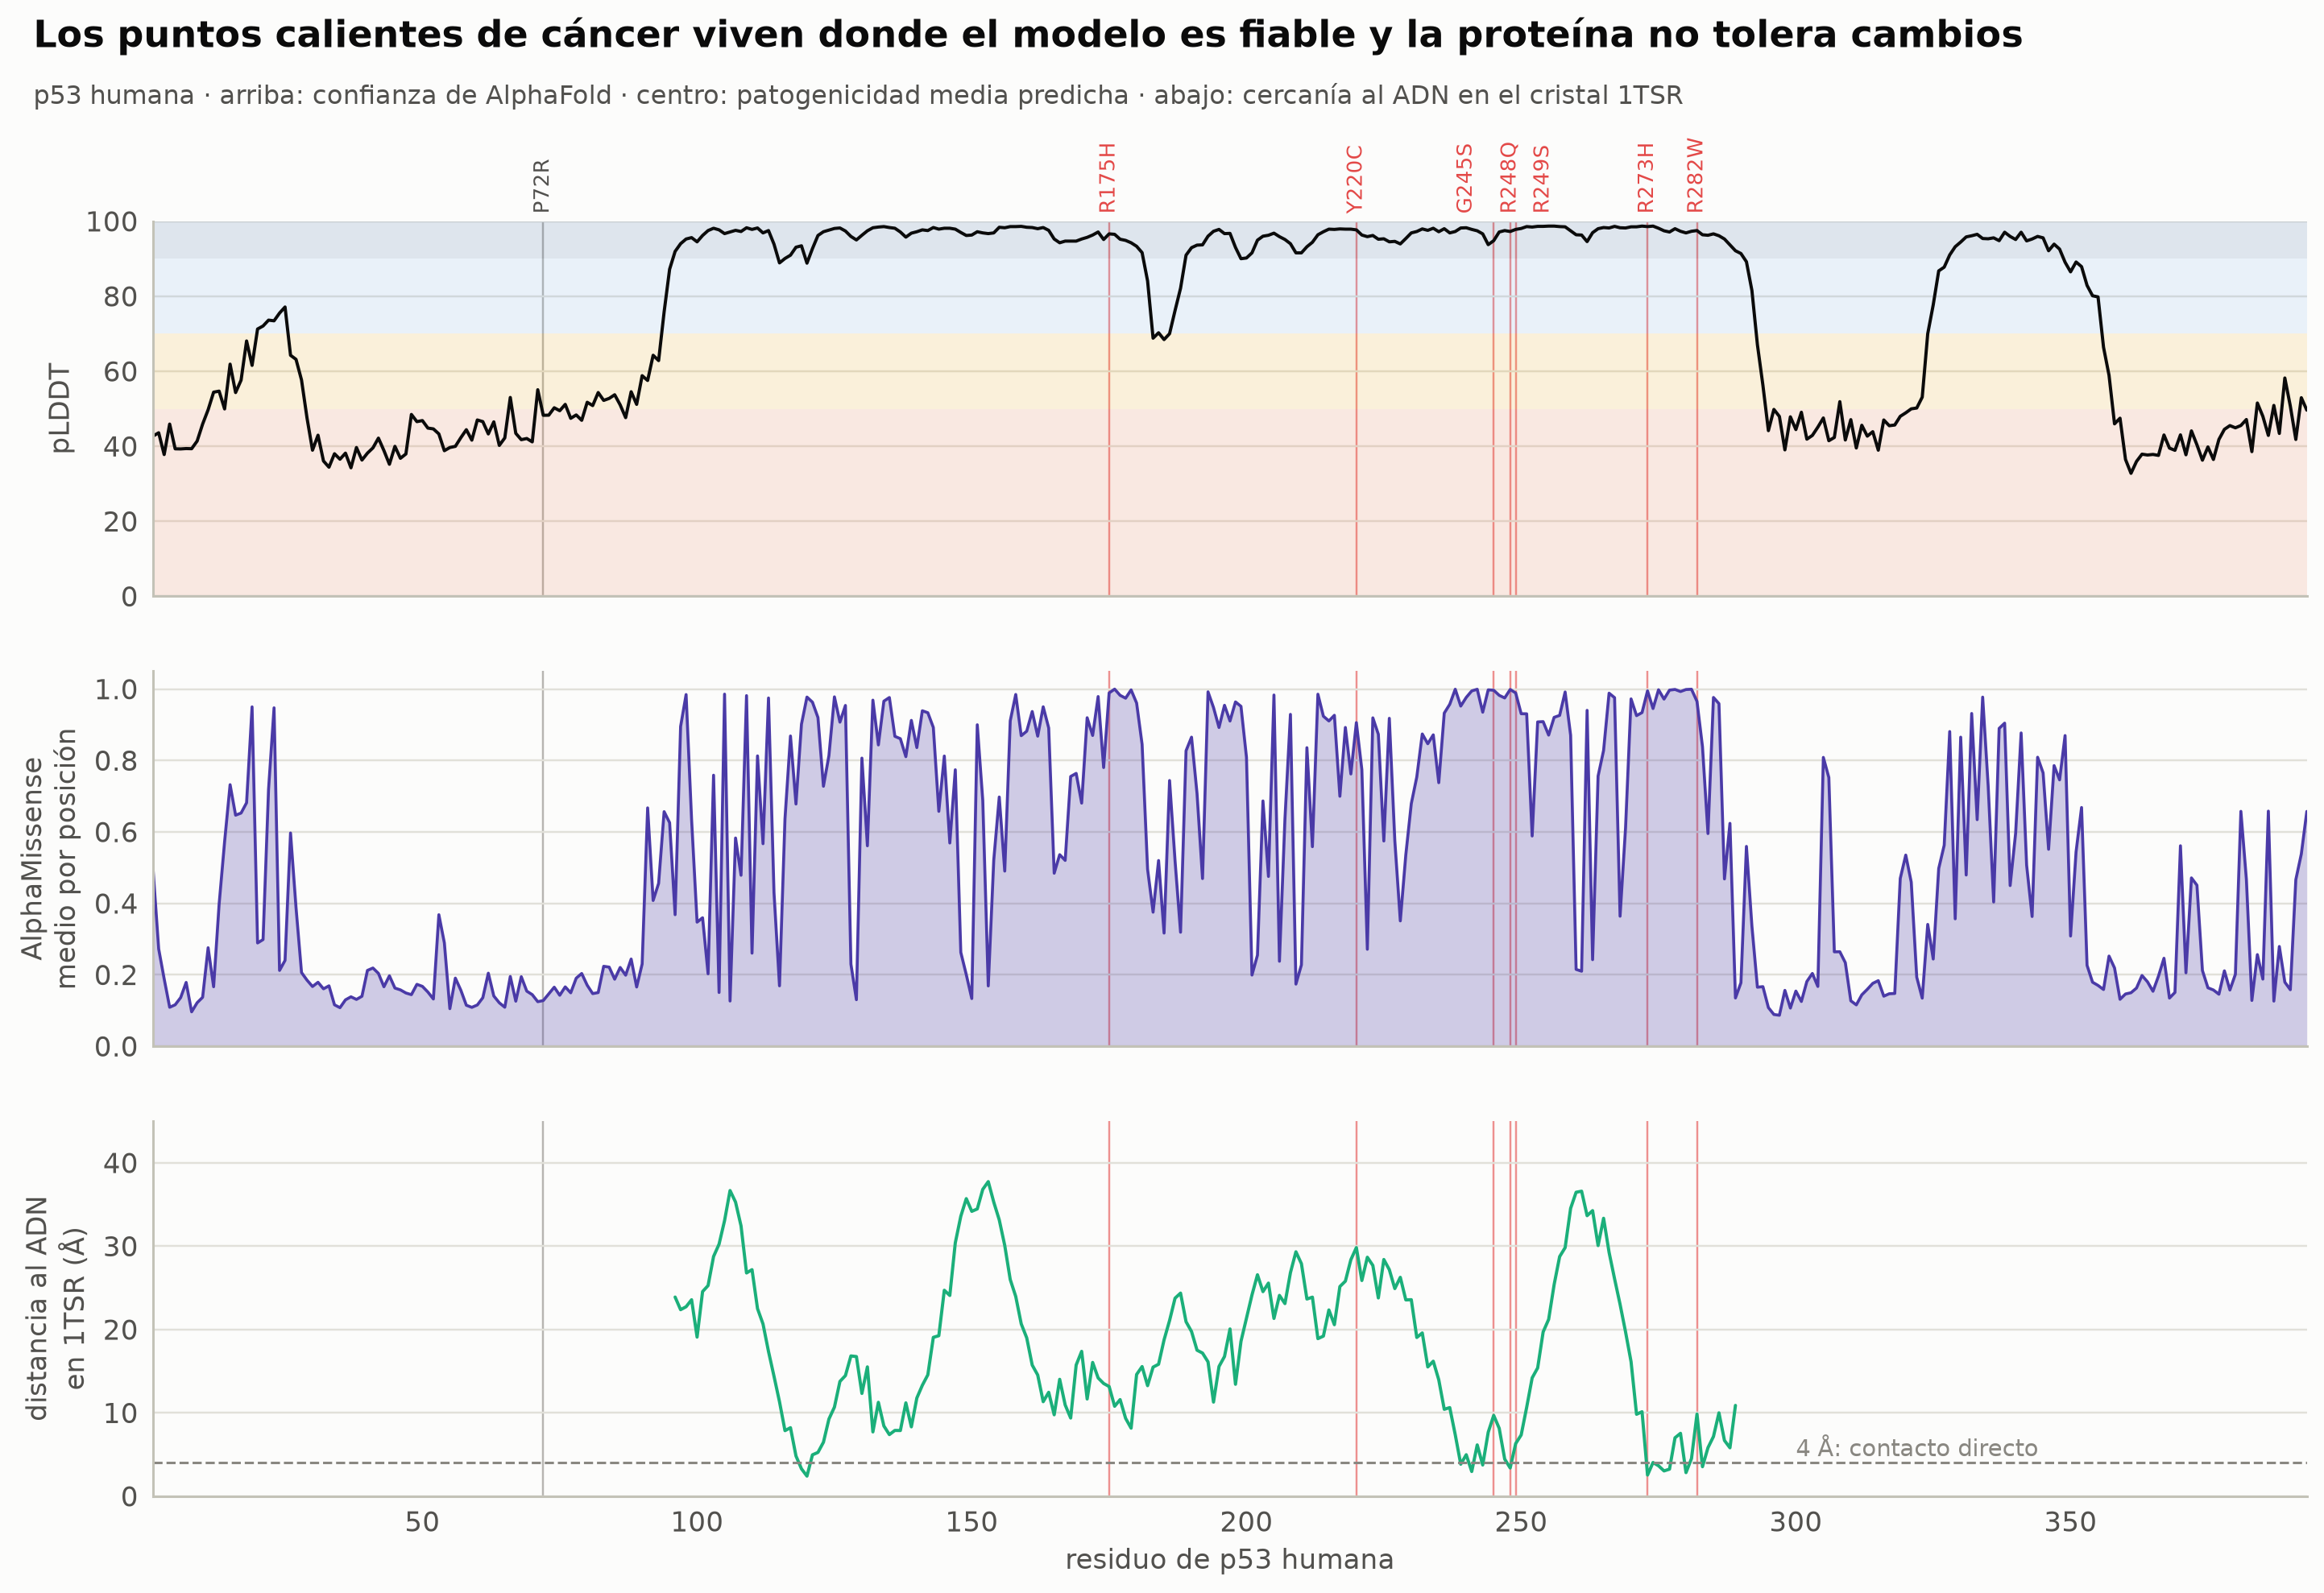

In [34]:
# Tres pistas apiladas sobre el mismo eje de residuos (sin doble eje Y)
dna_track = np.array([dist_dna.get(r_, np.nan) for r_ in res])
fig, axs = plt.subplots(3, 1, figsize=(13, 8.2), sharex=True, gridspec_kw=dict(height_ratios=[1, 1, 1], hspace=0.12))
ax = axs[0]
for lo, hi, name in BANDS:
    ax.axhspan(lo, min(hi, 100), color=BAND_COLOR[name], alpha=0.13, lw=0)
ax.plot(res, plddt, color=ec.INK, lw=1.3); ax.set_ylim(0, 100); ax.set_ylabel("pLDDT")
ax = axs[1]
ax.fill_between(res, am_pos, color=ec.VIOLET, alpha=0.25, lw=0); ax.plot(res, am_pos, color=ec.VIOLET, lw=1.2)
ax.set_ylim(0, 1.05); ax.set_ylabel("AlphaMissense\nmedio por posición")
ax = axs[2]
ax.plot(res, dna_track, color=ec.AQUA, lw=1.3); ax.axhline(4, color=ec.MUTED, ls="--", lw=1)
ax.text(300, 4.8, "4 Å: contacto directo", fontsize=9.5, color=ec.MUTED)
ax.set_ylim(0, 45); ax.set_ylabel("distancia al ADN\nen 1TSR (Å)"); ax.set_xlabel("residuo de p53 humana")
ax.set_xlim(1, 393)
for v in hot_df.index:
    p = int(v[1:-1])
    for k, a_ in enumerate(axs):
        a_.axvline(p, color=ec.RED if v != "P72R" else ec.MUTED, lw=0.8, alpha=0.6, zorder=0)
    axs[0].text(p + {245: -5, 248: 0, 249: 5}.get(p, 0), 102, v, rotation=90, ha="center", va="bottom", fontsize=8.5,
                color=ec.RED if v != "P72R" else ec.INK_2, clip_on=False)
ec.fig_title(fig, "Los puntos calientes de cáncer viven donde el modelo es fiable y la proteína no tolera cambios",
             "p53 humana · arriba: confianza de AlphaFold · centro: patogenicidad media predicha · abajo: cercanía al ADN en el cristal 1TSR")
plt.show()

> 🔎 **Qué observamos.**
> * **R248Q** y **R273H** tocan el ADN directamente (≈ 2,5–3,5 Å) en una región de pLDDT muy alto: la estructura local es
>   de fiar y el mecanismo es claro, la proteína pierde un contacto con el ADN aunque siga plegada. **R175H** y **G245S**
>   están a 5–6 Å del zinc: son mutantes estructurales que desordenan el sitio de zinc y los lazos que sostienen la unión al
>   ADN. **R249S** y **R282W** están cerca del ADN (6–10 Å) pero no lo tocan: sostienen el andamio de esos lazos.
>   **Y220C** queda lejos de todo: desestabiliza el núcleo y crea una bolsa en la superficie, la que aprovechan fármacos
>   experimentales para «reestabilizar» p53. AlphaMissense las califica a todas como probablemente patogénicas.
> * **P72R** cae en la región rica en prolina (PRR, ≈ 64–92), de pLDDT muy bajo. El modelo **no tiene nada que decir** sobre su efecto estructural: la
>   región no tiene estructura fija. Es, de hecho, un polimorfismo común en la población humana, y AlphaMissense lo
>   clasifica como probablemente benigno.
>
> Ésa es la lección práctica: **la confianza del modelo decide qué preguntas se pueden hacer**. En el DBD podemos razonar
> sobre contactos, cavidades y estabilidad; en las regiones desordenadas, el modelo sólo nos dice que no hay una forma
> única que analizar. Ni el pLDDT ni AlphaMissense sustituyen la clasificación clínica ACMG/AMP de la lección 9.3: son
> evidencias de apoyo.

---

## 11. Limitaciones: desorden, complejos y cambios conformacionales

> ⚠️ **Del libro — pLDDT alto no significa estructura correcta en la célula.** El pLDDT mide la confianza de la red en
> **una** conformación, no la verdad biológica. Un modelo puede tener pLDDT alto y representar sólo uno de varios estados
> funcionales (activo o inactivo, con o sin ligando), porque AlphaFold2 tiende a predecir la conformación más representada
> en su entrenamiento. Tampoco modela ligandos, iones, modificaciones postraduccionales ni otras cadenas. Y un pLDDT bajo no
> es un fracaso: a menudo es la mejor predicción posible, la de que la región está desordenada.

Veamos cada limitación con datos reales.

### 11.1 Desorden: dos predictores, dos opiniones sobre las mismas regiones

                  AlphaFold2  ESMFold
TAD+PRR (1–93)          48.4     67.5
DBD (94–292)            95.3     91.7
enlace (293–324)        47.4     62.5
TET (325–356)           90.9     79.4
C-term (357–393)        43.4     66.9


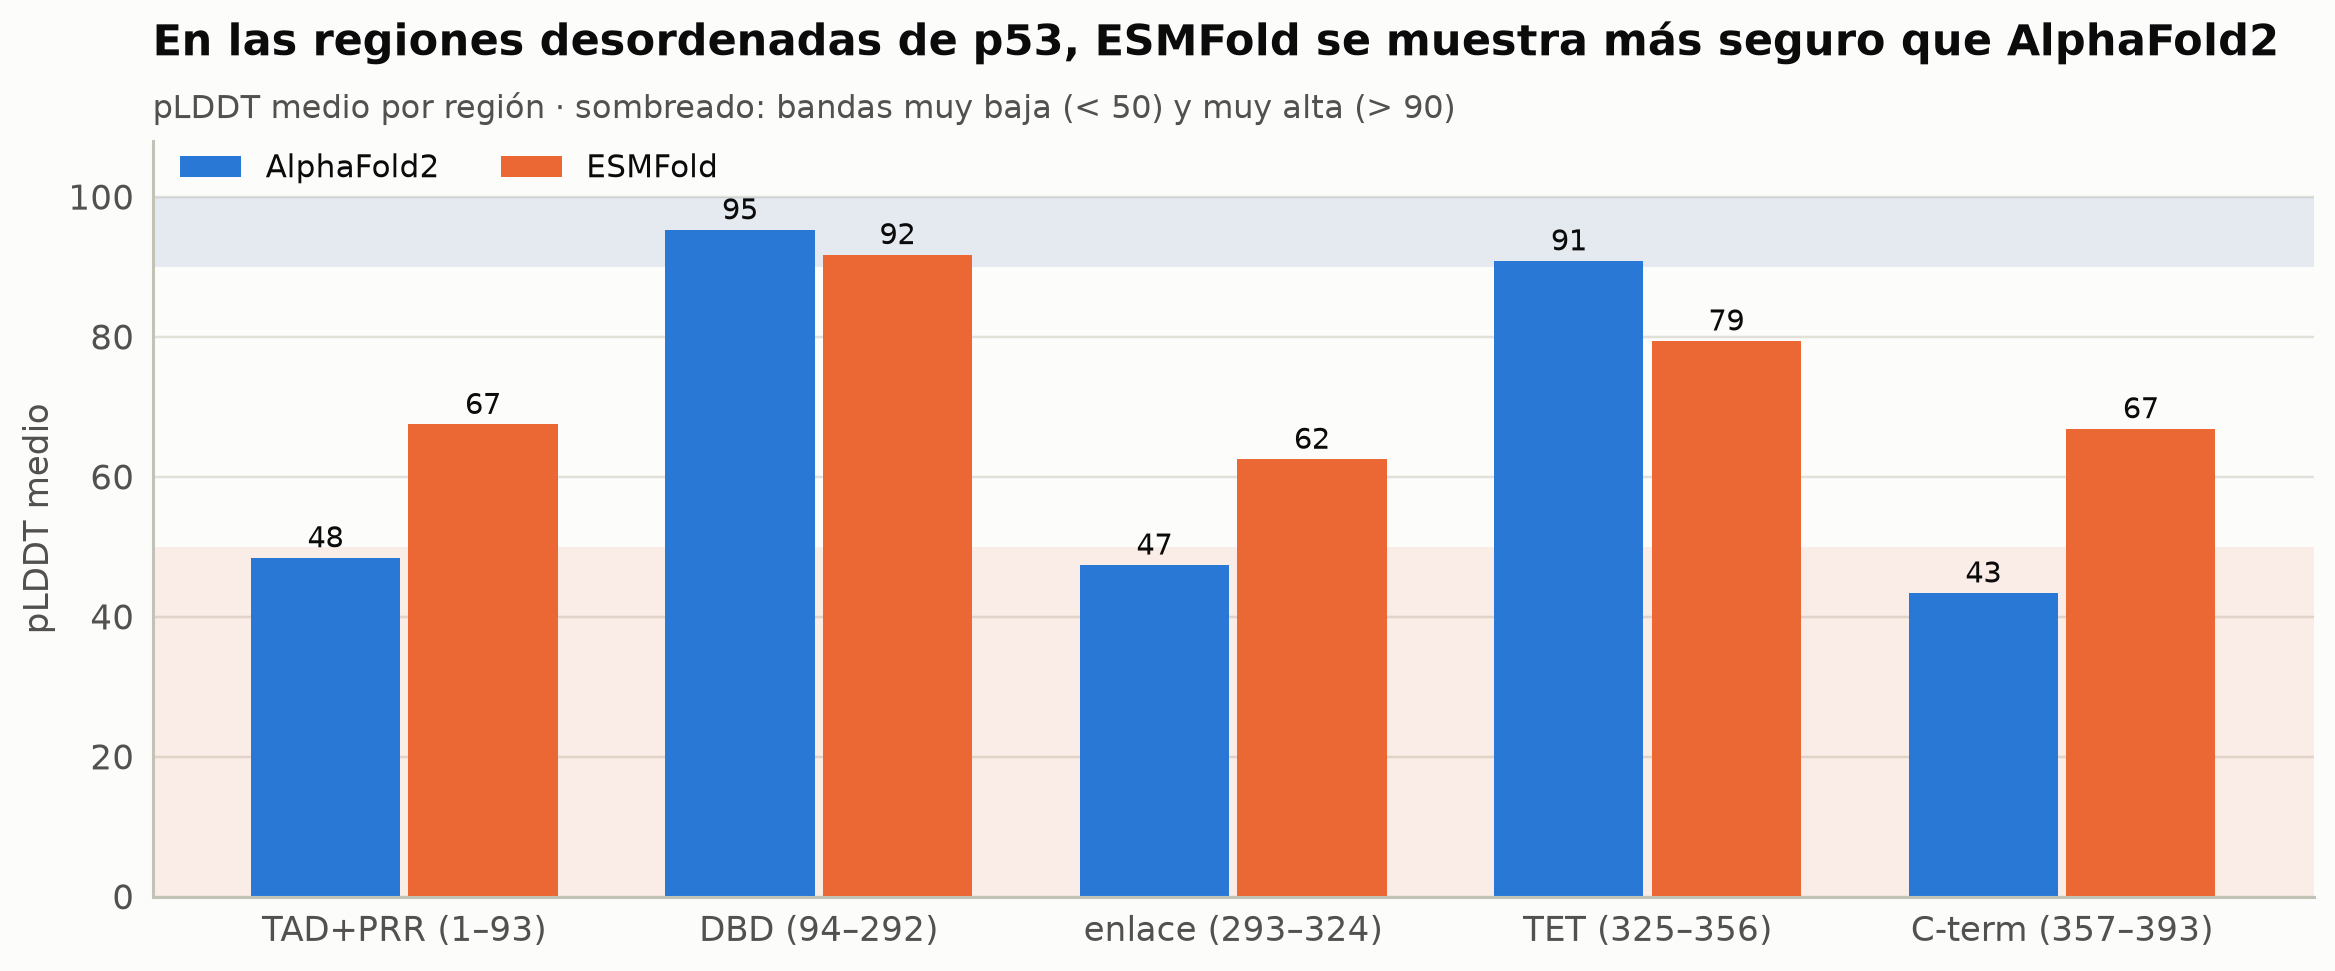

In [35]:
dis = pd.DataFrame({"AlphaFold2": [plddt[a - 1:b].mean() for a, b, _, _ in DOMAINS],
                    "ESMFold": [plddt_esm[a - 1:b].mean() for a, b, _, _ in DOMAINS]},
                   index=[f"{s} ({a}–{b})" for a, b, _, s in DOMAINS])
print(dis.round(1))
fig, ax = plt.subplots(figsize=(10.5, 4.3))
xk = np.arange(len(dis))
ax.axhspan(0, 50, color=BAND_COLOR["muy baja"], alpha=0.10, lw=0); ax.axhspan(90, 100, color=BAND_COLOR["muy alta"], alpha=0.10, lw=0)
for k, (col, name) in enumerate([(ec.BLUE, "AlphaFold2"), (ec.ORANGE, "ESMFold")]):
    ax.bar(xk + (k - 0.5) * 0.38, dis[name], width=0.36, color=col, label=name)
    for x_, v_ in zip(xk, dis[name]):
        ax.text(x_ + (k - 0.5) * 0.38, v_ + 1.5, f"{v_:.0f}", ha="center", fontsize=9.5)
ax.set_xticks(xk, dis.index); ax.set_ylim(0, 108); ax.set_ylabel("pLDDT medio")
ax.legend(loc="upper left", ncols=2, bbox_to_anchor=(0, 1.02))
ec.title(ax, "En las regiones desordenadas de p53, ESMFold se muestra más seguro que AlphaFold2",
         "pLDDT medio por región · sombreado: bandas muy baja (< 50) y muy alta (> 90)")
plt.show()

> 🔎 **Qué observamos.** En los dominios plegados ambos predictores están de acuerdo. En las regiones desordenadas,
> AlphaFold2 da pLDDT muy bajo (< 50), la señal clásica de desorden, mientras que ESMFold, **en esta proteína**, asigna
> valores de la banda «baja» a regiones que no tienen estructura fija. La moraleja no es que un método sea «mejor», sino que
> los umbrales de pLDDT se calibraron para cada predictor y no conviene trasladarlos sin más de uno a otro.

### 11.2 Complejos: el dominio de tetramerización sólo tiene sentido en el tetrámero

El modelo de AlphaFold DB es de **una sola cadena**. Pero p53 funciona como tetrámero: el dominio de tetramerización
(325–356), una hebra $\beta$ y una hélice, se empareja con otras tres copias. El cristal `1C26` contiene una cadena, y su
cabecera (`REMARK 350`) da las operaciones de simetría (`BIOMT`) para reconstruir el tetrámero biológico. Contemos, para
cada residuo, cuántos contactos hace con su propia cadena y cuántos con las otras tres.

4 operaciones de simetría → tetrámero de 1076 átomos pesados
pares átomo–átomo < 4,5 Å: propios 610 · con otras cadenas 484 → 44% de los contactos del dominio son entre cadenas
modelo monomérico de AlphaFold vs 1C26 (cadena A, 32 Cα): RMSD = 0.82 Å · pLDDT medio 90.9


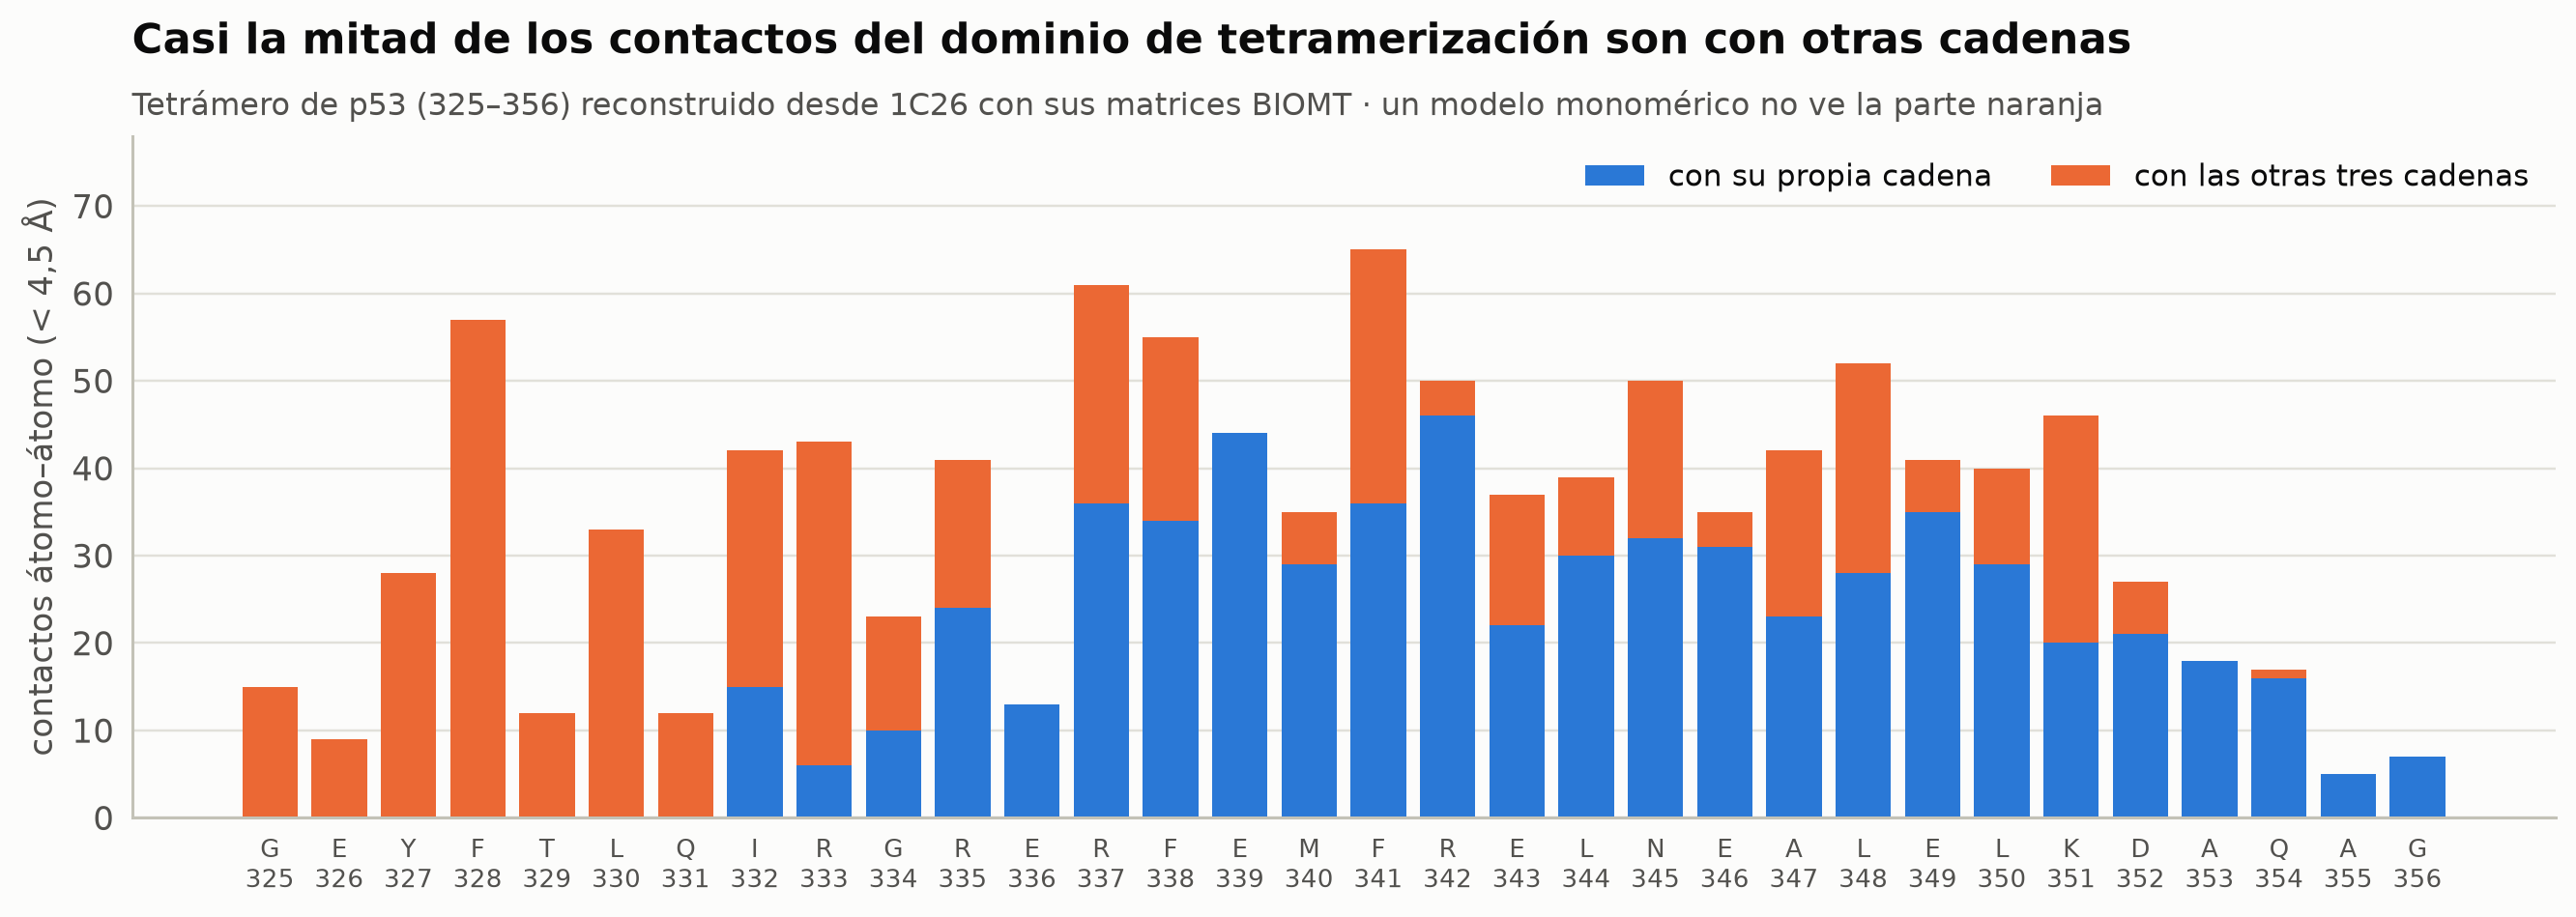

In [36]:
# Reconstrucción del tetrámero de 1C26 a partir de las matrices BIOMT
ops = {}
for l in x1c26_txt.splitlines():
    if l.startswith("REMARK 350   BIOMT"):
        f = l.split()
        ops.setdefault(int(f[3]), []).append([float(v) for v in f[4:8]])
ops = {k: np.array(v) for k, v in ops.items()}
heavy = x1c26_df[(x1c26_df.record == "ATOM") & (x1c26_df.element != "H")]
xyz0 = heavy[["x", "y", "z"]].values
copies = [xyz0 @ M[:, :3].T + M[:, 3] for M in ops.values()]
print(f"{len(ops)} operaciones de simetría → tetrámero de {len(copies) * len(xyz0)} átomos pesados")

res_ids = heavy.resnum.values
intra, inter = Counter(), Counter()
D_self = np.linalg.norm(xyz0[:, None] - xyz0[None], axis=2)
near_self = (D_self < 4.5) & (np.abs(res_ids[:, None] - res_ids[None]) >= 3)
for i_, r_ in enumerate(res_ids):
    intra[r_] += near_self[i_].sum()
for other in copies[1:]:
    D_o = np.linalg.norm(xyz0[:, None] - other[None], axis=2) < 4.5
    for i_, r_ in enumerate(res_ids):
        inter[r_] += D_o[i_].sum()
tet_res = sorted(set(res_ids))
frac_inter = sum(inter.values()) / (sum(inter.values()) + sum(intra.values()))
print(f"pares átomo–átomo < 4,5 Å: propios {sum(intra.values())} · con otras cadenas {sum(inter.values())} "
      f"→ {frac_inter:.0%} de los contactos del dominio son entre cadenas")
xt = residues(x1c26_df, chain="A")
kk = [k for k in sorted(xt) if k in af]
print(f"modelo monomérico de AlphaFold vs 1C26 (cadena A, {len(kk)} Cα): RMSD = "
      f"{sup_rmsd(np.array([af[k][0] for k in kk]), np.array([xt[k][0] for k in kk])):.2f} Å · pLDDT medio {np.mean([af[k][1] for k in kk]):.1f}")

fig, ax = plt.subplots(figsize=(12, 4.2))
a_ = np.array([intra[r_] for r_ in tet_res]); b_ = np.array([inter[r_] for r_ in tet_res])
ax.bar(tet_res, a_, color=ec.BLUE, label="con su propia cadena")
ax.bar(tet_res, b_, bottom=a_, color=ec.ORANGE, label="con las otras tres cadenas")
ax.set_xticks(tet_res, [f"{P53_SEQ[r_ - 1]}\n{r_}" for r_ in tet_res], fontsize=8.5)
ax.set_ylabel("contactos átomo–átomo (< 4,5 Å)"); ax.legend(loc="upper right", ncols=2)
ax.set_ylim(0, (a_ + b_).max() * 1.2)
ec.title(ax, "Casi la mitad de los contactos del dominio de tetramerización son con otras cadenas",
         "Tetrámero de p53 (325–356) reconstruido desde 1C26 con sus matrices BIOMT · un modelo monomérico no ve la parte naranja")
plt.show()

> 🔎 **Qué observamos.** Casi la mitad (44 %) de los contactos de este dominio son **entre cadenas**. El modelo monomérico de
> AlphaFold coincide con el cristal (RMSD bajo) y tiene pLDDT alto: la red «recuerda» la forma que el dominio adopta en el
> tetrámero, pero el modelo no contiene a las compañeras que la estabilizan. Para preguntar por una interfaz hay que
> predecir el **complejo** (AlphaFold-Multimer, AlphaFold3 o ColabFold en modo multímero) y leer la confianza de la
> interfaz (ipTM).

### 11.3 Cambios conformacionales: la calmodulina

La **calmodulina** es un sensor de calcio de 148 residuos con dos lóbulos (N y C). Sin calcio (apo), cada lóbulo está
cerrado; al unir Ca²⁺, se abre y expone bolsas hidrofóbicas, y la hélice central que une los lóbulos es flexible.
Comparamos el modelo de AlphaFold (`AF-P0DP23`, predicho **sin iones**) con dos estructuras experimentales: `1CLL`
(cristal con Ca²⁺) y `1CFD` (RMN sin calcio).

                           vs 1CLL (con Ca²⁺)  vs 1CFD (sin Ca²⁺)
región                                                           
lóbulo N (5–74)                          0.87                3.79
lóbulo C (82–146)                        0.54                4.35
molécula completa (5–146)                6.36                5.90


PAE medio lóbulo N→N 3.9 Å · C→C 3.7 Å · N→C 22.0 Å


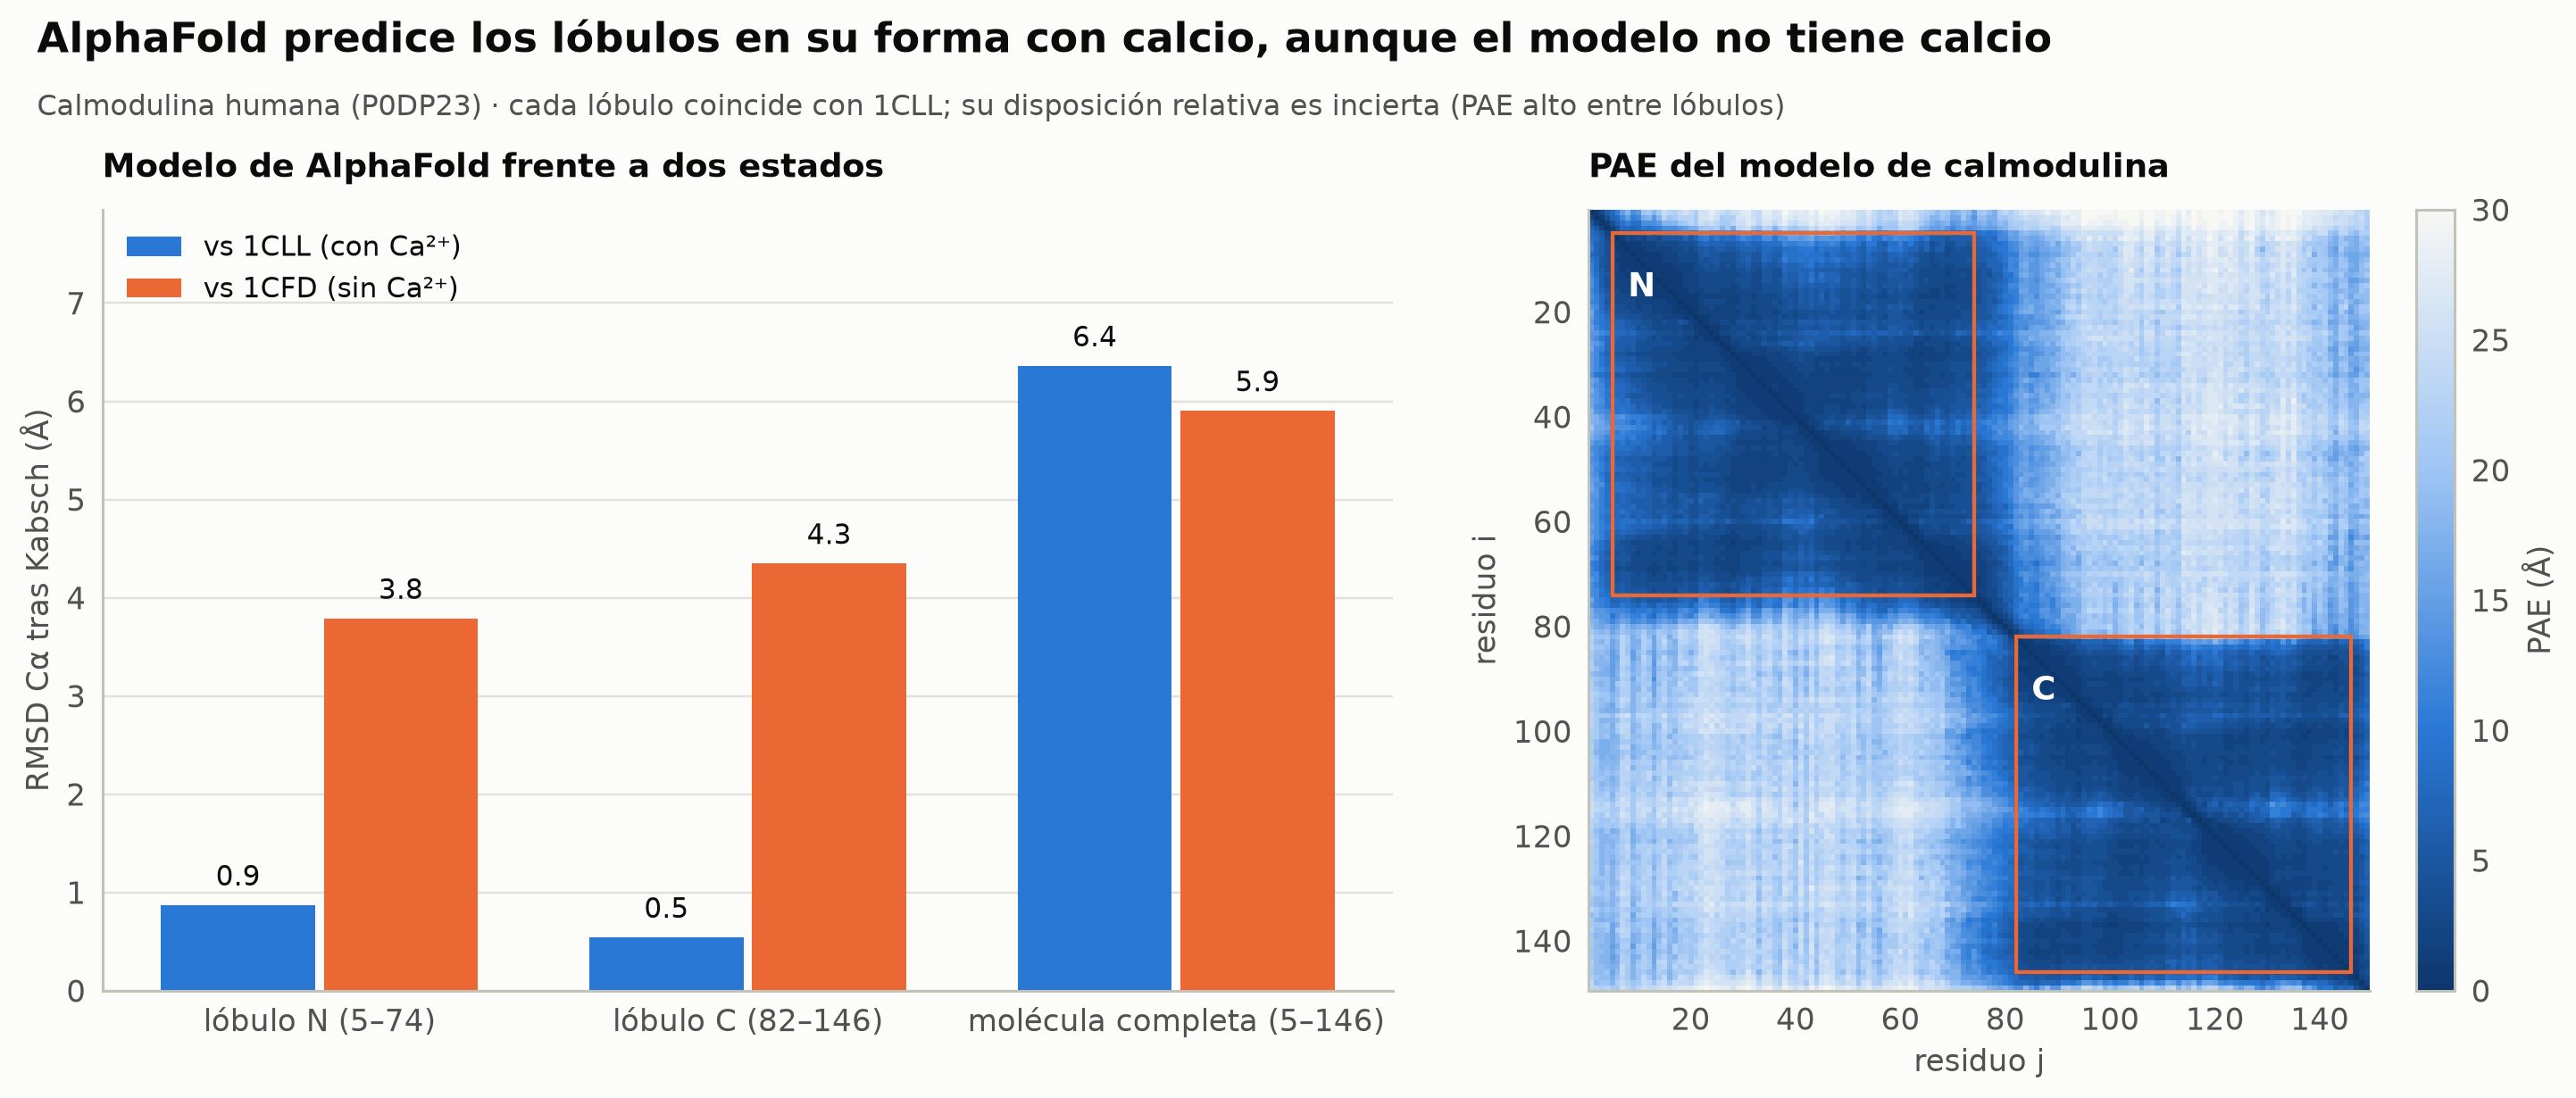

In [37]:
cam_af_df = read_pdb(course_text("152_AF-P0DP23-F1-model_v6.pdb.gz", f"{AFDB}/AF-P0DP23-F1-model_v6.pdb"))
cam_pae = json.loads(course_text("152_AF-P0DP23-F1-predicted_aligned_error_v6.json.gz",
                                 f"{AFDB}/AF-P0DP23-F1-predicted_aligned_error_v6.json"))
cam_pae = np.array((cam_pae[0] if isinstance(cam_pae, list) else cam_pae)["predicted_aligned_error"], dtype=int)
cam_af = residues(cam_af_df)
holo = residues(read_pdb(course_text("152_1CLL.pdb.gz", f"{RCSB}/1CLL.pdb")), chain="A")
apo = residues(read_pdb(course_text("152_1CFD.pdb.gz", f"{RCSB}/1CFD.pdb")), chain="A")
# Numeración: UniProt (AlphaFold) incluye la Met inicial; los PDB numeran la proteína madura → AF k+1 ↔ PDB k
cam_rows = []
for part, rng_ in [("lóbulo N (5–74)", range(5, 75)), ("lóbulo C (82–146)", range(82, 147)), ("molécula completa (5–146)", range(5, 147))]:
    row = {"región": part}
    for name, ref in [("vs 1CLL (con Ca²⁺)", holo), ("vs 1CFD (sin Ca²⁺)", apo)]:
        ks = [k for k in rng_ if k in ref and k + 1 in cam_af]
        row[name] = sup_rmsd(np.array([cam_af[k + 1][0] for k in ks]), np.array([ref[k][0] for k in ks]))
    cam_rows.append(row)
cam_df = pd.DataFrame(cam_rows).set_index("región")
print(cam_df.round(2))
print(f"PAE medio lóbulo N→N {cam_pae[5:75, 5:75].mean():.1f} Å · C→C {cam_pae[82:147, 82:147].mean():.1f} Å · "
      f"N→C {cam_pae[5:75, 82:147].mean():.1f} Å")

fig, axs = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw=dict(width_ratios=[1.4, 1]))
ax = axs[0]
xk = np.arange(len(cam_df))
for k, (col, name) in enumerate([(ec.BLUE, "vs 1CLL (con Ca²⁺)"), (ec.ORANGE, "vs 1CFD (sin Ca²⁺)")]):
    ax.bar(xk + (k - 0.5) * 0.38, cam_df[name], width=0.36, color=col, label=name)
    for x_, v_ in zip(xk, cam_df[name]):
        ax.text(x_ + (k - 0.5) * 0.38, v_ + 0.2, f"{v_:.1f}", ha="center", fontsize=10)
ax.set_xticks(xk, cam_df.index); ax.set_ylabel("RMSD Cα tras Kabsch (Å)")
ax.set_ylim(0, cam_df.values.max() * 1.25); ax.legend(loc="upper left")
ax.set_title("Modelo de AlphaFold frente a dos estados", loc="left", fontsize=12)
ax = axs[1]
im = ax.imshow(cam_pae, cmap=cmap_pae, vmin=0, vmax=30, extent=(0.5, 149.5, 149.5, 0.5)); ax.grid(False)
for a, b, n in [(5, 74, "N"), (82, 146, "C")]:
    ax.add_patch(Rectangle((a, a), b - a, b - a, fill=False, ec=ec.ORANGE, lw=1.4))
    ax.text(a + 3, a + 12, n, color="white", fontsize=12, fontweight="bold")
ax.set_xlabel("residuo j"); ax.set_ylabel("residuo i")
fig.colorbar(im, ax=ax, fraction=0.046, label="PAE (Å)")
ax.set_title("PAE del modelo de calmodulina", loc="left", fontsize=12)
ec.fig_title(fig, "AlphaFold predice los lóbulos en su forma con calcio, aunque el modelo no tiene calcio",
             "Calmodulina humana (P0DP23) · cada lóbulo coincide con 1CLL; su disposición relativa es incierta (PAE alto entre lóbulos)")
plt.show()

> 🔎 **Qué observamos.** Cada lóbulo del modelo coincide con el cristal **con calcio** a menos de 1 Å, y difiere varios
> angstroms de la estructura **sin calcio**: AlphaFold predijo el estado más representado en el PDB, aunque el modelo no
> contiene un solo ion. La molécula completa no coincide con ninguno de los dos, y el PAE entre lóbulos (> 20 Å) avisa de
> que su disposición relativa es arbitraria. Si su pregunta es cómo cambia la calmodulina al unir calcio, un único modelo
> de AlphaFold no puede responderla.

> ✅ **Compruebe su comprensión.** Relacione cada limitación con la medida que la delata: (a) región desordenada,
> (b) dominios de orientación incierta, (c) interfaz con otra cadena. *(a) pLDDT muy bajo; (b) PAE alto fuera de los
> bloques diagonales; (c) ninguna medida del modelo monomérico: hace falta predecir el complejo y mirar el ipTM.*

---

## 12. AlphaFold DB, RoseTTAFold, ESMFold, AlphaFold3 y ColabFold

**AlphaFold DB.** Con el método publicado, DeepMind y el EMBL-EBI calcularon modelos para proteomas completos y los
ofrecieron gratuitamente (Varadi et al., 2022). La ampliación posterior a prácticamente todo UniProt, con más de 200
millones de modelos, cambió la escala del campo: por primera vez, la mayoría de las proteínas conocidas tiene un modelo
estructural. El PDB integra hoy estos modelos en su portal, separados de las estructuras experimentales. Ya usamos su API
en la sección 3: un JSON con metadatos y enlaces a PDB, mmCIF, PAE y AlphaMissense.

**RoseTTAFold.** Casi simultáneamente, Baek y colaboradores (2021) presentaron una red de «tres pistas» en la que la
información de la secuencia (1D), de las distancias entre residuos (2D) y de las coordenadas (3D) fluye y se actualiza en
paralelo. Con una exactitud cercana a la de AlphaFold2 y código abierto desde el principio, mostró además que la misma
arquitectura podía predecir complejos.

**ESMFold.** AlphaFold2 y RoseTTAFold dependen de un MSA, cuya construcción es lenta y que falla para proteínas con pocos
homólogos (sección 6.3). Lin y colaboradores (2023) sustituyeron el MSA por un **modelo de lenguaje de proteínas**, ESM-2,
un *transformer* de hasta 15 000 millones de parámetros entrenado **sólo** a adivinar aminoácidos enmascarados en millones
de secuencias. Es el mismo juego que completar «el perro ladra al ___»: para acertar qué aminoácido falta en una
posición, el modelo tiene que aprender qué otras posiciones lo condicionan, es decir, **la coevolución**, y esa información
queda en sus representaciones internas. ESMFold acopla ESM-2 a un módulo de plegamiento y predice estructuras **a partir de
una sola secuencia**, hasta un orden de magnitud más rápido que AlphaFold2, a cambio de una exactitud algo menor en
proteínas con pocos homólogos. Su velocidad permitió plegar más de 600 millones de proteínas metagenómicas.

El objetivo de entrenamiento de un modelo de lenguaje enmascarado se escribe (notación propia de esta clase):

$$
\mathcal L=-\sum_{i\in\mathcal M}\log p_\theta\!\left(a_i\mid \mathbf a_{\setminus\mathcal M}\right),
$$

| Símbolo | Significado |
|---|---|
| $\mathcal M$ | Conjunto de posiciones enmascaradas al azar (≈ 15 % de la secuencia) |
| $\mathbf a_{\setminus\mathcal M}$ | La secuencia con esas posiciones ocultas |
| $p_\theta(a_i\mid\cdot)$ | Probabilidad que el modelo, con parámetros $\theta$, asigna al aminoácido verdadero $a_i$ |

ESM Atlas ofrece una API pública de ESMFold para secuencias de hasta 400 residuos. La llamamos **en vivo** con el
dominio de tetramerización de p53 (31 residuos). Si el servidor no responde (ocurre con frecuencia: es un servicio
experimental), usamos la respuesta guardada en el repositorio.

In [38]:
def esmfold(seq, timeout=30):
    """Predice una estructura con la API pública de ESMFold (devuelve el texto PDB)."""
    req = urllib.request.Request("https://api.esmatlas.com/foldSequence/v1/pdb/", data=seq.encode(), method="POST")
    with urllib.request.urlopen(req, timeout=timeout) as r:
        return r.read().decode()

tet_seq = P53_SEQ[324:355]                               # residuos 325-355
t0 = time.time()
try:
    tet_pdb = esmfold(tet_seq)
    assert tet_pdb.startswith("HEADER") or "ATOM" in tet_pdb
    source = f"API en vivo ({time.time() - t0:.1f} s)"
except Exception as err:
    tet_pdb = course_text("152_esmfold_p53_tet325-355.pdb.gz")
    source = f"copia guardada (la API respondió: {str(err)[:60]})"
tet_df = read_pdb(tet_pdb)
tet_esm = residues(tet_df)
# ESMFold numera desde 1: residuo k de la predicción ↔ residuo 324+k de p53
tet_esm = {k + 324: v for k, v in tet_esm.items()}
kk = [k for k in sorted(tet_esm) if k in xt]
P = np.array([tet_esm[k][0] for k in kk]); Qx = np.array([xt[k][0] for k in kk])
print(f"secuencia: {tet_seq} · fuente: {source}")
print(f"ESMFold (péptido aislado) vs 1C26: {len(kk)} Cα, RMSD = {sup_rmsd(P, Qx):.2f} Å · "
      f"pLDDT medio = {np.mean([tet_esm[k][1] for k in kk]) * 100:.1f}")

secuencia: GEYFTLQIRGRERFEMFRELNEALELKDAQA · fuente: API en vivo (1.0 s)
ESMFold (péptido aislado) vs 1C26: 31 Cα, RMSD = 0.71 Å · pLDDT medio = 87.8


> 🔎 **Qué observamos.** En segundos, y sin ningún alineamiento, ESMFold devuelve la estructura del péptido y su propia
> estimación de confianza en la columna del factor $B$ (en escala 0–1). Compare su RMSD frente al cristal con el del modelo
> de AlphaFold de la sección 11.2: plegar un fragmento aislado de 31 residuos, que en la naturaleza sólo es estable dentro
> del tetrámero, es una prueba exigente, y aun así ESMFold recupera su hebra y su hélice con un error inferior a 1 Å.

**AlphaFold3.** Abramson y colaboradores (2024) extendieron el enfoque a casi toda la química de la célula: proteínas,
ácidos nucleicos, ligandos pequeños, iones y residuos modificados, en un mismo complejo. El Evoformer se reemplaza por un
módulo más ligero (**Pairformer**) que procesa el MSA de forma reducida, y el módulo de estructura por un **módulo de
difusión** que genera directamente coordenadas atómicas partiendo de ruido y eliminándolo paso a paso, sin marcos ni
torsiones. En las pruebas de sus autores superó a los métodos de *docking* clásicos en complejos proteína-ligando, lo que
conecta con la lección 15.3.

**ColabFold.** Mirdita y colaboradores (2022) hicieron AlphaFold2 accesible a cualquiera: reemplazaron la búsqueda de
homólogos por MMseqs2 en un servidor, lo que acelera la construcción del MSA en uno o dos órdenes de magnitud, y lo
empaquetaron en cuadernos de Google Colab y en una herramienta de línea de órdenes:

```bash
# instalación: https://github.com/sokrypton/ColabFold
colabfold_batch --num-recycle 3 --amber --use-gpu-relax \
    p53_dbd.fasta resultados/
ls resultados/
# p53_dbd_unrelaxed_rank_001_..._model_3_seed_000.pdb
# p53_dbd_scores_rank_001_..._model_3_seed_000.json  (pLDDT, PAE)
# p53_dbd_coverage.png  p53_dbd_pae.png  p53_dbd_plddt.png
```

| Medida | Alcance | Pregunta que responde |
|---|---|---|
| pLDDT | por residuo (0–100) | ¿está bien predicho el entorno local de este residuo? |
| PAE | por par de residuos (Å) | ¿está bien colocado $j$ respecto a $i$? Revela dominios y su orientación relativa |
| pTM | global (0–1) | TM-score esperado del modelo completo |
| ipTM | interfaz (0–1) | en complejos, ¿está bien predicha la interfaz entre cadenas? |

> 🏛️ **El premio del problema de cincuenta años.** CASP se creó en 1994 precisamente porque los avances anunciados rara vez
> resistían una evaluación a ciegas. Veintiséis años después, en CASP14, sus organizadores declararon que, para las
> proteínas individuales, el problema estaba esencialmente resuelto. En 2024, Demis Hassabis y John Jumper compartieron el
> premio Nobel de Química por AlphaFold, junto con David Baker, del grupo de RoseTTAFold, por el diseño computacional de
> proteínas.

Si trabaja en Colab, la celda siguiente muestra el modelo de p53 en 3D, interactivo y coloreado con los colores de
AlphaFold DB por pLDDT (fuera de Colab se omite).

In [39]:
# Visor 3D opcional (sólo en Colab): el modelo de p53 coloreado por pLDDT
if IN_COLAB:
    try:
        import py3Dmol
    except ImportError:
        %pip install -q py3Dmol
        import py3Dmol
    view = py3Dmol.view(width=720, height=480)
    view.addModel(pdb_text, "pdb")
    view.setStyle({"cartoon": {"colorscheme": {"prop": "b", "gradient": "roygb", "min": 50, "max": 90}}})
    view.zoomTo(); view.show()
else:
    print("Visor 3D omitido fuera de Colab (use la traza 3D de la sección 8.2).")

Visor 3D omitido fuera de Colab (use la traza 3D de la sección 8.2).


---

## 13. Ejercicios

**Ejercicio 1 (Levinthal).** Repita la cuenta de Levinthal para una proteína de 150 residuos con sólo **2** estados por
residuo y una conformación cada $10^{-13}$ s. ¿Cuántas veces la edad del universo tardaría la búsqueda exhaustiva?

**Ejercicio 2 (GDT_TS a mano).** Tras superponer un modelo de 8 residuos, sus distancias a la referencia son
$0{,}6;\ 0{,}9;\ 1{,}8;\ 2{,}2;\ 3{,}5;\ 6{,}0;\ 9{,}0;\ 15{,}0$ Å. Calcule $P_1, P_2, P_4, P_8$ y el GDT_TS con esta
superposición fija. Compruébelo con código.

**Ejercicio 3 (atención).** Con $\mathbf q_1^\top\mathbf k_j=(3,\,0,\,-1)$ y $c=9$, calcule los pesos $\alpha_{1j}$ sin
sesgo y con $b_{1\cdot}=(0,\,2,\,0)$. ¿Cuál es el residuo más atendido en cada caso?

**Ejercicio 4 (coevolución de largo alcance).** Los contactos entre residuos lejanos en la secuencia son los que más
informan sobre el plegamiento. Repita la evaluación de precisión (top $L/5$, $L/2$ y $L$) de MI+APC y DCA+APC usando sólo
pares con $|i-j|\ge 12$. ¿Qué método gana y por cuánto frente al azar?

**Ejercicio 5 (PAE de la región desordenada).** Calcule el PAE medio del bloque de los residuos 1–60 consigo mismo, y la
fracción de esos residuos con pLDDT < 50. ¿Es coherente la lectura del PAE con la del pLDDT?

**Ejercicio 6 (una variante hereditaria en el dominio de tetramerización).** La variante germinal **R337H** es frecuente
en el sur de Brasil y predispone a tumores de la infancia. Obtenga su pLDDT, su puntuación de AlphaMissense y el número de
contactos que el residuo 337 hace con su propia cadena y con las otras cadenas del tetrámero de `1C26`. ¿Qué parte de la
pregunta «¿por qué es dañina?» puede responder el modelo monomérico de AlphaFold y cuál no?

In [40]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
n_conf = 2 ** 150
t_years = n_conf * 1e-13 / 3.156e7
print(f"2^150 = {n_conf:.2e} conformaciones → {t_years:.2e} años = {t_years / 1.38e10:.1e} veces la edad del universo")

2^150 = 1.43e+45 conformaciones → 4.52e+24 años = 3.3e+14 veces la edad del universo


In [41]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
d_ex = np.array([0.6, 0.9, 1.8, 2.2, 3.5, 6.0, 9.0, 15.0])
Pc_ex = {c: np.mean(d_ex < c) for c in (1, 2, 4, 8)}
print("P_c:", {c: f"{v:.3f}" for c, v in Pc_ex.items()}, "→ GDT_TS =", 25 * sum(Pc_ex.values()))
# P1 = 2/8, P2 = 3/8, P4 = 5/8, P8 = 6/8 → GDT_TS = 25 × 2,0 = 50

P_c: {1: '0.250', 2: '0.375', 4: '0.625', 8: '0.750'} → GDT_TS = 50.0


In [42]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
w0 = attention_weights([3, 0, -1], 9)
w1 = attention_weights([3, 0, -1], 9, b=[0, 2, 0])
print("sin sesgo:", w0.round(3), "→ más atendido: j =", w0.argmax() + 1)
print("con sesgo:", w1.round(3), "→ más atendido: j =", w1.argmax() + 1)
# Argumentos sin sesgo: (1, 0, -1/3); con sesgo: (1, 2, -1/3). El sesgo de pares cambia el foco del residuo 1 al 2.

sin sesgo: [0.613 0.225 0.162] → más atendido: j = 1
con sesgo: [0.251 0.683 0.066] → más atendido: j = 2


In [43]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
sep = np.array([col_res[b] - col_res[a] for a, b in pairs])
lr = sep >= 12
base_lr = is_contact[lr].mean()
out = {}
for name in ("MI_APC", "DCA_APC"):
    sc = np.array([scores[name][a, b] for a, b in pairs])[lr]
    o = np.argsort(-sc)
    out[name] = {f"top {k}": f"{is_contact[lr][o[:k]].mean():.0%}" for k in (Lc // 5, Lc // 2, Lc)}
print(pd.DataFrame(out).T)
print(f"azar (|i−j| ≥ 12): {base_lr:.1%}")

        top 37 top 93 top 187
MI_APC     14%     9%      6%
DCA_APC    49%    32%     21%
azar (|i−j| ≥ 12): 2.5%


In [44]:
#@title 🔑 Solución — Ejercicio 5 { display-mode: "form" }
print(f"PAE medio 1–60 × 1–60: {PAE[:60, :60].mean():.1f} Å")
print(f"residuos 1–60 con pLDDT < 50: {np.mean(plddt[:60] < 50):.0%}")
# Ambos coinciden: la región no tiene estructura definida; ni el entorno local (pLDDT) ni las posiciones
# relativas entre sus propios residuos (PAE alto incluso dentro del bloque) son fiables.

PAE medio 1–60 × 1–60: 19.2 Å
residuos 1–60 con pLDDT < 50: 73%


In [45]:
#@title 🔑 Solución — Ejercicio 6 { display-mode: "form" }
print(f"R337H: pLDDT = {plddt[336]:.1f} ({band_of(plddt[336])}) · AlphaMissense = "
      f"{am_idx.am_pathogenicity['R337H']:.3f} ({am_idx.am_class['R337H']})")
print(f"residuo 337 en el tetrámero de 1C26: contactos propios = {intra[337]} · con otras cadenas = {inter[337]}")
# El modelo monomérico sitúa con confianza a Arg337 en su hélice, pero sus contactos más relevantes son con
# otras cadenas: el efecto (desestabilizar el tetrámero, sobre todo a pH algo elevado) sólo se puede razonar
# con el complejo. El monómero responde «dónde está»; no responde «qué interacción rompe».

R337H: pLDDT = 94.8 (muy alta) · AlphaMissense = 0.552 (Amb)
residuo 337 en el tetrámero de 1C26: contactos propios = 36 · con otras cadenas = 25


---

## 📌 Resumen

* **Anfinsen**: la secuencia determina la estructura nativa (mínimo de energía libre). **Levinthal**: una búsqueda al
  azar tardaría $\sim10^{27}$ años; la solución es un paisaje en **embudo**, no un campo de golf.
* **Modelado por homología** (MODELLER): copiar restricciones de una plantilla; su calidad depende de la identidad
  (> 50 % muy bueno, 30–50 % núcleo fiable, < 30 % el alineamiento domina el error). El ***threading*** evalúa si una
  secuencia «encaja» en un plegamiento conocido aunque la identidad sea baja.
* **CASP** evalúa a ciegas; su medida principal es el $\mathrm{GDT\_TS}=\tfrac{100}{4}(P_1+P_2+P_4+P_8)$.
* **Coevolución**: columnas del MSA que covarían delatan contactos. La información mutua confunde efectos directos e
  indirectos; el **DCA** (modelo de Potts, $J_{ij}\approx-(C^{-1})_{ij}$) con corrección **APC** acertó el 54 % de sus
  37 mejores pares en la familia de p53, frente a un 3 % al azar. Necesita muchas secuencias **efectivas**.
* **AlphaFold2**: MSA + pares → 48 bloques **Evoformer** (atención por filas/columnas, sesgo de pares, actualizaciones
  triangulares, producto externo) → **módulo de estructura** (marcos rígidos, IPA) → reciclado ×3; pérdida FAPE.
* **Confianza**: el **pLDDT** predice el lDDT local (bandas > 90, 70–90, 50–70, < 50); el **PAE** dice si $j$ está bien
  colocado respecto a $i$ y revela dominios. En p53: DBD 95,3 y TET 90,9 de pLDDT; PAE 3,6 / 2,9 Å dentro y 20,1 Å entre
  ellos; 0,51 Å de RMSD y TM-score 0,99 frente a `2OCJ` en 194 C$_\alpha$.
* **Uso clínico**: los puntos calientes de cáncer (R175, G245, R248, R249, R273, R282, Y220) caen en la región de confianza
  muy alta; la variante P72R, en una región desordenada donde el modelo no informa.
* **Limitaciones**: desorden (pLDDT bajo; los umbrales dependen del predictor), complejos (el monómero no ve las
  interfaces: tetrámero de p53), cambios conformacionales (la calmodulina se predice en el estado con calcio).
* **Herramientas**: AlphaFold DB (> 200 millones de modelos), RoseTTAFold, **ESMFold** (modelo de lenguaje, sin MSA, API
  pública), **AlphaFold3** (complejos con ligandos, difusión) y **ColabFold** (MMseqs2 + Colab).

## 📚 Lecturas recomendadas

* Anfinsen, C. B. (1973). Principles that govern the folding of protein chains. *Science*, 181, 223–230. https://doi.org/10.1126/science.181.4096.223
* Zwanzig, R., Szabo, A. y Bagchi, B. (1992). Levinthal's paradox. *PNAS*, 89, 20–22. https://doi.org/10.1073/pnas.89.1.20
* Dill, K. A. y Chan, H. S. (1997). From Levinthal to pathways to funnels. *Nature Structural Biology*, 4, 10–19. https://doi.org/10.1038/nsb0197-10
* Šali, A. y Blundell, T. L. (1993). Comparative protein modelling by satisfaction of spatial restraints. *J. Mol. Biol.*, 234, 779–815. https://doi.org/10.1006/jmbi.1993.1626
* Jones, D. T., Taylor, W. R. y Thornton, J. M. (1992). A new approach to protein fold recognition. *Nature*, 358, 86–89. https://doi.org/10.1038/358086a0
* Moult, J. et al. (1995). A large-scale experiment to assess protein structure prediction methods. *Proteins*, 23, ii–v. https://doi.org/10.1002/prot.340230303
* Kryshtafovych, A. et al. (2021). Critical assessment of methods of protein structure prediction (CASP) — Round XIV. *Proteins*, 89, 1607–1617. https://doi.org/10.1002/prot.26237
* Dunn, S. D., Wahl, L. M. y Gloor, G. B. (2008). Mutual information without the influence of phylogeny or entropy dramatically improves residue contact prediction. *Bioinformatics*, 24, 333–340. https://doi.org/10.1093/bioinformatics/btm604
* Morcos, F. et al. (2011). Direct-coupling analysis of residue coevolution captures native contacts across many protein families. *PNAS*, 108, E1293–E1301. https://doi.org/10.1073/pnas.1111471108
* Jumper, J. et al. (2021). Highly accurate protein structure prediction with AlphaFold. *Nature*, 596, 583–589. https://doi.org/10.1038/s41586-021-03819-2
* Mariani, V. et al. (2013). lDDT: a local superposition-free score for comparing protein structures and models using distance difference tests. *Bioinformatics*, 29, 2722–2728. https://doi.org/10.1093/bioinformatics/btt473
* Varadi, M. et al. (2022). AlphaFold Protein Structure Database. *Nucleic Acids Research*, 50, D439–D444. https://doi.org/10.1093/nar/gkab1061
* Baek, M. et al. (2021). Accurate prediction of protein structures and interactions using a three-track neural network. *Science*, 373, 871–876. https://doi.org/10.1126/science.abj8754
* Lin, Z. et al. (2023). Evolutionary-scale prediction of atomic-level protein structure with a language model. *Science*, 379, 1123–1130. https://doi.org/10.1126/science.ade2574
* Abramson, J. et al. (2024). Accurate structure prediction of biomolecular interactions with AlphaFold 3. *Nature*, 630, 493–500. https://doi.org/10.1038/s41586-024-07487-w
* Mirdita, M. et al. (2022). ColabFold: making protein folding accessible to all. *Nature Methods*, 19, 679–682. https://doi.org/10.1038/s41592-022-01488-1
* Cho, Y., Gorina, S., Jeffrey, P. D. y Pavletich, N. P. (1994). Crystal structure of a p53 tumor suppressor-DNA complex: understanding tumorigenic mutations. *Science*, 265, 346–355. https://doi.org/10.1126/science.8023157
* Jeffrey, P. D., Gorina, S. y Pavletich, N. P. (1995). Crystal structure of the tetramerization domain of the p53 tumor suppressor at 1.7 angstroms. *Science*, 267, 1498–1502. https://doi.org/10.1126/science.7878469
* Cheng, J. et al. (2023). Accurate proteome-wide missense variant effect prediction with AlphaMissense. *Science*, 381, eadg7492. https://doi.org/10.1126/science.adg7492

➡️ **Siguiente lección:** 15.3 · Docking molecular básico, donde usaremos estructuras para predecir cómo se une una
molécula pequeña a una proteína.

---

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai)